In [ ]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
from scipy.integrate import quad

from crc_scripts.io.gizmo import *
from crc_scripts import config
from crc_scripts.observations import dust_obs as obs
from crc_scripts.observations.obs_data import Observational_Data
import crc_scripts.utils.math_utils as math_utils
import crc_scripts.utils.snap_utils as snap_utils
import crc_scripts.utils.data_calc_utils as calc
import crc_scripts.utils.grain_size.grain_size_utils as grain_size_utils
from crc_scripts.utils.SKIRT.SKIRT_utils import create_SKIRT_particle_files
import crc_scripts.analytical_models.grain_size_evo as gse
from crc_scripts.figure import Figure,Projection
from crc_scripts.analysis.data_reduction import MultiSnapDataIO
import crc_scripts.utils.plot_utils as plt_set
import matplotlib.lines as mlines

import crc_scripts.analytical_models.grain_size_evo as gse_models

# First setup directory for all the plots
plot_dir = os.path.join(os.environ['SLATE'],'dust_size_evo/')
os.makedirs(plot_dir, exist_ok=True)

# Code Testing
Testing for small simulation runs restricted to a single dust process under specific ISM conditions to make sure the each routine works.

### Testing Accretion

In [ ]:
# Name prefix for all saved images. Useful if you run this for multiple sims.
prefix=['size_evolution_dev']

main_dirc = '/N/u/cchoban/BigRed200/'
# Names of simulation directories
sim_names = np.array(['size_evolution_dev'])

# Snapshot to check
snap_nums = [0,2,4,10]

# Main sim directories and their snap and halo directories
# Default sim layout is assumed
# Note you need to specify the dtype or else you get numpy strings which annoying to deal with
main_dirs = np.array([main_dirc+name+'/' for name in sim_names], dtype=object)
snap_dirs = np.array([main_dirc+name+'/FIRE3_accretion_coulomb_output/' for name in sim_names], dtype=object)
hdirs = np.array([main_dirc+name+'/halo/ahf/output/' for name in sim_names], dtype=object)
# We only look at the main halos
halo_histories = np.array([main_dirc+name+'/halo/ahf/history/halo_main.dat' for name in sim_names], dtype=object)

In [ ]:
snaps = [[]]*len(snap_dirs)

for i,snap_dir in enumerate(snap_dirs):
    print("Snap Dirc: ",snap_dir)
    name = sim_names[i]
    hdir = hdirs[i]

    for j, snap_num in enumerate(snap_nums):
        print("Snap Num:",snap_num)
        sp = load_snap(snap_dir, snap_num, cosmological=0)
        snaps[i] += [sp]


In [ ]:
# Restrict to one species
species='silicates'
spec_ind = 1

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=10

for i,sim_snaps in enumerate(snaps):

    foutname = plot_dir+'accretion_FIRE3_test.pdf'
    num_snaps = len(sim_snaps)
    fig = Figure(2,ncols=2)
    colors = config.LINE_COLORS[:num_snaps]
    linestyles = config.LINE_STYLES[:num_snaps]
    linewidth = 2*config.BASE_LINEWIDTH

    init_depl = 0

    for j,sp in enumerate(sim_snaps):
        print('snapshot time',sp.time)
        G=sp.loadpart(0)
        if j == 0:
            init_depl=np.sum(G.get_property('dust_Z')[:,7])/np.sum(G.get_property('Z_all')[:,7])
            init_spec_mass = np.sum(G.get_property('M_dust'))
            init_N_total = np.sum(G.get_property('N_grain_total'))
            print('init depletion',init_depl)
            print('init spec mass',init_spec_mass)
        else:
            final_spec_mass = np.sum(G.get_property('M_spec')[:,spec_ind])
            final_N_total = np.sum(G.get_property('N_grain_total')[:,spec_ind])
            print('snapshot change in spec mass',final_spec_mass/init_spec_mass)
            print('snapshot change in total N grains',final_N_total/init_N_total)
        
        dt_Gyr = sp.time
        amin = sp.Grain_Size_Min
        amax = sp.Grain_Size_Max
        bin_num = sp.Flag_GrainSizeBins*4
        init_dnda = gse.MRN_dnda
        a_bins, final_dnda, final_dmda = gse.change_in_grain_distribution_from_acc_sput(dt_Gyr, amin=amin,amax=amax,bin_num=bin_num, init_dnda=init_dnda, depl_frac=init_depl, ISM_phase='CNM', species=species, subcycle_constraints='min_bin')

        mask = G.get_property('dust_spec')[:,spec_ind]>0
        mask = G.get_property('temperature')<1E4

        print('num start')
        dnda_bin_points, dnda_means, dnda_stds  =  gse.get_grain_size_dist(sp, species=species, mask=mask, mass=False,points_per_bin=points_per_bin)
        print('num done')
        dmda_bin_points, dmda_means, dmda_stds =  gse.get_grain_size_dist(sp, species=species, mask=mask, mass=True,points_per_bin=points_per_bin)

        if j == 0:
            fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(dnda_means[dnda_means>0]),np.power(10,0.5)*np.max(dnda_means)])
            fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(dmda_means),np.power(10,0.5)*np.max(dmda_means)])

        fig.plot_line_data(0,a_bins,final_dnda(a_bins), color='xkcd:grey',linestyle=linestyles[j], linewidth=1.5*config.BASE_LINEWIDTH ,label="Analytic Pred.", zorder=-2)
        fig.plot_line_data(0,dnda_bin_points,dnda_means, color=colors[j],linestyle=linestyles[j],label="t = %.0f Myr"%snap_nums[j])
        fig.plot_shaded_region(0,dnda_bin_points,dnda_stds[:,0],dnda_stds[:,1], color=colors[j])


        fig.plot_line_data(1,a_bins,final_dmda(a_bins)*a_bins, color='xkcd:grey',linestyle=linestyles[j], linewidth=1.5*config.BASE_LINEWIDTH ,label="Analytic Pred.", zorder=-2)
        fig.plot_line_data(1,dmda_bin_points,dmda_means, color=colors[j],linestyle=linestyles[j])
        fig.plot_shaded_region(1,dmda_bin_points,dmda_stds[:,0],dmda_stds[:,1], color=colors[j])

    fig.set_all_legends(max_cols=2,rescale_font=0.75)
    fig.save(foutname)

### Testing Sputtering

In [ ]:
# Name prefix for all saved images. Useful if you run this for multiple sims.
prefix=['size_evolution_dev']

main_dirc = '/N/u/cchoban/BigRed200/'
# Names of simulation directories
sim_names = np.array(['size_evolution_dev'])

# Snapshot to check
snap_nums = [0,2,4,6]

# Main sim directories and their snap and halo directories
# Default sim layout is assumed
# Note you need to specify the dtype or else you get numpy strings which annoying to deal with
main_dirs = np.array([main_dirc+name+'/' for name in sim_names], dtype=object)
snap_dirs = np.array([main_dirc+name+'/output/' for name in sim_names], dtype=object)
hdirs = np.array([main_dirc+name+'/halo/ahf/output/' for name in sim_names], dtype=object)
# We only look at the main halos
halo_histories = np.array([main_dirc+name+'/halo/ahf/history/halo_main.dat' for name in sim_names], dtype=object)

In [ ]:
snaps = [[]]*len(snap_dirs)

for i,snap_dir in enumerate(snap_dirs):
    print("Snap Dirc: ",snap_dir)
    name = sim_names[i]
    hdir = hdirs[i]

    for j, snap_num in enumerate(snap_nums):
        print("Snap Num:",snap_num)
        sp = load_snap(snap_dir, snap_num, cosmological=0)
        snaps[i] += [sp]


In [ ]:


for i,sim_snaps in enumerate(snaps):

    foutname = plot_dir+'sputtering_FIRE3_test.pdf'
    num_snaps = len(sim_snaps)
    fig = Figure(2,ncols=2)
    colors = config.LINE_COLORS[:num_snaps]
    linestyles = config.LINE_STYLES[:num_snaps]
    linewidth = 2*config.BASE_LINEWIDTH

    init_depl = 0

    for j,sp in enumerate(sim_snaps):
        print('snapshot time',sp.time)
        G=sp.loadpart(0)
        if j == 0:
            init_depl=np.sum(G.get_property('dust_Z')[:,7])/np.sum(G.get_property('Z_all')[:,7])
            init_spec_mass = np.sum(G.get_property('M_dust'))
            init_N_total = np.sum(G.get_property('N_grain_total'))
            print('init depletion',init_depl)
            print('init spec mass',init_spec_mass)
        
        dt_Gyr = sp.time
        amin = sp.Grain_Size_Min*config.cm_to_um
        amax = sp.Grain_Size_Max*config.cm_to_um
        bin_num = sp.Flag_GrainSizeBins
        init_dnda = gse.MRN_dnda
        a_bins, final_dnda, final_dmda = gse.change_in_grain_distribution_from_acc_sput(dt_Gyr, amin=amin,amax=amax,bin_num=bin_num, init_dnda=init_dnda, depl_frac=init_depl, ISM_phase='HIM', species='silicates', subcycle_constraints='min_bin')

        spec_ind = 0
        mask = G.get_property('dust_spec')[:,spec_ind]>0
        #mask = calc.get_particle_mask(0, sp, mask_criteria='cold')

        dnda_bin_points, dnda_means, dnda_stds  =  gse.get_grain_size_dist(sp, spec_ind, mask=mask, mass=False,points_per_bin=1)
        dmda_bin_points, dmda_means, dmda_stds =  gse.get_grain_size_dist(sp, spec_ind, mask=mask, mass=True,points_per_bin=1)

        print('snapshot change in spec mass',np.sum(G.get_property('M_dust'))/init_spec_mass)
        print('snapshot change in total N grains',np.sum(G.get_property('N_grain_total'))/init_N_total)

        if j == 0:
            fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(dnda_means[dnda_means>0]),np.power(10,0.5)*np.max(dnda_means)])
            fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(dmda_means),np.power(10,0.5)*np.max(dmda_means)])

        fig.plot_line_data(0,dnda_bin_points,final_dnda(dnda_bin_points), color='xkcd:grey',linestyle=linestyles[j], linewidth=1.5*config.BASE_LINEWIDTH ,label="Analytic Pred.", zorder=-2)
        fig.plot_line_data(0,dnda_bin_points,dnda_means, color=colors[j],linestyle=linestyles[j],label="t = %.0f Myr"%snap_nums[j])
        fig.plot_shaded_region(0,dnda_bin_points,dnda_stds[:,0],dnda_stds[:,1], color=colors[j])

        fig.plot_line_data(0,dmda_bin_points,final_dmda(dmda_bin_points), color='xkcd:grey',linestyle=linestyles[j], linewidth=1.5*config.BASE_LINEWIDTH ,label="Analytic Pred.", zorder=-2)
        fig.plot_line_data(1,dmda_bin_points,dmda_means, color=colors[j],linestyle=linestyles[j])
        fig.plot_shaded_region(1,dmda_bin_points,dmda_stds[:,0],dmda_stds[:,1], color=colors[j])

    fig.set_all_legends(max_cols=2,rescale_font=0.75)
    fig.save(foutname)

### Testing Coagulation

In [ ]:
# Name prefix for all saved images. Useful if you run this for multiple sims.
prefix=['size_evolution_dev']

main_dirc = '/N/u/cchoban/BigRed200/'
# Names of simulation directories
sim_names = np.array(['size_evolution_dev'])

# Snapshot to check
snap_nums = [0,7]

# Main sim directories and their snap and halo directories
# Default sim layout is assumed
# Note you need to specify the dtype or else you get numpy strings which annoying to deal with
main_dirs = np.array([main_dirc+name+'/' for name in sim_names], dtype=object)
snap_dirs = np.array([main_dirc+name+'/FIRE3_coagulation_output/' for name in sim_names], dtype=object)
hdirs = np.array([main_dirc+name+'/halo/ahf/output/' for name in sim_names], dtype=object)
# We only look at the main halos
halo_histories = np.array([main_dirc+name+'/halo/ahf/history/halo_main.dat' for name in sim_names], dtype=object)

In [ ]:
snaps = [[]]*len(snap_dirs)

for i,snap_dir in enumerate(snap_dirs):
    print("Snap Dirc: ",snap_dir)
    name = sim_names[i]
    hdir = hdirs[i]

    for j, snap_num in enumerate(snap_nums):
        print("Snap Num:",snap_num)
        sp = load_snap(snap_dir, snap_num, cosmological=0)
        snaps[i] += [sp]


In [ ]:


for i,sim_snaps in enumerate(snaps):

    foutname = plot_dir+'coagulation_FIRE3_test.pdf'
    num_snaps = len(sim_snaps)
    fig = Figure(2,ncols=2)
    colors = config.LINE_COLORS[:num_snaps]
    linestyles = config.LINE_STYLES[:num_snaps]
    linewidth = 2*config.BASE_LINEWIDTH

    init_depl = 0

    # Restrict to one species
    species='carbonaceous'
    spec_ind = 1

    # number of points per bin
    # Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
    points_per_bin=10

    for j,sp in enumerate(sim_snaps):
        print('snapshot time',sp.time)
        G=sp.loadpart(0)
        if j == 0:
            init_depl=np.sum(G.get_property('dust_Z')[:,7])/np.sum(G.get_property('Z_all')[:,7])
            init_spec_mass = np.sum(G.get_property('M_spec')[:,spec_ind])
            init_N_total = np.sum(G.get_property('N_grain_total')[:,spec_ind])
            print('init depletion',init_depl)
            print('init spec mass',init_spec_mass)
        else:
            final_spec_mass = np.sum(G.get_property('M_spec')[:,spec_ind])
            final_N_total = np.sum(G.get_property('N_grain_total')[:,spec_ind])
            print('snapshot change in spec mass',final_spec_mass/init_spec_mass)
            print('snapshot change in total N grains',final_N_total/init_N_total)

        
        

        dt_Gyr = sp.time
        amin = sp.Grain_Size_Min*config.cm_to_um
        amax = sp.Grain_Size_Max*config.cm_to_um
        bin_num = sp.Flag_GrainSizeBins*2
        init_dnda = gse.MRN_dnda
        a_bins, final_dnda, final_dmda = gse.change_in_grain_distribution_from_shat_coag(dt_Gyr, amin=amin,amax=amax,bin_num=bin_num, init_dnda=init_dnda, depl_frac=init_depl, ISM_phase='MC', species=species, subcycle_constraints='both')

        mask = G.get_property('dust_spec')[:,spec_ind]>0
        #mask = calc.get_particle_mask(0, sp, mask_criteria='cold')

        dnda_bin_points, dnda_means, dnda_stds  =  gse.get_grain_size_dist(sp, species=species, mask=mask, mass=False,points_per_bin=points_per_bin)
        dmda_bin_points, dmda_means, dmda_stds =  gse.get_grain_size_dist(sp, species=species, mask=mask, mass=True,points_per_bin=points_per_bin)

        if j == 0:
            fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(dnda_means[dnda_means>0]),np.power(10,0.5)*np.max(dnda_means)])
            fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(dmda_means),np.power(10,0.5)*np.max(dmda_means)])

        fig.plot_line_data(0,a_bins,final_dnda(a_bins), color='xkcd:grey',linestyle=linestyles[j], linewidth=1.5*config.BASE_LINEWIDTH ,label="Analytic Pred.", zorder=-2)
        fig.plot_line_data(0,dnda_bin_points,dnda_means, color=colors[j],linestyle=linestyles[j],label="t = %.0f Myr"%snap_nums[j])
        fig.plot_shaded_region(0,dnda_bin_points,dnda_stds[:,0],dnda_stds[:,1], color=colors[j])


        fig.plot_line_data(1,a_bins,final_dmda(a_bins)*a_bins, color='xkcd:grey',linestyle=linestyles[j], linewidth=1.5*config.BASE_LINEWIDTH ,label="Analytic Pred.", zorder=-2)
        fig.plot_line_data(1,dmda_bin_points,dmda_means, color=colors[j],linestyle=linestyles[j])
        fig.plot_shaded_region(1,dmda_bin_points,dmda_stds[:,0],dmda_stds[:,1], color=colors[j])

    fig.set_all_legends(max_cols=2,rescale_font=0.75)
    fig.save(foutname)

### Testing Shattering

In [ ]:
# Name prefix for all saved images. Useful if you run this for multiple sims.
prefix=['size_evolution_dev']

main_dirc = '/N/u/cchoban/BigRed200/'
# Names of simulation directories
sim_names = np.array(['size_evolution_dev'])

# Snapshot to check
snap_nums = [0,5,10]

# Main sim directories and their snap and halo directories
# Default sim layout is assumed
# Note you need to specify the dtype or else you get numpy strings which annoying to deal with
main_dirs = np.array([main_dirc+name+'/' for name in sim_names], dtype=object)
snap_dirs = np.array([main_dirc+name+'/FIRE3_shattering_output/' for name in sim_names], dtype=object)
hdirs = np.array([main_dirc+name+'/halo/ahf/output/' for name in sim_names], dtype=object)
# We only look at the main halos
halo_histories = np.array([main_dirc+name+'/halo/ahf/history/halo_main.dat' for name in sim_names], dtype=object)

In [ ]:
snaps = [[]]*len(snap_dirs)

for i,snap_dir in enumerate(snap_dirs):
    print("Snap Dirc: ",snap_dir)
    name = sim_names[i]
    hdir = hdirs[i]

    for j, snap_num in enumerate(snap_nums):
        print("Snap Num:",snap_num)
        sp = load_snap(snap_dir, snap_num, cosmological=0)
        snaps[i] += [sp]


In [ ]:


for i,sim_snaps in enumerate(snaps):

    foutname = plot_dir+'shattering_coagulation_FIRE3_test.pdf'
    num_snaps = len(sim_snaps)
    fig = Figure(2,ncols=2)
    colors = config.LINE_COLORS[:num_snaps]
    linestyles = config.LINE_STYLES[:num_snaps]
    linewidth = 2*config.BASE_LINEWIDTH

    init_depl = 0

    # Restrict to one species
    species='carbonaceous'
    spec_ind = 1

    # number of points per bin
    # Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
    points_per_bin=10

    for j,sp in enumerate(sim_snaps):
        print('snapshot time',sp.time)
        G=sp.loadpart(0)
        if j == 0:
            init_depl=np.sum(G.get_property('dust_Z')[:,7])/np.sum(G.get_property('Z_all')[:,7])
            init_spec_mass = np.sum(G.get_property('M_spec')[:,spec_ind])
            init_N_total = np.sum(G.get_property('N_grain_total')[:,spec_ind])
            print('init depletion',init_depl)
            print('init spec mass',init_spec_mass)
        else:
            final_spec_mass = np.sum(G.get_property('M_spec')[:,spec_ind])
            final_N_total = np.sum(G.get_property('N_grain_total')[:,spec_ind])
            print('snapshot change in spec mass',final_spec_mass/init_spec_mass)
            print('snapshot change in total N grains',final_N_total/init_N_total)

        
        

        dt_Gyr = sp.time
        amin = sp.Grain_Size_Min*config.cm_to_um
        amax = sp.Grain_Size_Max*config.cm_to_um
        bin_num = sp.Flag_GrainSizeBins*2
        init_dnda = gse.MRN_dnda
        a_bins, final_dnda, final_dmda = gse.change_in_grain_distribution_from_shat_coag(dt_Gyr, amin=amin,amax=amax,bin_num=bin_num, init_dnda=init_dnda, depl_frac=init_depl, ISM_phase='WIM', species=species, subcycle_constraints='both')

        mask = G.get_property('dust_spec')[:,spec_ind]>0
        #mask = calc.get_particle_mask(0, sp, mask_criteria='cold')

        dnda_bin_points, dnda_means, dnda_stds  =  gse.get_grain_size_dist(sp, species=species, mask=mask, mass=False,points_per_bin=points_per_bin)
        dmda_bin_points, dmda_means, dmda_stds =  gse.get_grain_size_dist(sp, species=species, mask=mask, mass=True,points_per_bin=points_per_bin)

        if j == 0:
            fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(dnda_means[dnda_means>0]),np.power(10,0.5)*np.max(dnda_means)])
            fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(dmda_means),np.power(10,0.5)*np.max(dmda_means)])

        fig.plot_line_data(0,a_bins,final_dnda(a_bins), color='xkcd:grey',linestyle=linestyles[j], linewidth=1.5*config.BASE_LINEWIDTH ,label="Analytic Pred.", zorder=-2)
        fig.plot_line_data(0,dnda_bin_points,dnda_means, color=colors[j],linestyle=linestyles[j],label="t = %.0f Myr"%snap_nums[j])
        fig.plot_shaded_region(0,dnda_bin_points,dnda_stds[:,0],dnda_stds[:,1], color=colors[j])


        fig.plot_line_data(1,a_bins,final_dmda(a_bins)*a_bins, color='xkcd:grey',linestyle=linestyles[j], linewidth=1.5*config.BASE_LINEWIDTH ,label="Analytic Pred.", zorder=-2)
        fig.plot_line_data(1,dmda_bin_points,dmda_means, color=colors[j],linestyle=linestyles[j])
        fig.plot_shaded_region(1,dmda_bin_points,dmda_stds[:,0],dmda_stds[:,1], color=colors[j])

    fig.set_all_legends(max_cols=2,rescale_font=0.75)
    fig.save(foutname)

### Testing Snapshot Restart w/ New Bin Number

In [ ]:
# Name prefix for all saved images. Useful if you run this for multiple sims.
prefix=['size_evolution_dev']

main_dirc = '/N/u/cchoban/BigRed200/size_evolution_dev/'
# Names of simulation directories
sim_names = np.array(['size_evolution_dev'])

# Snapshot to check
snap_nums = [0]

snap_dirs = np.array([main_dirc+'/output/', main_dirc+'/restart/'], dtype=object)

In [ ]:
snaps = []

for i,snap_dir in enumerate(snap_dirs):
    print("Snap Dirc: ",snap_dir)

    for j, snap_num in enumerate(snap_nums):
        print("Snap Num:",snap_num)
        sp = load_snap(snap_dir, snap_num, cosmological=0)
        snaps += [sp]


In [ ]:

foutname = plot_dir+'snapshot_restart_FIRE3_test.pdf'
fig = Figure(2,ncols=2)
num_snaps = len(snaps)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:num_snaps]
linewidth = 2*config.BASE_LINEWIDTH
init_depl = 0

# Restrict to one species
species='silicates'
spec_ind = 0

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=10

for i,sp in enumerate(snaps):

    print('snapshot time',sp.time)
    G=sp.loadpart(0)
    if i == 0:
        init_depl=np.sum(G.get_property('dust_Z')[:,7])/np.sum(G.get_property('Z_all')[:,7])
        init_spec_mass = np.sum(G.get_property('M_spec')[:,spec_ind])
        init_N_total = np.sum(G.get_property('N_grain_total')[:,spec_ind])
        print('init depletion',init_depl)
        print('init spec mass',init_spec_mass)
    else:
        final_spec_mass = np.sum(G.get_property('M_spec')[:,spec_ind])
        final_N_total = np.sum(G.get_property('N_grain_total')[:,spec_ind])
        print('snapshot change in spec mass',final_spec_mass/init_spec_mass)
        print('snapshot change in total N grains',final_N_total/init_N_total)

    print(sp.Flag_GrainSizeBins)
    print(sp.Silicates_Element_Key)
    print(sp.Silicates_Element_Number)

    mask = G.get_property('dust_spec')[:,spec_ind]>0
    #mask = calc.get_particle_mask(0, sp, mask_criteria='cold')

    dnda_bin_points, dnda_means, dnda_stds  =  gse.get_grain_size_dist(sp, species=species, mask=mask, mass=False,points_per_bin=points_per_bin)
    dmda_bin_points, dmda_means, dmda_stds =  gse.get_grain_size_dist(sp, species=species, mask=mask, mass=True,points_per_bin=points_per_bin)

    if i == 0:
        fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(dnda_means[dnda_means>0]),np.power(10,0.5)*np.max(dnda_means)])
        fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(dmda_means),np.power(10,0.5)*np.max(dmda_means)])

    fig.plot_line_data(0,dnda_bin_points,dnda_means, color=colors[i],linestyle=linestyles[i])
    fig.plot_shaded_region(0,dnda_bin_points,dnda_stds[:,0],dnda_stds[:,1], color=colors[i])


    fig.plot_line_data(1,dmda_bin_points,dmda_means, color=colors[i],linestyle=linestyles[i])
    fig.plot_shaded_region(1,dmda_bin_points,dmda_stds[:,0],dmda_stds[:,1], color=colors[i])

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)

### Testing Dust Diffusion

In [ ]:
# Name prefix for all saved images. Useful if you run this for multiple sims.
prefix=['size_evolution_dev']

main_dirc = '/N/u/cchoban/BigRed200/size_evolution_dev/'
# Names of simulation directories
sim_names = np.array(['size_evolution_dev'])

# Snapshot to check
snap_nums = [0,5]

snap_dir = main_dirc+'/FIRE3_diffusion_output/'

In [ ]:
snaps = []


print("Snap Dirc: ",snap_dir)

for j, snap_num in enumerate(snap_nums):
    print("Snap Num:",snap_num)
    sp = load_snap(snap_dir, snap_num, cosmological=0)
    snaps += [sp]


In [ ]:

foutname = plot_dir+'diffusion_test_FIRE3_test.pdf'
fig = Figure(2,ncols=2)
num_snaps = len(snaps)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:num_snaps]
linewidth = 2*config.BASE_LINEWIDTH
init_depl = 0

# Restrict to one species
species='silicates'
spec_ind = 0

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=10

for i,sp in enumerate(snaps):

    print('snapshot time',sp.time)
    G=sp.loadpart(0)
    if i == 0:
        init_depl=np.sum(G.get_property('dust_Z')[:,7])/np.sum(G.get_property('Z_all')[:,7])
        init_spec_mass = np.sum(G.get_property('M_spec')[:,spec_ind])
        init_N_total = np.sum(G.get_property('N_grain_total')[:,spec_ind])
        print('init depletion',init_depl)
        print('init spec mass',init_spec_mass)
    else:
        final_spec_mass = np.sum(G.get_property('M_spec')[:,spec_ind])
        final_N_total = np.sum(G.get_property('N_grain_total')[:,spec_ind])
        print('snapshot change in spec mass',final_spec_mass/init_spec_mass)
        print('snapshot change in total N grains',final_N_total/init_N_total)

    mask = G.get_property('dust_spec')[:,spec_ind]>0
    #mask = calc.get_particle_mask(0, sp, mask_criteria='cold')

    dnda_bin_points, dnda_means, dnda_stds  =  gse.get_grain_size_dist(sp, species=species, mask=mask, mass=False,points_per_bin=points_per_bin, percentiles = [50, 1, 99])
    dmda_bin_points, dmda_means, dmda_stds =  gse.get_grain_size_dist(sp, species=species, mask=mask, mass=True,points_per_bin=points_per_bin, percentiles = [50, 1, 99])

    if i == 0:
        fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(dnda_means[dnda_means>0]),np.power(10,0.5)*np.max(dnda_means)])
        fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(dmda_means),np.power(10,0.5)*np.max(dmda_means)])

    fig.plot_line_data(0,dnda_bin_points,dnda_means, color=colors[i],linestyle=linestyles[i])
    fig.plot_shaded_region(0,dnda_bin_points,dnda_stds[:,0],dnda_stds[:,1], color=colors[i])


    fig.plot_line_data(1,dmda_bin_points,dmda_means, color=colors[i],linestyle=linestyles[i])
    fig.plot_shaded_region(1,dmda_bin_points,dmda_stds[:,0],dmda_stds[:,1], color=colors[i])

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)

### Testing SNe Injection + Diffusion

In [ ]:
# Name prefix for all saved images. Useful if you run this for multiple sims.
prefix=['size_evolution_dev']

main_dirc = '/N/u/cchoban/BigRed200/size_evolution_dev/'
# Names of simulation directories
sim_names = np.array(['size_evolution_dev'])

# Snapshot to check
snap_nums = [0,5,10]

snap_dir = main_dirc+'/output/'

In [ ]:
snaps = []


print("Snap Dirc: ",snap_dir)

for j, snap_num in enumerate(snap_nums):
    print("Snap Num:",snap_num)
    sp = load_snap(snap_dir, snap_num, cosmological=0)
    snaps += [sp]


In [ ]:

foutname = plot_dir+'SNe_diffusion_test_FIRE2_test.pdf'
fig = Figure(2,ncols=2)
num_snaps = len(snaps)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:num_snaps]
linewidth = 2*config.BASE_LINEWIDTH
init_depl = 0

# Restrict to one species
species='silicates'
spec_ind = 0

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=10

for i,sp in enumerate(snaps):

    print('snapshot time',sp.time)
    G=sp.loadpart(0)
    if i == 0:
        init_depl=np.sum(G.get_property('dust_Z')[:,7])/np.sum(G.get_property('Z_all')[:,7])
        init_spec_mass = np.sum(G.get_property('M_spec')[:,spec_ind])
        init_N_total = np.sum(G.get_property('N_grain_total')[:,spec_ind])
        print('init depletion',init_depl)
        print('init spec mass',init_spec_mass)
        old_S = sp.loadpart(2)
        age = old_S.get_property('age')
        M_young = np.sum(old_S.get_property('mass')[age < 2e-3])
        print('init old star mass',M_young, M_young/np.sum(old_S.get_property('mass')))

        
        if init_spec_mass == 0:
            continue
    else:
        final_spec_mass = np.sum(G.get_property('M_spec')[:,spec_ind])
        final_N_total = np.sum(G.get_property('N_grain_total')[:,spec_ind])
        print('spec mass',final_spec_mass)
        print('snapshot change in spec mass',final_spec_mass/init_spec_mass)
        print('snapshot change in total N grains',final_N_total/init_N_total)

    mask = G.get_property('dust_spec')[:,spec_ind]>0
    #mask = calc.get_particle_mask(0, sp, mask_criteria='cold')

    dnda_bin_points, dnda_means, dnda_stds  =  gse.get_grain_size_dist(sp, species=species, mask=mask, mass=False,points_per_bin=points_per_bin)
    dmda_bin_points, dmda_means, dmda_stds =  gse.get_grain_size_dist(sp, species=species, mask=mask, mass=True,points_per_bin=points_per_bin)

    fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(dnda_means[dnda_means>0]),np.power(10,0.5)*np.max(dnda_means)])
    fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(dmda_means[dmda_means>0]),np.power(10,0.5)*np.max(dmda_means)])

    fig.plot_line_data(0,dnda_bin_points,dnda_means, color=colors[i],linestyle=linestyles[i])
    fig.plot_shaded_region(0,dnda_bin_points,dnda_stds[:,0],dnda_stds[:,1], color=colors[i])


    fig.plot_line_data(1,dmda_bin_points,dmda_means, color=colors[i],linestyle=linestyles[i])
    fig.plot_shaded_region(1,dmda_bin_points,dmda_stds[:,0],dmda_stds[:,1], color=colors[i])

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)

### Testing SNe Destruction

In [ ]:
# Name prefix for all saved images. Useful if you run this for multiple sims.
prefix=['size_evolution_dev']

main_dirc = '/N/u/cchoban/BigRed200/'
# Names of simulation directories
sim_names = np.array(['size_evolution_dev'])

# Snapshot to check
snap_nums = [5,10]

# Main sim directories and their snap and halo directories
# Default sim layout is assumed
# Note you need to specify the dtype or else you get numpy strings which annoying to deal with
main_dirs = np.array([main_dirc+name+'/' for name in sim_names], dtype=object)
snap_dirs = np.array([main_dirc+name+'/FIRE2_SNeDust_output/' for name in sim_names], dtype=object)
hdirs = np.array([main_dirc+name+'/halo/ahf/output/' for name in sim_names], dtype=object)
# We only look at the main halos
halo_histories = np.array([main_dirc+name+'/halo/ahf/history/halo_main.dat' for name in sim_names], dtype=object)

In [ ]:
snaps = [[]]*len(snap_dirs)

for i,snap_dir in enumerate(snap_dirs):
    print("Snap Dirc: ",snap_dir)
    name = sim_names[i]
    hdir = hdirs[i]

    for j, snap_num in enumerate(snap_nums):
        print("Snap Num:",snap_num)
        sp = load_snap(snap_dir, snap_num, cosmological=0)
        snaps[i] += [sp]


In [ ]:
for i,sim_snaps in enumerate(snaps):

    foutname = plot_dir+sim_names[i] + '_SNeDest0_FIRE2_test.pdf'
    num_snaps = len(sim_snaps)
    fig = Figure(2,ncols=2)
    colors = config.LINE_COLORS[:num_snaps]
    linestyles = config.LINE_STYLES[:num_snaps]
    linewidth = 2*config.BASE_LINEWIDTH
    for j,sp in enumerate(sim_snaps):
        G=sp.loadpart(0)
        S=sp.loadpart(3)
        new_S=sp.loadpart(4)
        print(sp.npart)
        if (sp.npart[4] > 0):
            print(new_S.get_property('age')*1E3)
        time = sp.time*1E3
        spec_ind = 0
        mask = G.get_property('dust_spec')[:,spec_ind]>0
        #mask = calc.get_particle_mask(0, sp, mask_criteria='cold')

        dnda_bin_points, dnda_means, dnda_stds  =  gse.get_grain_size_dist(sp, spec_ind, mask=mask, mass=False,points_per_bin=10)
        dmda_bin_points, dmda_means, dmda_stds =  gse.get_grain_size_dist(sp, spec_ind, mask=mask, mass=True,points_per_bin=10)
        
        age1_mask = (S.get_property('age')<35E-3) & (S.get_property('age')>5E-3)
        age2_mask = (S.get_property('age')<40E-3)
        print(np.sum(G.get_property('M_dust')) / np.sum(S.get_property('M')[age1_mask]))
        print(np.sum(G.get_property('M_dust')) / np.sum(S.get_property('M')[age2_mask]))
        print(np.sum(G.get_property('M_sil'))/np.sum(G.get_property('M_carb')))
        print(np.sum(G.get_property('M_iron'))/np.sum(G.get_property('M_carb')))

        if j == 0:
            fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(dnda_means[dnda_means>0]),np.power(10,0.5)*np.max(dnda_means)])
            fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(dmda_means),np.power(10,0.5)*np.max(dmda_means)])

        fig.plot_line_data(0,dnda_bin_points,dnda_means, color=colors[j],linestyle=linestyles[j],label="t = %.0f Myr"%snap_nums[j])
        fig.plot_shaded_region(0,dnda_bin_points,dnda_stds[:,0],dnda_stds[:,1], color=colors[j])
        fig.plot_line_data(1,dmda_bin_points,dmda_means, color=colors[j],linestyle=linestyles[j])
        fig.plot_shaded_region(1,dmda_bin_points,dmda_stds[:,0],dmda_stds[:,1], color=colors[j])

    # Add a comparison to the MRN size distribution
    # C_norm = 1E3/np.power(dnda_bin_points[0],-3.5);
    # MRN_dist = C_norm * np.power(dnda_bin_points,-3.5)
    # fig.plot_line_data(0,dnda_bin_points,MRN_dist, color='xkcd:grey',linestyle=linestyles[1], label='MRN')

    # C_norm = 1E10/np.power(dnda_bin_points[0],0.5);
    # MRN_dist = C_norm * np.power(dnda_bin_points,0.5)
    # fig.plot_line_data(1,dnda_bin_points,MRN_dist, color='xkcd:grey',linestyle=linestyles[1], label='MRN')

    fig.set_all_legends()
    fig.save(foutname)

# Simulation Analysis

### Load and Check Single Snapshot for Multiple Simulations

In [ ]:
load_disk=True
# Disk parameters
disk_radius = 13. # kpc ~2x the IC disk scale length
disk_scale_height = 0.5 # kpc ~2x the IC disk scale height

main_dirc = '/N/project/choban_group/cchoban/size_evo_suite'

# Snapshot to check
snap_num = [100,100]

snap_dirs = [main_dirc+'/MW_NoPhotoDest/output',
             main_dirc+'/MW_Tcutoff1000K/output',
             ]
# Shorthand names for each sim used in plot legends and file names
sim_names = ['nophotodes',
             'Tcutoff1000K',
             ]


snaps = []


for i,snap_dir in enumerate(snap_dirs):
    print("Snap Dirc: ",snap_dir)

    print("Snap Num:",snap_num[i])
    sp = load_snap(snap_dir, snap_num[i], cosmological=0)
    
    print(sp.time,sp.npart)
    print('total new star+gas particles',sp.npart[0]+sp.npart[4]) 
    G=sp.loadpart(0)
    print('gas')
    gas_mass = G.get_property('mass')
    print('gas mass', np.sum(gas_mass)/1E10)
    print('max min and median gas mass',np.max(gas_mass), np.min(gas_mass), np.median(gas_mass))
    dust_mass = G.get_property('M_dust')
    H2_mass = G.get_property('M_H2')
    print('dust_mass', np.sum(dust_mass)/1E10)
    print('H2 mass', np.sum(H2_mass)/1E10)
    HII_delaytime = G.get_property('HII_delaytime')
    print('HII mass', np.sum(gas_mass[HII_delaytime!=0])/1E10)
    HII_mass = G.get_property('M_gas_ionized')
    print('Ionized gas mass', np.sum(HII_mass)/1E10)
    Z = G.get_property('Z')
    print('median Z',np.median(Z), math_utils.weighted_percentile(Z, weights=gas_mass, ignore_invalid=True))
    print('stars')
    if(sp.npart[4] > 0):
        S=sp.loadpart(4)
        new_star_mass = S.get_property('mass')
        print('new star mass', np.sum(new_star_mass)/1E10)
        print("Max/Min/Median star mass:", np.max(new_star_mass), np.min(new_star_mass), np.median(new_star_mass))
    else: new_star_mass=0
    S_IC1 = sp.loadpart(2)
    S_IC2 = sp.loadpart(3)
    star_IC1_mass = S_IC1.get_property('mass')
    star_IC2_mass = S_IC2.get_property('mass')
    star_IC1_age = S_IC1.get_property('age')
    star_IC2_age = S_IC2.get_property('age')
    print('star IC1 mass', np.sum(star_IC1_mass)/1E10)
    print('star IC2 mass', np.sum(star_IC2_mass)/1E10)
    print('star IC1 age', np.median(star_IC1_age))
    print('star IC2 age', np.median(star_IC2_age))


        
    print("star+gas mass",(np.sum(new_star_mass) + np.sum(gas_mass) + np.sum(star_IC1_mass) + np.sum(star_IC2_mass))/1E10)


    if load_disk:
        halo = sp.loadhalo(mode=None)
        halo.set_disk(rmax = disk_radius, height=disk_scale_height)
        halo.set_orientation(ptype=4, mass_radius_max = 10, velocity_radius_max=10, radius_max=10, age_limits=[0,0.5])
        snaps += [halo]
    else:
        snaps += [sp]


#### Quick Check of Global Galaxy Properties

In [ ]:
ISM_phases = ['cold','warm','hot','coronal']

for i,sp in enumerate(snaps):
    name = sim_names[i]

    print(name)
    G=sp.loadpart(0)
    S=sp.loadpart(4)

    gas_mass = G.get_property('mass')
    H2_mass = G.get_property('M_H2')
    dust_mass = G.get_property('M_dust')
    spec_mass = G.get_property('M_spec')
    DZ = G.get_property('D/Z')

    print('gas mass', np.sum(gas_mass)/1E10)
    print('H2 mass', np.sum(H2_mass)/1E10)
    print('dust mass', np.sum(dust_mass)/1E10)
    print('spec mass', np.sum(spec_mass,axis=0)/1E10)
    print('median D/Z', np.median(DZ))

    for i,phase in enumerate(ISM_phases):
        mask = calc.get_particle_mask(0, sp, mask_criteria=phase)
        print(phase,"phase gas mass:",np.sum(gas_mass[mask])/1E10)

    mach_num = G.get_property('mach_number')
    temp = G.get_property('temperature')
    T_clumping_factor = G.get_property('T_clumping_factor')
    Tcut = 1000
    T_cutoff = temp <= Tcut
    print("For Tcut = ", Tcut)
    print("T<Tcut gas mass:",np.sum(gas_mass[T_cutoff])/1E10)
    T_cutoff = temp*T_clumping_factor <= Tcut
    print("T<Tcut*T_clump gas mass:",np.sum(gas_mass[T_cutoff])/1E10)

    Tcut = 300
    T_cutoff = temp <= Tcut
    print("For Tcut = ", Tcut)
    print("T<Tcut gas mass:",np.sum(gas_mass[T_cutoff])/1E10)
    T_cutoff = temp*T_clumping_factor <= Tcut
    print("T<Tcut*T_clump gas mass:",np.sum(gas_mass[T_cutoff])/1E10)
        

#### Snapshot Projections

In [ ]:

foutname = 'snapshot_projections.pdf'

# Physical size of projection 
proj_L = 15 # kpc
# Size resolution (kpc) for each "pixel" in projection
pixel_res=0.1
# Properties to plot projections of. Can be surface densities (total mass in pixel divided by pixel size) or properties like T (median value of all particles in pixel)
properties = ['sigma_gas','sigma_star','sigma_dust','sigma_HII','sigma_sfr_100Myr']
# Limits for projection of each property. Defaults if not set
prop_limits = [[8E-1,2E3],[2E0,2E4],[8E-3,2E1],[8E-1,2E3],[2E-1,2E2]]
# Colormaps for each projection
prop_cmaps = ['inferno','viridis','cividis','inferno','viridis']
# Do you want log colormaps for each property (default = True)
log_cmaps = [True]*len(properties)
# Labels for each projection is so desired
labels = ['gas','stars','dust','HII','young stars']
# Physical size of projection 
proj_L = 50 # kpc
# Do you want a secondary projection from an orthogonal axis (i.e. edge-on)
sub_proj = True
# size of secondary projection
sub_L = 8 # kpc



for i,sp in enumerate(snaps):
    print(sp.sdir)
    name = sim_names[i]
    # Initialize projection figure
    L = proj_L
    height_ratios = [L/sub_L,1]
    new_proj = Projection(len(properties), add_sub_proj=sub_proj, add_colorbars=True, height_ratios=height_ratios)
    # Create projections for each property and plot the projection
    for j,prop in enumerate(properties):
        new_proj.set_proj_axis(j, prop, L, axes_visible=False)
        # Create x-y projection using a 2D histogram
        main_pixel_stats, main_xedges, main_yedges, main_extent = calc.calc_projected_prop(prop, sp, [L,L,L], pixel_res=pixel_res, proj='xy')
        if sub_proj:
            # Create x-z subprojection using a 2D histogram
            sub_pixel_stats, sub_xedges, sub_yedges, sub_extent = calc.calc_projected_prop(prop, sp, [L,sub_L,L], pixel_res=pixel_res, proj='xz')
        else:
            sub_pixel_stats=None; sub_extent=None
        # x-z projection
        # Create the projection
        if labels is not None:
            label = labels[j]
        else:
            label=None
        new_proj.plot_projection(j, main_pixel_stats, main_extent, sub_proj_data=sub_pixel_stats, sub_extent=sub_extent,
                                    cmap= prop_cmaps[j], v_limits = prop_limits[j],v_log=log_cmaps[j], label=label)
        
    new_proj.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)

#### Comparing gas phase diagram when accounting for clumping factor.

In [ ]:
foutname = 'clumping_factor_phase_diagram.pdf'
prop = 'M_gas'
z_logs=[True]
# Number of bins across nH and T space
bin_nums = 150
cmap='plasma'
# nH and T limits
nH_lims = [5E-4,1E4]
T_lims = [1,3E6]

prop_lims=[[1E4,1E9],[1E4,1E9],[1,12],[0.1,1]]


for i,sp in enumerate(snaps):
    print(sp.sdir)
    name = sim_names[i]

    fig = Figure(4,ncols=2, sharey=True, sharex=True)

    # Set up for each plot
    fig.set_axis(0, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
    ret = calc.calc_phase_hist_data(prop, sp, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, factor_clumping=False)
    X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
    fig.plot_2Dhistogram(0, prop, X, Y, ret.statistic.T, cmap=cmap, z_lim=prop_lims[0], z_log=z_logs[0],label='No clumping')

    # Add colorbar to last axis
    fig.add_colorbar(0,cbar_prop=prop)


    # Set up for each plot
    fig.set_axis(1, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
    ret = calc.calc_phase_hist_data(prop, sp, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, factor_clumping=True)
    X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
    fig.plot_2Dhistogram(1, prop, X, Y, ret.statistic.T, cmap=cmap, z_lim=prop_lims[1], z_log=z_logs[0],label='Clumping')

    # Add colorbar to last axis
    fig.add_colorbar(1,cbar_prop=prop)

        # Set up for each plot
    fig.set_axis(2, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
    ret = calc.calc_phase_hist_data('mach_number', sp, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, factor_clumping=False)
    X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
    fig.plot_2Dhistogram(2, prop, X, Y, ret.statistic.T, cmap=cmap, z_lim=prop_lims[2], z_log=z_logs[0],label='Mach')

    # Add colorbar to last axis
    fig.add_colorbar(2,cbar_prop='mach_number')

    # Set up for each plot
    fig.set_axis(3, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
    ret = calc.calc_phase_hist_data('f_dense', sp, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, factor_clumping=False)
    X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
    fig.plot_2Dhistogram(3, prop, X, Y, ret.statistic.T, cmap=cmap, z_lim=prop_lims[3], z_log=z_logs[0],label='f_dense')

    # Add colorbar to last axis
    fig.add_colorbar(3,cbar_prop='f_dense')



    fig.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)

#### Dust Process Rates Phase Diagram

In [ ]:
foutname = 'dMdt_phase_diagram.pdf'
props = ['dMdt_acc','dMdt_acc','dMdt_sput', 'dMdt_pd']
fig_labels = ['accretion \n T<300K','accretion \n T<1000K','sputtering','photodestruction']
z_logs=[True]*len(props)
# Number of bins across nH and T space
bin_nums = 150
cmap='plasma'
# nH and T limits
nH_lims = [5E-5,1E4]
T_lims = [5,8E6]


prop_lims=[[1E-7,1E-4],[1E-7,1E-4],[1E-8,1E-6],[1E-7,1E-4]]

# Number of subsampling for each bin when calculating dMdt rates.
# N=1 will assume all grains have the same size in each bin
# Set to a small number to get a good estimate
bin_subsamples = 4



for i,sp in enumerate(snaps):
    print(sp.sdir)
    name = sim_names[i]

    G = sp.loadpart(0)
    #dMdt_shat, dMdt_coag = grain_size_utils.get_dust_shattering_and_coagulation_rate(G)

    dMdt_acc1 = grain_size_utils.get_dust_accretion_rate(G, T_cutoff=300, factor_clumping=True,bin_subsamples=bin_subsamples)
    print('dMdt_acc:',np.sum(dMdt_acc1),'Msol/yr')
    dMdt_acc2 = grain_size_utils.get_dust_accretion_rate(G, T_cutoff=1000, factor_clumping=True,bin_subsamples=bin_subsamples)
    print('dMdt_acc:',np.sum(dMdt_acc2),'Msol/yr')
    dMdt_sput = grain_size_utils.get_dust_sputtering_rate(G, T_cutoff = 1E4, factor_clumping=True,bin_subsamples=bin_subsamples)
    print('dMdt_sput:',np.sum(dMdt_sput),'Msol/yr')
    dMdt_pd = grain_size_utils.get_photodestruction_rate(G,max_grain_size=5E-3,scaling_factor=1.0, bin_subsamples=1)
    print('dMdt_pd:',np.sum(dMdt_pd),'Msol/yr')

    dMdt=[dMdt_acc1,dMdt_acc2,-dMdt_sput,-dMdt_pd]


    fig = Figure(len(props),ncols=2, sharex='col',sharey='row')

    for j,prop in enumerate(props):
        # Set up for each plot
        fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
        ret = calc.calc_phase_hist_data(dMdt[j], sp, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='sum')

        ret.statistic[ret.statistic == 0] = np.nan

        X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
        fig.plot_2Dhistogram(j, prop, X, Y, ret.statistic.T, cmap=cmap, z_lim=prop_lims[j], z_log=z_logs[j],label=fig_labels[j])

        # Add colorbar to last axis
        fig.add_colorbar(j,cbar_prop='dMdt')

    fig.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)

In [ ]:
foutname = 'Mshatcoag_phase_diagram.pdf'
props = ['dM_coag','dM_shat']
fig_labels = ['shattering','coagulation']
z_logs=[True]*len(props)
# Number of bins across nH and T space
bin_nums = 150
cmap='plasma'
# nH and T limits
nH_lims = [5E-5,1E4]
T_lims = [5,8E6]


prop_lims=[[1E-7,1E-4]]*len(props)

a_small = 0.01 

for i,sp in enumerate(snaps):
    if i!=0: continue
    print(sp.sdir)
    name = sim_names[i]

    G = sp.loadpart(0)
    a_centers = sp.Grain_Bin_Centers
    total_dust_mass = np.sum(G.get_property('M_dust'))
    # Determine how much dust mass is can shatter or coagulate for each gas particle
    
    shat_dMbin_dt, coag_dMbin_dt = grain_size_utils.get_dust_shattering_and_coagulation_rate(
                             G, 
                             scaling_factor=1.0,
                             factor_clumping=True,)

    dMdt = [shat_dMbin_dt, coag_dMbin_dt]

    print(np.sum(shat_dMbin_dt,axis=1), np.sum(coag_dMbin_dt,axis=1))

    fig = Figure(len(props),ncols=2, sharex='col',sharey='row')

    j=0
    fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')

    dMbin_dt = dMdt[j]
    dMbin_total = np.sum(dMbin_dt[:,a_centers<a_small],axis=1)

    ret = calc.calc_phase_hist_data(dMbin_total, sp, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='sum')

    ret.statistic[ret.statistic == 0] = np.nan

    X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
    fig.plot_2Dhistogram(j, prop, X, Y, ret.statistic.T, cmap=cmap, z_lim=prop_lims[j], z_log=z_logs[j],label=fig_labels[j])

    # Add colorbar to last axis
    fig.add_colorbar(j,cbar_prop='dMdt')


    j=1
    fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')

    dMbin_dt = dMdt[j]
    dMbin_total = np.sum(dMbin_dt[:,a_centers<a_small],axis=1)

    ret = calc.calc_phase_hist_data(dMbin_total, sp, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='sum')
    ret.statistic = np.abs(ret.statistic)  
    ret.statistic[ret.statistic == 0] = np.nan

    X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
    fig.plot_2Dhistogram(j, prop, X, Y, ret.statistic.T, cmap=cmap, z_lim=prop_lims[j], z_log=z_logs[j],label=fig_labels[j])

    # Add colorbar to last axis
    fig.add_colorbar(j,cbar_prop='dMdt')

    fig.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)


In [ ]:
foutname = 'Mshatcoag_phase_diagram.pdf'
props = ['M_dust','M_dust']
fig_labels = ['shattering','coagulation']
z_logs=[True]*len(props)
# Number of bins across nH and T space
bin_nums = 150
cmap='plasma'
# nH and T limits
nH_lims = [5E-5,1E4]
T_lims = [5,8E6]


prop_lims=[[1E2,1E6]]*len(props)



for i,sp in enumerate(snaps):
    print(sp.sdir)
    name = sim_names[i]

    G = sp.loadpart(0)
    total_dust_mass = np.sum(G.get_property('M_dust'))
    # Determine how much dust mass is can shatter or coagulate for each gas particle
    
    Mshat, Mcoag = grain_size_utils.get_mass_of_dust_that_can_shatter_or_coagulate(G)
    Mdust = [Mshat, Mcoag]
    print(Mshat/total_dust_mass,Mcoag/total_dust_mass)

    fig = Figure(len(props),ncols=2, sharex='col',sharey='row')

    for j,prop in enumerate(props):
        # Set up for each plot
        fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
        ret = calc.calc_phase_hist_data(Mdust[j], sp, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='sum')

        ret.statistic[ret.statistic == 0] = np.nan

        X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
        fig.plot_2Dhistogram(j, prop, X, Y, ret.statistic.T, cmap=cmap, z_lim=prop_lims[j], z_log=z_logs[j],label=fig_labels[j])

        # Add colorbar to last axis
        fig.add_colorbar(j,cbar_prop='M_dust')

    fig.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)

#### Grain Velocity for Each Bin

In [ ]:
foutname = 'Kolmogorov_vgrain_phase_diagram.pdf'
props = ['v_grain']
z_log=True
# Number of bins across nH and T space
bin_nums = 150
cmap='plasma'
# nH and T limits
nH_lims = [5E-5,1E4]
T_lims = [5,8E6]


prop_lim=[1E-2,1E1]

dense_gas_enhancement=True

for i,sp in enumerate(snaps):
    print(sp.sdir)
    name = sim_names[i]

    gas = sp.loadpart(0)
    nH = gas.get_property('nH')
    rho = gas.get_property('density')
    temp = gas.get_property('temperature')
    M = gas.get_property('mach_number')
    
    rho_c = 3.1
    b = 0.5
    nH_rms =np.sqrt(1+b*b*M*M)*nH
    if dense_gas_enhancement:
        nH_rms[(temp<=1000) & (nH >= 1)] *= 1000

    spec_props = config.dust_species_properties('silicates')
    rho_c = spec_props['rho_c'] # Bulk density of silicates [g/cm^3]
    poisson = spec_props['poisson'] # Poisson ratio
    youngs = spec_props['youngs'] # Young's modulus [GPa]
    gamma = spec_props['gamma'] # Surface energy [J/m^2]
    v_shat = spec_props['v_shat']*1E-5 # Shattering velocity [km/s]

    bin_num = sp.Flag_GrainSizeBins
    a_centers = sp.Grain_Bin_Centers

    fig = Figure(bin_num,ncols=4, sharex='col',sharey='row')

    for j in range(bin_num):
        agrain = a_centers[j]
        a_collider=agrain
        vgr = 0.32 * (M/3) * np.power(agrain,0.5) * np.power(temp/100,0.25) * \
        np.power(nH_rms/1E3,-0.25)*np.power(rho_c/3.5,0.5) # km/s

        vcoag = gse_models.v_coagulation(agrain*config.um_to_cm,a_collider*config.um_to_cm,
                        rho_c,poisson,youngs,gamma,fudge_factor=True) * 1E-5 # cm/s to km/s

        fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
        ret = calc.calc_phase_hist_data(vgr, sp, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='median')

        M_gas = gas.get_property('mass')
        M_gas[vgr>vcoag] = 0
        mass_coag = calc.calc_phase_hist_data(M_gas, sp, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='sum').statistic
        
        vgr_coag = ret.statistic.T
        vgr_coag[vgr_coag>vcoag] = np.nan
        print('a_grain: %2.2g'%agrain,'v_coag: %2.2g'%vcoag,'fraction of gas < v_coag: %2.2g'%(np.nansum(mass_coag)/np.sum(gas.get_property('mass'))))


        X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
        fig.plot_2Dhistogram(j, prop, X, Y, vgr_coag, cmap=cmap, z_lim=prop_lim, z_log=z_log,label=r'$a=%1.1g\,\mu m$'%agrain+'\n'+r'$v_{\rm coag}=%2.1g$ km/s'%vcoag)

        # Add colorbar to last axis
        fig.add_colorbar(j,cbar_label=r'$v_{\rm gr}$ [km/s]')
    
    fig.save(plot_dir+name+'_'+str(sp.snum)+'_vcoag_'+foutname)


    fig = Figure(bin_num,ncols=4, sharex='col',sharey='row')

    for j in range(bin_num):
        agrain = a_centers[j]
        a_collider=agrain
        vgr = 0.32 * (M/3) * np.power(agrain,0.5) * np.power(temp/100,0.25) * \
        np.power(nH_rms/1E3,-0.25)*np.power(rho_c/3.5,0.5) # km/s
        
        fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
        ret = calc.calc_phase_hist_data(vgr, sp, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='median')
        
        M_gas = gas.get_property('mass')
        M_gas[vgr<v_shat] = 0
        mass_shat = calc.calc_phase_hist_data(M_gas, sp, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='sum').statistic

        vgr_shat = ret.statistic.T
        vgr_shat[vgr_shat<v_shat] = np.nan
        print('a_grain: %2.2g'%agrain,'v_shat: %2.2g'%v_shat,'fraction of gas > v_shat: %2.2g'%(np.nansum(mass_shat)/np.sum(gas.get_property('mass'))))


        X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
        fig.plot_2Dhistogram(j, prop, X, Y, vgr_shat, cmap=cmap, z_lim=prop_lim, z_log=z_log,label=r'$a=%1.1g\,\mu m$'%agrain+'\n'+r'$v_{\rm shat}=%2.1g$ km/s'%v_shat)

        # Add colorbar to last axis
        fig.add_colorbar(j,cbar_label=r'$v_{\rm gr}$ [km/s]')
    
    fig.save(plot_dir+name+'_'+str(sp.snum)+'_vshat_'+foutname)
        

In [ ]:
foutname = 'supersonic_vgrain_phase_diagram.pdf'
props = ['v_grain']
z_log=True
# Number of bins across nH and T space
bin_nums = 150
cmap='plasma'
# nH and T limits
nH_lims = [5E-5,1E4]
T_lims = [5,8E6]


prop_lim=[1E-2,1E1]

dense_gas_enhancement=1
vcoag_enhancenent = 100

for i,sp in enumerate(snaps):
    print(sp.sdir)
    name = sim_names[i]

    gas = sp.loadpart(0)
    nH = gas.get_property('nH')
    rho = gas.get_property('density')
    temp = gas.get_property('temperature')
    M = gas.get_property('mach_number')
    
    b = 0.5
    nH_rms =np.sqrt(1+b*b*M*M)*nH
    if dense_gas_enhancement:
        nH_rms[(temp<=1000) & (nH >= 1)] *= dense_gas_enhancement

    spec_props = config.dust_species_properties('silicates')
    rho_c = spec_props['rho_c'] # Bulk density of silicates [g/cm^3]
    poisson = spec_props['poisson'] # Poisson ratio
    youngs = spec_props['youngs'] # Young's modulus [GPa]
    gamma = spec_props['gamma'] # Surface energy [J/m^2]
    v_shat = spec_props['v_shat']*1E-5 # Shattering velocity [km/s]

    bin_num = sp.Flag_GrainSizeBins
    a_centers = sp.Grain_Bin_Centers

    fig = Figure(bin_num,ncols=4, sharex='col',sharey='row')
 

    for j in range(bin_num):
        agrain = a_centers[j]
        a_collider=agrain
        # Grain velocity assuming supersonic turbulence
        vgr = 0.066 * (M/3) * (agrain) * \
        np.power(nH_rms/1E3,-0.5)*(rho_c/3.5) # km/s

        vcoag = gse_models.v_coagulation(agrain*config.um_to_cm,a_collider*config.um_to_cm,
                        rho_c,poisson,youngs,gamma,fudge_factor=True) * 1E-5 # cm/s to km/s
        
        vcoag *= vcoag_enhancenent
        if vcoag>v_shat: vcoag = v_shat
        
        fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
        ret = calc.calc_phase_hist_data(vgr, sp, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='median')

        M_gas = gas.get_property('mass')
        M_gas[vgr>vcoag] = 0
        mass_coag = calc.calc_phase_hist_data(M_gas, sp, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='sum').statistic
        
        vgr_coag = ret.statistic.T
        vgr_coag[vgr_coag>vcoag] = np.nan
        print('a_grain: %2.2g'%agrain,'v_coag: %2.2g'%vcoag,'fraction of gas < v_coag: %2.2g'%(np.nansum(mass_coag)/np.sum(gas.get_property('mass'))))


        X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
        fig.plot_2Dhistogram(j, prop, X, Y, vgr_coag, cmap=cmap, z_lim=prop_lim, z_log=z_log,label=r'$a=%1.2g\,\mu m$'%agrain+'\n'+r'$v_{\rm coag}=%2.1g$ km/s'%vcoag)

        # Add colorbar to last axis
        fig.add_colorbar(j,cbar_label=r'$v_{\rm gr}$ [km/s]')
    
    fig.save(plot_dir+name+'_'+str(sp.snum)+'_vcoag_'+foutname)


    # fig = Figure(bin_num,ncols=4, sharex='col',sharey='row')
 

    # for j in range(bin_num):
    #     agrain = a_centers[j]
    #     a_collider=agrain
    #     vgr = 0.066 * (M/3) * (agrain) * \
    #     np.power(nH_rms/1E3,-0.5)*(rho_c/3.5) # km/s
        
    #     fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
    #     ret = calc.calc_phase_hist_data(vgr, sp, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='median')
        
    #     M_gas = gas.get_property('mass')
    #     M_gas[vgr<v_shat] = 0
    #     mass_shat = calc.calc_phase_hist_data(M_gas, sp, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='sum').statistic

    #     vgr_shat = ret.statistic.T
    #     vgr_shat[vgr_shat<v_shat] = np.nan
    #     print('a_grain: %2.2g'%agrain,'v_shat: %2.2g'%v_shat,'fraction of gas > v_shat: %2.2g'%(np.nansum(mass_shat)/np.sum(gas.get_property('mass'))))


    #     X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
    #     fig.plot_2Dhistogram(j, prop, X, Y, vgr_shat, cmap=cmap, z_lim=prop_lim, z_log=z_log,label=r'$a=%1.2g\,\mu m$'%agrain+'\n'+r'$v_{\rm shat}=%2.2g$ km/s'%v_shat)

    #     # Add colorbar to last axis
    #     fig.add_colorbar(j,cbar_label=r'$v_{\rm gr}$ [km/s]')
    
    # fig.save(plot_dir+name+'_'+str(sp.snum)+'_vshat_'+foutname)

#### Comparing Gaussian vs Angle Stochastic sampling of relative grain velocities
Overall distribution of grain velocities is very similar. 

In [ ]:
M = 1; 
agrain = 0.01 # micron
rho_c = 3.1 # g/cm^3
nH_rms = 1E0 # cm^-3
temp = 1000
N=100000 # number of samples

fig = Figure(2,sharey='row')

# Grain velocity with Kolmogorov or supersonic power spectrum
vgr_K = 0.32 * (M/3) * np.power(agrain,0.5) * np.power(temp/100,0.25) * \
        np.power(nH_rms/1E3,-0.25)*np.power(rho_c/3.5,0.5) # km/s


v12rel_Kolmogorov = np.zeros(N)
vgr1=vgr_K; vgr2=vgr_K;
for i in range(N):
    cos_imp_angle = 2*(np.random.rand()-0.5)
    v12rel_Kolmogorov[i] = np.sqrt(vgr1*vgr1 + vgr2*vgr2 - 2*vgr1*vgr2*cos_imp_angle) # km/s



y_lims = [0,1]
x_lims = [-0.1*vgr1,3*vgr1]
fig.set_axis(0, 'v_rel', 'PDF', x_lim=x_lims, x_log=False, y_lim=y_lims, y_log=False,x_label = r'$v_{\rm gr,rel}$ [km/s]', y_label = 'Number')
fig.axes[0].vlines(vgr_K, 0, 1, color='xkcd:black', linestyle='--')

fig.plot_1Dhistogram(0, v12rel_Kolmogorov, bin_nums=20, color='xkcd:blue', label='Angle', density=True, cumulative=True)


v12rel_Kolmogorov = np.zeros(N)
vgr1=vgr_K; vgr2=vgr_K;
sigma1 = vgr1/np.sqrt(3)
sigma2 = vgr2/np.sqrt(3)
print(sigma1, vgr1)
for i in range(N):
    v1_vec = np.random.normal(0, sigma1,3)
    v2_vec = np.random.normal(0, sigma2,3)
    v12rel_Kolmogorov[i] = np.linalg.norm(v1_vec - v2_vec)

fig.plot_1Dhistogram(0, v12rel_Kolmogorov, bin_nums=20, color='xkcd:red', label='Gaussian', density=True, cumulative=True)


fig.add_text(0,0.05,0.95,'Kolmogorov',ha='left',va='top',)


# Supersonic

vgr_S = 0.066 * (M/3) * (agrain) * \
        np.power(nH_rms/1E3,-0.5)*(rho_c/3.5) # km/s

v12rel_Supersonic = np.zeros(N)
vgr1=vgr_S; vgr2=vgr_S;
for i in range(N):
    cos_imp_angle = 2*(np.random.rand()-0.5)
    v12rel_Supersonic[i] = np.sqrt(vgr1*vgr1 + vgr2*vgr2 - 2*vgr1*vgr2*cos_imp_angle) # km/s


y_lims = [0,1]
x_lims = [-0.1*vgr1,3*vgr1]
fig.set_axis(1, 'v_rel', 'PDF', x_lim=x_lims, x_log=False, y_lim=y_lims, y_log=False,x_label = r'$v_{\rm gr,rel}$ [km/s]', y_label = 'Number')
fig.axes[1].vlines(vgr_S, 0, 1, color='xkcd:black', linestyle='--')

fig.plot_1Dhistogram(1, v12rel_Supersonic, bin_nums=20, color='xkcd:blue', label='Angle', density=True, cumulative=True)



v12rel_Supersonic = np.zeros(N)
vgr1=vgr_S; vgr2=vgr_S;
sigma1 = vgr1/np.sqrt(3)
sigma2 = vgr2/np.sqrt(3)
for i in range(N):
    v1_vec = np.random.normal(0, sigma1,3)
    v2_vec = np.random.normal(0, sigma2,3)
    v12rel_Supersonic[i] = np.linalg.norm(v1_vec - v2_vec)

fig.plot_1Dhistogram(1, v12rel_Supersonic, bin_nums=20, color='xkcd:red', label='Gaussian', density=True, cumulative=True)


fig.add_text(1,0.05,0.95,'Supersonic',ha='left',va='top',)


fig.set_all_legends(loc='lower right')

#### Phase Diagrams

In [ ]:
foutname = 'phase_diagram.pdf'
props = ['M_gas','M_H2','mach_number','D/Z']
fig_labels = ['all gas','H2 gas','mach','D/Z']
z_logs=[True]*len(props)
# Number of bins across nH and T space
bin_nums = 150
cmap='plasma'
# nH and T limits
nH_lims = [5E-4,1E4]
T_lims = [5,3E6]

prop_lims=[[1E4,1E9],[1E4,1E9],[1,12],[0.01,0.5]]


for i,sp in enumerate(snaps):
    print(sp.sdir)
    name = sim_names[i]

    fig = Figure(len(props),ncols=2, sharex='col',sharey='row')

    for j,prop in enumerate(props):
        # Set up for each plot
        fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
        ret = calc.calc_phase_hist_data(prop, sp, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims)
        X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
        fig.plot_2Dhistogram(j, prop, X, Y, ret.statistic.T, cmap=cmap, z_lim=prop_lims[j], z_log=z_logs[j],label=fig_labels[j])

        # Add colorbar to last axis
        fig.add_colorbar(j,cbar_prop=prop)

    fig.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)

#### Archeological Star Formation History

In [ ]:
foutname = 'SFH.pdf'


for i,sp in enumerate(snaps):
    print(sp.sdir)
    name = sim_names[i]

    time, cum_SFH = snap_utils.get_SFH(sp, cum=1)

    stars = sp.loadpart(4)
    sft, m = stars.get_property('sft'), stars.get_property('M_form')
    time, sfr = math_utils.SFH(sft, m, sp, dt=0.005, cum=False)

    fig = Figure(2,ncols=2)

    time_lims = [0,sp.time]

    fig.set_axis(0, 'time', 'sfr', x_lim=time_lims,x_log=False,twin_time_axis=False)
    fig.set_axis(1, 'time', 'M_star', x_lim=time_lims,x_log=False,twin_time_axis=False)


    fig.plot_line_data(0,time,sfr)

    fig.plot_line_data(1,time,cum_SFH)


    fig.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)


#### D/Z and Mach Number Trends with Gas Density and Temperature

In [ ]:


foutname = 'Mach_DZ.pdf'


for i,sp in enumerate(snaps):
    print(sp.sdir)
    name = sim_names[i]

    fig = Figure(3,ncols=3)
    num_snaps = len(snaps)
    num_specs = len(species)
    colors = config.LINE_COLORS[:num_snaps]
    colors = config.LINE_COLORS[:num_specs]
    linestyles = config.LINE_STYLES[:num_specs]
    linewidth = 2*config.BASE_LINEWIDTH
    init_depl = 0

    # number of points per bin
    # Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
    points_per_bin=1

    fig.set_axis(0, 'nH', 'mach_number')
    fig.set_axis(1, 'nH', 'D/Z')
    fig.set_axis(2, 'T', 'D/Z')


    bin_nums=15

    bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property('mach_number','nH',sp, bin_nums=bin_nums)
    fig.plot_line_data(0,bin_vals,mean_vals, color=colors[0],linestyle=linestyles[0])
    fig.plot_shaded_region(0,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[0])

    bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property('D/Z','nH',sp, bin_nums=bin_nums)
    fig.plot_line_data(1,bin_vals,mean_vals, color=colors[0],linestyle=linestyles[0])
    fig.plot_shaded_region(1,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[0])

    bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property('D/Z','T',sp, bin_nums=bin_nums)
    fig.plot_line_data(2,bin_vals,mean_vals, color=colors[0],linestyle=linestyles[0])
    fig.plot_shaded_region(2,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[0])

    fig.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)


#### Grain size distributions for each ISM phase

In [ ]:

foutname = 'grain_size_dist_check.pdf'
species=['silicates','carbonaceous','iron']
spec_inds = [0,1,2]
ISM_phases = ['cold','warm','hot','coronal']





# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=10




for k,sp in enumerate(snaps):
    print(sp.sdir)
    name = sim_names[k]
    G=sp.loadpart(0)

    fig = Figure(2,ncols=2)
    num_specs = len(species)
    num_phases = len(ISM_phases)
    colors = config.LINE_COLORS[:num_phases]
    linestyles = config.LINE_STYLES[:num_specs]
    linewidth = 2*config.BASE_LINEWIDTH
    fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[2E-9,2E4])
    fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[2E-2,2E-0])

    print("Snapshot time:",sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))


    # Debugging check for dust species masses
    for j, spec in enumerate(species):
        spec_ind = spec_inds[j]
        species_mass = G.get_property('M_spec')[:,spec_ind]*config.Msolar_to_g
        bin_masses =  G.get_property('grain_bin_mass')[:,spec_ind]
        non_zero = species_mass>0
        # Maximum precentage difference between the sum of the bin masses and the total mass
        print(spec)

        print("\t Maximum percentage error:",np.max(np.abs(np.sum(bin_masses,axis=1)[non_zero]-species_mass[non_zero])/species_mass[non_zero]))
        print("\t Total species mass:",np.sum(species_mass/config.Msolar_to_g))
        print("\t Total bin mass:",np.sum(bin_masses/config.Msolar_to_g))  

    for i,phase in enumerate(ISM_phases):
        if i==0:
            y_offset = 3
            MRN_a_vals = np.logspace(-2,-1,10)
            dnda_norm = quad(gse.MRN_dnda, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
            dnda_vals = gse.MRN_dnda(MRN_a_vals)/dnda_norm * np.power(10,y_offset)
            fig.plot_line_data(0,MRN_a_vals,dnda_vals, color='xkcd:grey',linestyle='-')

            y_offset = 1
            dmda_norm = quad(gse.MRN_dmda, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
            dmdloga_vals = gse.MRN_dmda(MRN_a_vals)*MRN_a_vals/dmda_norm * np.power(10,y_offset)
            fig.plot_line_data(1,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle='-')
        
        mask = calc.get_particle_mask(0, sp, mask_criteria=phase)
        print("ISM phase:",phase)
        print('gas mass', np.sum(G.get_property('mass')[mask])/1E10,'Msol')

        for j, spec in enumerate(species):
            
            grain_size_vals, percentile_dnda, percentile_dmdloga  =  grain_size_utils.get_grain_size_distribution(
                G, species=spec, mask=mask,points_per_bin=points_per_bin)


            fig.plot_line_data(0,grain_size_vals,percentile_dnda[0], color=colors[i],linestyle=linestyles[j])
            #fig.plot_shaded_region(0,dnda_bin_points,dnda_stds[:,0],dnda_stds[:,1], color=colors[i])

            # Lines used for the legend handles. Should not show up in plot
            fig.plot_line_data(0,[-1,-1],[-1,-1], color='xkcd:black',linestyle=linestyles[j],label=spec)

            fig.plot_line_data(1,grain_size_vals,percentile_dmdloga[0], color=colors[i],linestyle=linestyles[j], label=phase)
            #fig.plot_shaded_region(1,dmdloga_bin_points,dmdloga_stds[:,0],dmdloga_stds[:,1], color=colors[i],linestyle=linestyles[j])

    fig.set_all_legends(max_cols=2,rescale_font=0.75)

    fig.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)

In [ ]:

foutname = 'dnda_and_dmdloga_all_gas.pdf'


species=['silicates','carbonaceous','iron']
ISM_phases = ['all']



# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=1




for k,sp in enumerate(snaps):
    print(sp.sdir)
    name = sim_names[k]
    G=sp.loadpart(0)

    fig = Figure(2,ncols=2)
    num_specs = len(species)
    num_phases = len(ISM_phases)
    colors = config.LINE_COLORS[:num_specs]
    linestyles = config.LINE_STYLES[:num_specs]
    linewidth = 2*config.BASE_LINEWIDTH
    fig.set_axis(0, 'grain_size', 'dn/da_norm',y_lim=[2E-9,2E4])
    fig.set_axis(1, 'grain_size', 'dm/dloga_norm',y_lim=[2E-2,2E-0])

    print("Snapshot time:",sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))


    # Debugging check for dust species masses
    for j, spec in enumerate(species):
        spec_ind = spec_inds[j]
        species_mass = G.get_property('M_spec')[:,spec_ind]*config.Msolar_to_g
        # bin_masses = grain_size_utils.get_grain_bin_mass(sp, species=spec)
        bin_masses = G.get_property('grain_bin_mass')[:,spec_ind]
        non_zero = species_mass>0   
        # Maximum percentage difference between the sum of the bin masses and the total mass
        print(spec)

        print("\t Maximum percentage error:",np.max(np.abs(np.sum(bin_masses,axis=1)[non_zero]-species_mass[non_zero])/species_mass[non_zero]))
        print("\t Total species mass:",np.sum(species_mass/config.Msolar_to_g))
        print("\t Total bin mass:",np.sum(bin_masses/config.Msolar_to_g))  

    for i,phase in enumerate(ISM_phases):
        if i==0:
            y_offset = 3
            MRN_a_vals = np.logspace(-2,-1,10)
            dnda_norm = quad(grain_size_utils.MRN_dnda, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
            dnda_vals = grain_size_utils.MRN_dnda(MRN_a_vals)/dnda_norm * np.power(10,y_offset)
            fig.plot_line_data(0,MRN_a_vals,dnda_vals, color='xkcd:grey',linestyle='-')

            y_offset = 0.4
            dmdloga_norm = quad(grain_size_utils.MRN_dmdloga, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
            dmdloga_vals = grain_size_utils.MRN_dmdloga(MRN_a_vals)/dmdloga_norm * np.power(10,y_offset)
            fig.plot_line_data(1,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle='-')
        
        mask = calc.get_particle_mask(0, sp, mask_criteria=phase)
        print("ISM phase:",phase)
        print('gas mass', np.sum(G.get_property('mass')[mask])/1E10,'Msol')

        for j, spec in enumerate(species):
            
            grain_size_vals, percentile_dnda, percentile_dmdloga = \
                grain_size_utils.get_grain_size_distribution(G, 
                                                             species=spec, 
                                                             mask=mask, 
                                                             points_per_bin=points_per_bin, 
                                                             std_percentiles = [16, 84])

            fig.plot_line_data(0,grain_size_vals,percentile_dnda[0], color=colors[j],linestyle=linestyles[j])
            fig.plot_shaded_region(0,grain_size_vals,percentile_dnda[1],percentile_dnda[2], color=colors[j])

            # Lines used for the legend handles. Should not show up in plot
            fig.plot_line_data(0,[-1,-1],[-1,-1], color='xkcd:black',linestyle=linestyles[j],label=spec)

            fig.plot_line_data(1,grain_size_vals,percentile_dmdloga[0], color=colors[j],linestyle=linestyles[j], label=spec)
            fig.plot_shaded_region(1,grain_size_vals,percentile_dmdloga[1],percentile_dmdloga[2], color=colors[j],linestyle=linestyles[j])

    fig.set_all_legends(max_cols=2,rescale_font=0.75)

    fig.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)

In [ ]:

foutname = 'dmdloga_all_gas.pdf'


species=['silicates','carbonaceous','iron']
ISM_phases = ['all']



# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=1




for k,sp in enumerate(snaps):
    print(sp.sdir)
    name = sim_names[k]
    G=sp.loadpart(0)

    fig = Figure(1)
    num_specs = len(species)
    num_phases = len(ISM_phases)
    colors = config.LINE_COLORS[:num_specs]
    linestyles = config.LINE_STYLES[:num_specs]
    linewidth = 2*config.BASE_LINEWIDTH
    fig.set_axis(0, 'grain_size', 'dm/dloga_norm',y_lim=[2E-2,2E-0])

    print("Snapshot time:",sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))

    for i,phase in enumerate(ISM_phases):
        if i==0:
            y_offset = 0.4
            MRN_a_vals = np.logspace(-2.5,-1,10)
            dmdloga_norm = quad(grain_size_utils.MRN_dmdloga, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
            dmdloga_vals = grain_size_utils.MRN_dmdloga(MRN_a_vals)/dmdloga_norm * np.power(10,y_offset)
            fig.plot_line_data(0,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle='-', linewidth=1.5*config.BASE_LINEWIDTH)
            x_coord = MRN_a_vals[len(MRN_a_vals)//4]
            y_coord = 1.1*dmdloga_vals[len(MRN_a_vals)//2]
            fig.add_text(0,x_coord,y_coord,r'$\frac{\partial n}{\partial a}\propto a^{-3.5}$',
                         ha='right', va='bottom',rescale_font=0.5, xycoords='data',color='xkcd:grey')
            for j, spec in enumerate(species):
                # Lines used for the legend handles. Should not show up in plot
                fig.plot_line_data(0,[-1,-1],[-1,-1], color='xkcd:black',linestyle=linestyles[j],label=spec)
        
        mask = calc.get_particle_mask(0, sp, mask_criteria=phase)
        print("ISM phase:",phase)

        for j, spec in enumerate(species):
            
            grain_size_vals, percentile_dnda, percentile_dmdloga = \
                grain_size_utils.get_grain_size_distribution(G, 
                                                             species=spec, 
                                                             mask=mask, 
                                                             points_per_bin=points_per_bin, 
                                                             std_percentiles = [16, 84])

            fig.plot_line_data(0,grain_size_vals,percentile_dmdloga[0], color=colors[j],linestyle=linestyles[j], label=spec)
            fig.plot_shaded_region(0,grain_size_vals,percentile_dmdloga[1],percentile_dmdloga[2], color=colors[j],linestyle=linestyles[j])

    fig.set_all_legends(max_cols=2,rescale_font=0.75)

    fig.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)

In [ ]:

foutname = 'grain_dmdloga_ISM_phases.pdf'


species=['silicates','carbonaceous','iron']
ISM_phases = ['cold','warm','hot','coronal']


# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=1




for k,sp in enumerate(snaps):
    print(sp.sdir)
    name = sim_names[k]
    G=sp.loadpart(0)
    num_specs = len(species)
    num_phases = len(ISM_phases)


    fig = Figure(num_phases,ncols=2, sharex='col',sharey='row')

    colors = config.LINE_COLORS[:num_specs]
    linestyles = config.LINE_STYLES[:num_specs]
    linewidth = 2*config.BASE_LINEWIDTH

    print("Snapshot time:",sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))


    for i,phase in enumerate(ISM_phases):
        mask = calc.get_particle_mask(0, sp, mask_criteria=phase)
        print("ISM phase:",phase)
        print('gas mass', np.sum(G.get_property('mass')[mask])/1E10,'Msol')

        fig.set_axis(i, 'grain_size', 'dm/dloga_norm',y_lim=[2E-2,2E-0])

        if i==0:
            y_offset = 0.4
            dmdloga_norm = quad(grain_size_utils.MRN_dmdloga, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
            dmdloga_vals = grain_size_utils.MRN_dmdloga(MRN_a_vals)/dmdloga_norm * np.power(10,y_offset)
            fig.plot_line_data(i,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle='-')
            for j, spec in enumerate(species):
                # Lines used for the legend handles. Should not show up in plot
                fig.plot_line_data(0,[-1,-1],[-1,-1], color='xkcd:black',linestyle=linestyles[j],label=spec)
        
 
        for j, spec in enumerate(species):
            
            grain_size_vals, percentile_dnda, percentile_dmdloga = \
                grain_size_utils.get_grain_size_distribution(G, 
                                                             species=spec, 
                                                             mask=mask, 
                                                             points_per_bin=points_per_bin, 
                                                             std_percentiles = [16, 84])


            fig.plot_line_data(i,grain_size_vals,percentile_dmdloga[0], color=colors[j],linestyle=linestyles[j], label=spec)
            fig.plot_shaded_region(i,grain_size_vals,percentile_dmdloga[1],percentile_dmdloga[2], color=colors[j],linestyle=linestyles[j])
            fig.add_text(i,0.05,0.95,phase,ha='left', va='top',)

    fig.set_all_legends(max_cols=2,rescale_font=0.75)

    fig.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)

## Results

Simulation results considering only gas within galactic disk

### Grain Bin Convergence

### Variations in Dust Processes

Variations have been grouped into subgroups comparing with the fiducial model. 
The plots comparing variation groups are the same so you only need to load in the subgroup you want to make the plots for.

#### Load Simulations

In [81]:
# Disk parameters use for all comparisons
disk_radius = 13. # kpc ~2x the IC disk scale length
disk_scale_height = 0.5 # kpc ~2x the IC disk scale height

# Directory of simulations
main_dirc = '/N/project/choban_group/cchoban/size_evo_suite'

# Snapshot number
snap_num = 100

##### Fiducial Model

In [76]:
group_name = 'fiducial_comparison'

snap_dirs = [main_dirc+'/MW_Fiducial/output',
             main_dirc+'/MW_Tcutoff1000K/output',
             main_dirc+'/MW_5xCDense/output'
             ]

# Shorthand names for each sim used in plot legends and file names
sim_names = ['fiducial',
             'Tcutoff1000K',
             '5xCDense'
             ]

halos = []


for i,snap_dir in enumerate(snap_dirs):
    print("Snap Dirc: ",snap_dir)

    print("Snap Num:",snap_num)
    sp = load_snap(snap_dir, snap_num, cosmological=0)
    halo = sp.loadhalo(mode=None)
    halo.set_disk(rmax = disk_radius, height=disk_scale_height)
    halo.set_orientation(ptype=4, mass_radius_max = 10, velocity_radius_max=10, radius_max=10, age_limits=[0,0.5])
    G = halo.loadpart(0)
    S = halo.loadpart(4)

    print("gas mass", np.sum(G.get_property('mass'))/1E10,'Msol')
    print("star mass", np.sum(S.get_property('mass'))/1E10,'Msol')
    print('dust mass', np.sum(G.get_property('M_dust'))/1E10,'Msol')
    phases=['cold','cool','warm','hot']
    for phase in phases:
        mask = calc.get_particle_mask(0, halo, mask_criteria=phase)
        print(phase,'gas mass:', np.sum(G.get_property('mass')[mask])/1E10)

    halos += [halo]


Snap Dirc:  /N/project/choban_group/cchoban/size_evo_suite/MW_Fiducial/output
Snap Num: 100
Centering galaxy on median position of gas particles with nH>10 cm^-3.
assigning center of galaxy:
  center position [kpc] = 0.004, 0.094, 0.178
  center velocity [km/s] = 2.4, -2.0, 0.5
assigning principal axes:
  using ptype 4 particles at radius < 10 kpc
  using ptype 4 particles with age = [0, 0.5] Gyr
  axis ratios:  min/maj = 0.020, min/med = 0.022, med/maj = 0.935
gas mass 0.2708809472 Msol
star mass 0.2281976576 Msol
dust mass 0.000886677 Msol
cold gas mass: 0.0045662168
cool gas mass: 0.0134952256
warm gas mass: 0.2497030912
hot gas mass: 0.0076825856
Snap Dirc:  /N/project/choban_group/cchoban/size_evo_suite/MW_Tcutoff1000K/output
Snap Num: 100
Centering galaxy on median position of gas particles with nH>10 cm^-3.
assigning center of galaxy:
  center position [kpc] = -0.010, 0.093, 0.181
  center velocity [km/s] = 1.5, -0.9, 0.5
assigning principal axes:
  using ptype 4 particles at ra

##### Variations in Accretion and SNe Dest.

In [ ]:
group_name = 'acc_dest_comparison'

# Disk parameters
disk_radius = 13. # kpc ~2x the IC disk scale length
disk_scale_height = 0.5 # kpc ~2x the IC disk scale height


main_dirc = '/N/project/choban_group/cchoban/size_evo_suite'



# Snapshot to check
snap_num = 100

snap_dirs = [main_dirc+'/MW_Fiducial/output',
             main_dirc+'/MW_0.25xAccretion/output',
             main_dirc+'/MW_4xSNeDest/output',
             main_dirc+'/MW_Tcut300K/output',
             ]

# Shorthand names for each sim used in plot legends and file names
sim_names = ['fiducial',
             '0.25xAccretion',
             '4xSNeDest',
             'Tcut300K',
             ]


halos = []


for i,snap_dir in enumerate(snap_dirs):
    print("Snap Dirc: ",snap_dir)

    print("Snap Num:",snap_num)
    sp = load_snap(snap_dir, snap_num, cosmological=0)
    halo = sp.loadhalo(mode=None)
    halo.set_disk(rmax = disk_radius, height=disk_scale_height)
    halo.set_orientation(ptype=4, mass_radius_max = 10, velocity_radius_max=10, radius_max=10, age_limits=[0,0.5])
    halos += [halo]


##### Variations in Coagulation and Shattering

In [92]:
group_name = 'coag_shat_comparison'

snap_dirs = [main_dirc+'/MW_Fiducial/output',
             main_dirc+'/MW_5xCDense/output',
             main_dirc+'/MW_NoCoag/output',
             main_dirc+'/MW_NoShat/output',
             ]

# Shorthand names for each sim used in plot legends and file names
sim_names = ['fiducial',
             '5xCdense',
             'no_coagulation',
             'no_shattering',
             ]


halos = []


for i,snap_dir in enumerate(snap_dirs):
    print("Snap Dirc: ",snap_dir)

    print("Snap Num:",snap_num)
    sp = load_snap(snap_dir, snap_num, cosmological=0)
    halo = sp.loadhalo(mode=None)
    halo.set_disk(rmax = disk_radius, height=disk_scale_height)
    halo.set_orientation(ptype=4, mass_radius_max = 10, velocity_radius_max=10, radius_max=10, age_limits=[0,0.5])
    halos += [halo]


Snap Dirc:  /N/project/choban_group/cchoban/size_evo_suite/MW_Fiducial/output
Snap Num: 100
Centering galaxy on median position of gas particles with nH>10 cm^-3.
assigning center of galaxy:
  center position [kpc] = 0.004, 0.094, 0.178
  center velocity [km/s] = 2.4, -2.0, 0.5
assigning principal axes:
  using ptype 4 particles at radius < 10 kpc
  using ptype 4 particles with age = [0, 0.5] Gyr
  axis ratios:  min/maj = 0.020, min/med = 0.022, med/maj = 0.935
Snap Dirc:  /N/project/choban_group/cchoban/size_evo_suite/MW_5xCDense/output
Snap Num: 100
Centering galaxy on median position of gas particles with nH>10 cm^-3.
assigning center of galaxy:
  center position [kpc] = -0.022, 0.139, 0.172
  center velocity [km/s] = 1.7, -1.7, 0.1
assigning principal axes:
  using ptype 4 particles at radius < 10 kpc
  using ptype 4 particles with age = [0, 0.5] Gyr
  axis ratios:  min/maj = 0.022, min/med = 0.022, med/maj = 0.976
Snap Dirc:  /N/project/choban_group/cchoban/size_evo_suite/MW_NoCoa

#### Phase Diagram

/N/project/choban_group/cchoban/size_evo_suite/MW_Fiducial/output
/N/project/choban_group/cchoban/size_evo_suite/MW_5xCDense/output
/N/project/choban_group/cchoban/size_evo_suite/MW_NoCoag/output
/N/project/choban_group/cchoban/size_evo_suite/MW_NoShat/output


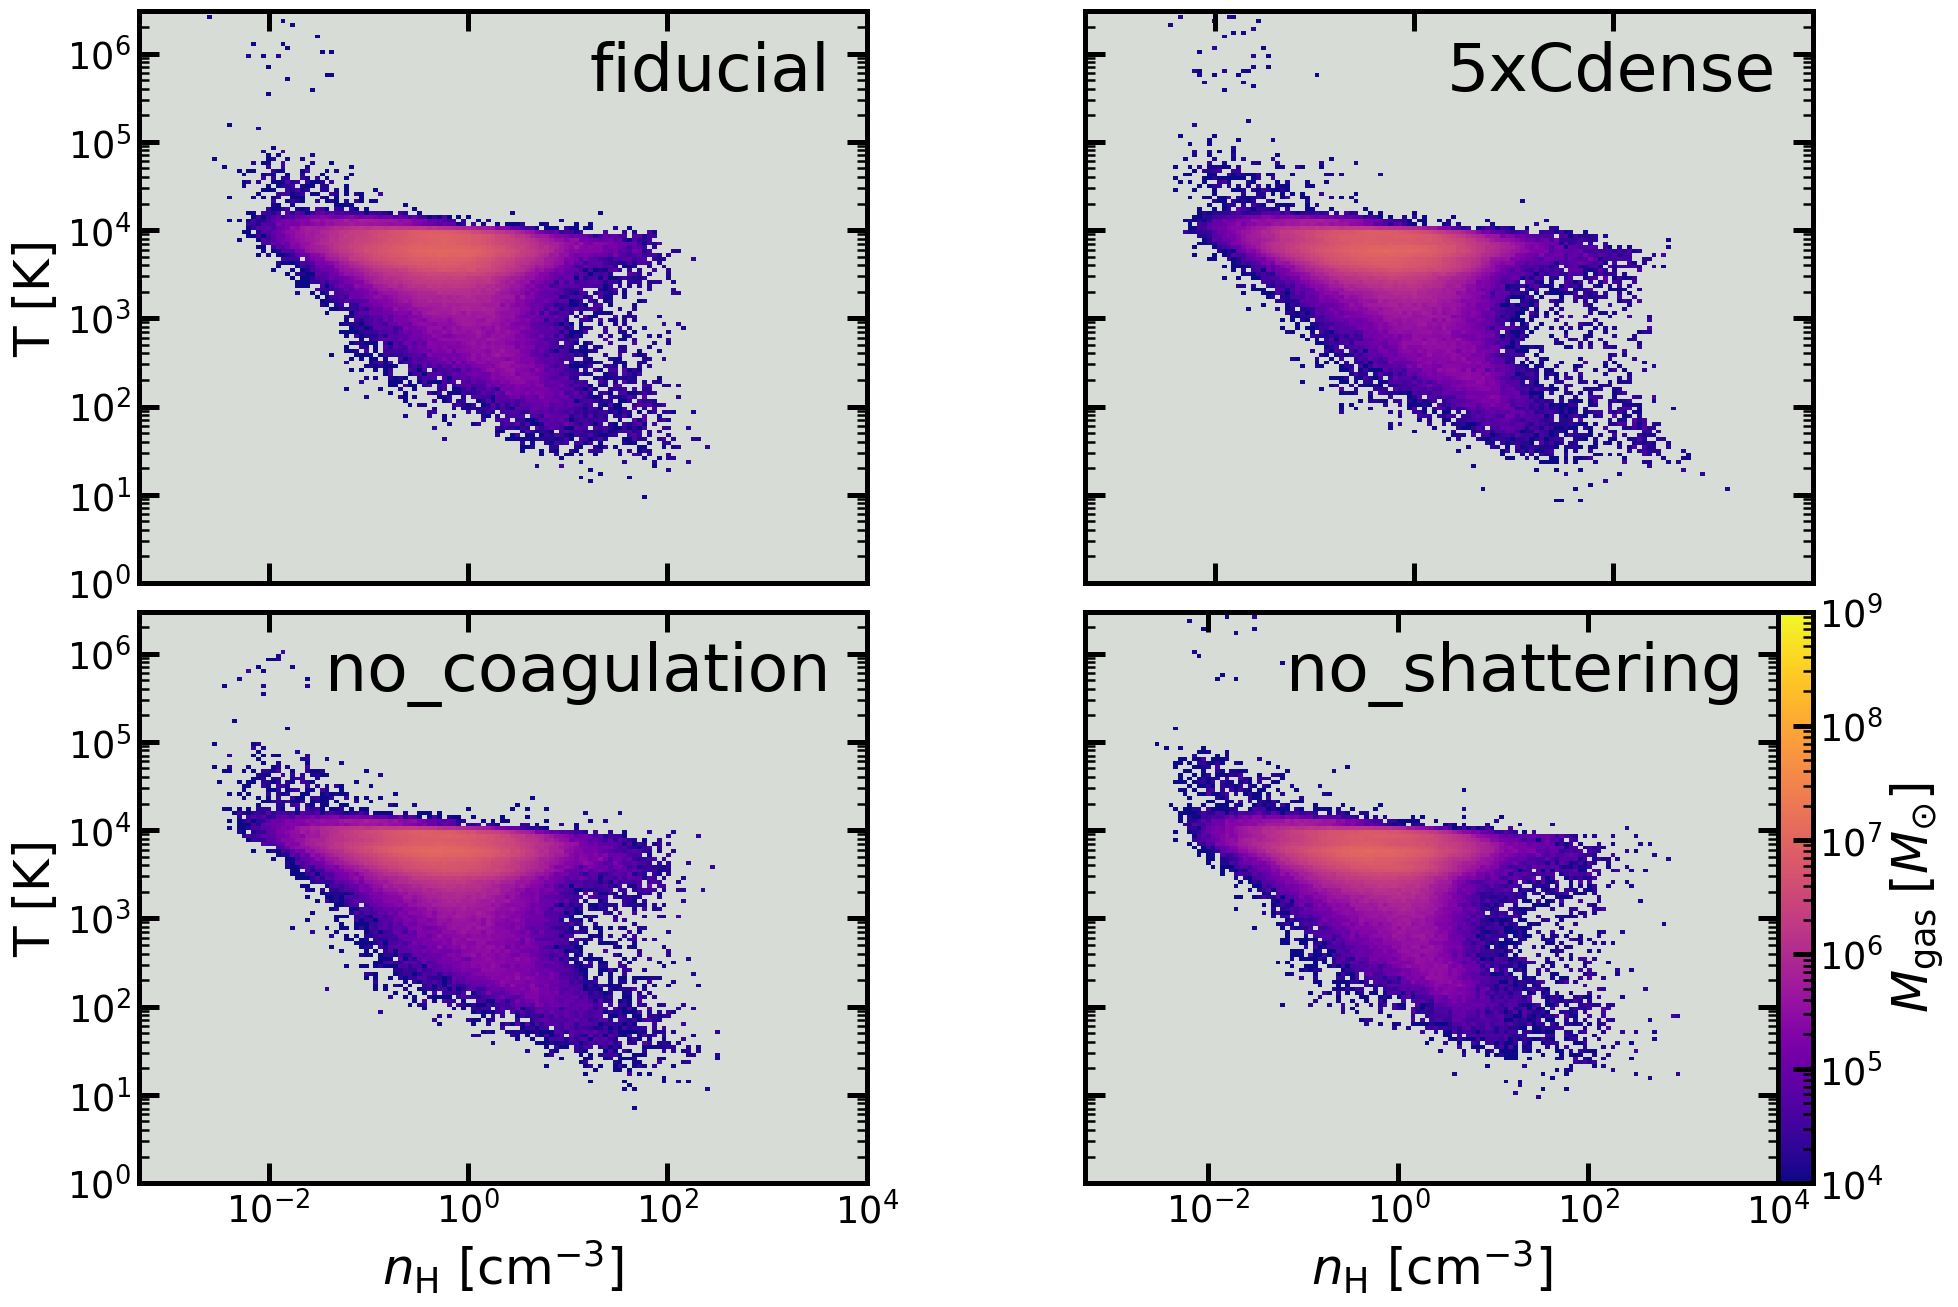

In [93]:
foutname = 'clumping_factor_phase_diagram.pdf'
prop = 'M_gas'
z_logs=[True]
# Number of bins across nH and T space
bin_nums = 150
cmap='plasma'
# nH and T limits
nH_lims = [5E-4,1E4]
T_lims = [1,3E6]

prop_lims=[[1E4,1E9],[1E4,1E9],[1,12],[0.1,1]]

fig = Figure(len(halos),ncols=2, sharey=True, sharex=True)

for i,halo in enumerate(halos):
    sp = halo.sp
    print(sp.sdir)
    name = sim_names[i]



    # Set up for each plot
    fig.set_axis(i, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
    ret = calc.calc_phase_hist_data(prop, halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, factor_clumping=False)
    X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
    fig.plot_2Dhistogram(i, prop, X, Y, ret.statistic.T, cmap=cmap, z_lim=prop_lims[0], z_log=z_logs[0],label=name)

# Add colorbar to last axis
fig.add_colorbar(len(halos)-1,cbar_prop=prop)

fig.save(plot_dir+group_name+'_'+str(snap_num)+'_'+foutname)

#### Projection

/N/project/choban_group/cchoban/size_evo_suite/MW_Fiducial/output
/N/project/choban_group/cchoban/size_evo_suite/MW_5xCDense/output
/N/project/choban_group/cchoban/size_evo_suite/MW_NoCoag/output
/N/project/choban_group/cchoban/size_evo_suite/MW_NoShat/output


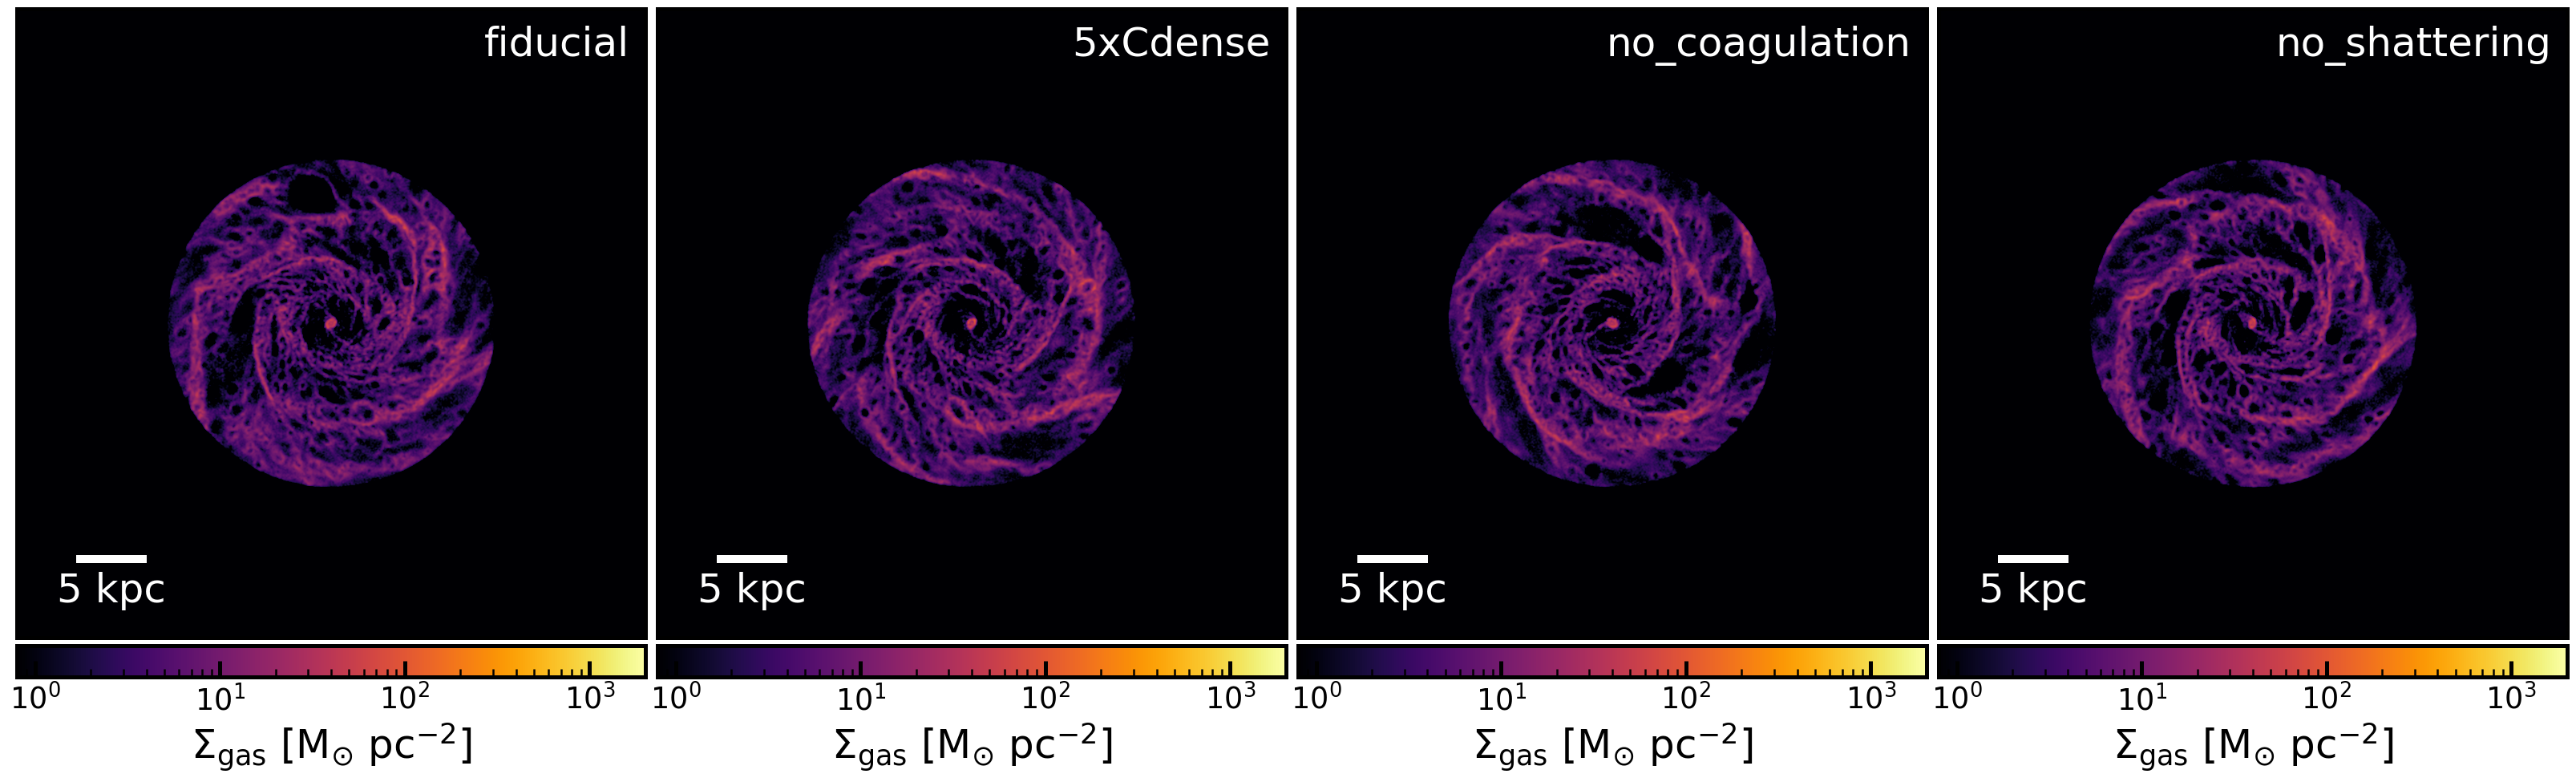

In [94]:

foutname = '_projections.pdf'

# Size resolution (kpc) for each "pixel" in projection
pixel_res=0.1
# Properties to plot projections of. Can be surface densities (total mass in pixel divided by pixel size) or properties like T (median value of all particles in pixel)
property = 'sigma_gas'
# Limits for projection of each property. Defaults if not set
prop_limit = [8E-1,2E3]
# Colormaps for each projection
prop_cmap = 'inferno'
# Do you want log colormaps for each property (default = True)
log_cmap = True
# Labels for each projection is so desired
label = 'gas'
# Physical size of projection 
proj_L = 50 # kpc
# Do you want a secondary projection from an orthogonal axis (i.e. edge-on)
sub_proj = False
# size of secondary projection
sub_L = 2 # kpc


new_proj = Projection(len(halos), add_sub_proj=sub_proj, add_colorbars=True, height_ratios=height_ratios)
for i,halo in enumerate(halos):
    sp = halo.sp
    print(sp.sdir)
    name = sim_names[i]
    # Initialize projection figure
    L = proj_L
    height_ratios = [L/sub_L,1]
    
    # Create projections for each property and plot the projection
    new_proj.set_proj_axis(i, property, L, axes_visible=False)
    # Create x-y projection using a 2D histogram
    main_pixel_stats, main_xedges, main_yedges, main_extent = calc.calc_projected_prop(property, halo, [L,L,L], pixel_res=pixel_res, proj='xy')
    if sub_proj:
        # Create x-z subprojection using a 2D histogram
        sub_pixel_stats, sub_xedges, sub_yedges, sub_extent = calc.calc_projected_prop(property, halo, [L,sub_L,L], pixel_res=pixel_res, proj='xz')
    else:
        sub_pixel_stats=None; sub_extent=None
    # x-z projection
    # Create the projection
    new_proj.plot_projection(i, main_pixel_stats, main_extent, sub_proj_data=sub_pixel_stats, sub_extent=sub_extent,
                                cmap= prop_cmap, v_limits = prop_limit,v_log=log_cmap, label=name)
        
new_proj.save(plot_dir+group_name+'_'+str(snap_num)+'_'+property+'_'+foutname)

#### Dust Population Trends with Density and Temperature

/N/project/choban_group/cchoban/size_evo_suite/MW_Fiducial/output
/N/project/choban_group/cchoban/size_evo_suite/MW_5xCDense/output
/N/project/choban_group/cchoban/size_evo_suite/MW_NoCoag/output
/N/project/choban_group/cchoban/size_evo_suite/MW_NoShat/output


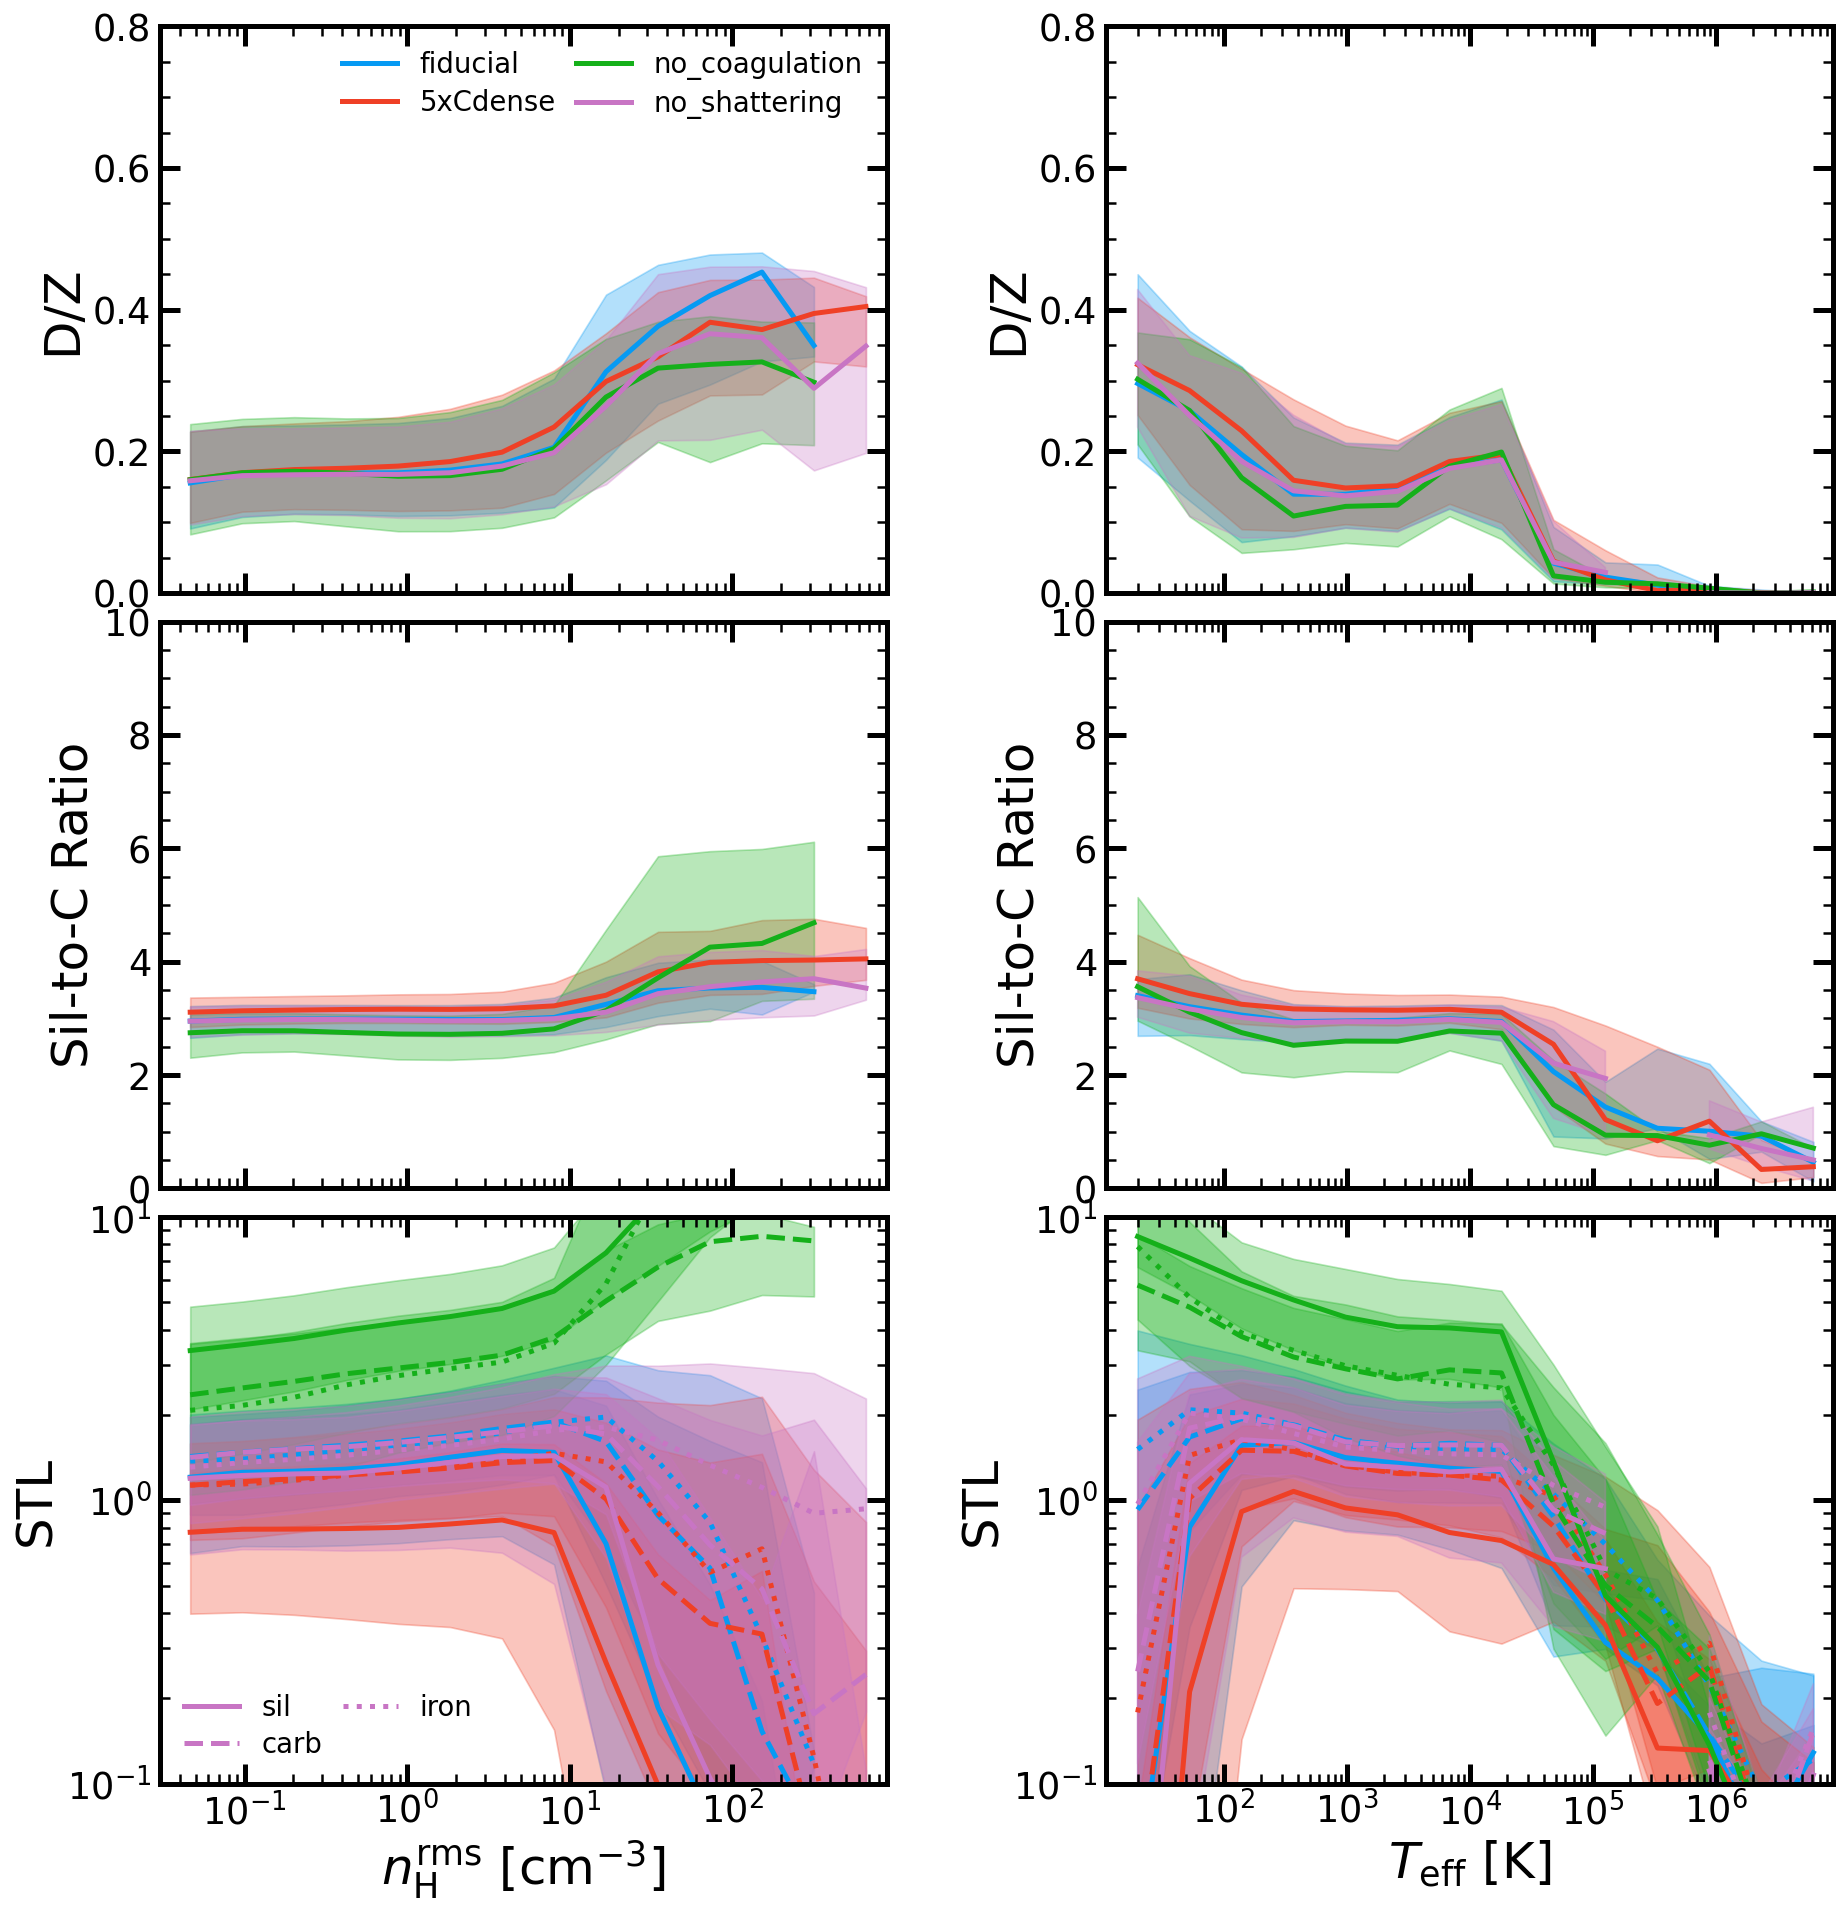

In [96]:
foutname = 'DZ_STC_STL_vs_gas.pdf'

fig = Figure(6,ncols=2, sharex='col')

colors = config.LINE_COLORS[:len(halos)]
linestyles = config.LINE_STYLES[:len(halos)]
linewidth = 2*config.BASE_LINEWIDTH
init_depl = 0

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=1

DZ_lims = [0,0.8]
fig.set_axis(0, 'nH_rms', 'D/Z', y_log=False, y_lim=DZ_lims)
fig.set_axis(1, 'T_eff', 'D/Z', y_log=False, y_lim=DZ_lims)
fig.set_axis(2, 'nH_rms', 'Si/C')
fig.set_axis(3, 'T_eff', 'Si/C')
fig.set_axis(4, 'nH_rms', 'f_STL')
fig.set_axis(5, 'T_eff', 'f_STL')


bin_nums=15




for i,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[i]




    bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property('D/Z','nH',halo, bin_nums=bin_nums)
    fig.plot_line_data(0,bin_vals,mean_vals, color=colors[i],linestyle=linestyles[0], label=name)
    fig.plot_shaded_region(0,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[i])

    bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property('D/Z','T',halo, bin_nums=bin_nums)
    fig.plot_line_data(1,bin_vals,mean_vals, color=colors[i],linestyle=linestyles[0])
    fig.plot_shaded_region(1,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[i])

    bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property('Si/C','nH',halo, bin_nums=bin_nums)
    fig.plot_line_data(2,bin_vals,mean_vals, color=colors[i],linestyle=linestyles[0])
    fig.plot_shaded_region(2,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[i])

    bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property('Si/C','T',halo, bin_nums=bin_nums)
    fig.plot_line_data(3,bin_vals,mean_vals, color=colors[i],linestyle=linestyles[0])
    fig.plot_shaded_region(3,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[i])

    for j, spec in enumerate(['sil','carb','iron']):
        if len(halos)<=1: color_index = j
        else: color_index = i
        bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property('f_STL_'+spec,'nH',halo, bin_nums=bin_nums)
        fig.plot_line_data(4,bin_vals,mean_vals, color=colors[color_index],linestyle=linestyles[j], label=spec)
        fig.plot_shaded_region(4,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[color_index])

        bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property('f_STL_'+spec,'T',halo, bin_nums=bin_nums)
        fig.plot_line_data(5,bin_vals,mean_vals, color=colors[color_index],linestyle=linestyles[j], label=spec)
        fig.plot_shaded_region(5,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[color_index])
    
    
    fig.set_axis_legend(4, rescale_font=0.75)

fig.set_axis_legend(0, rescale_font=0.75)
fig.save(plot_dir+group_name+'_'+str(snap_num)+'_'+foutname)

#### Grain Size Distribution for Each Species

/N/project/choban_group/cchoban/size_evo_suite/MW_Fiducial/output
/N/project/choban_group/cchoban/size_evo_suite/MW_5xCDense/output
/N/project/choban_group/cchoban/size_evo_suite/MW_NoCoag/output
/N/project/choban_group/cchoban/size_evo_suite/MW_NoShat/output


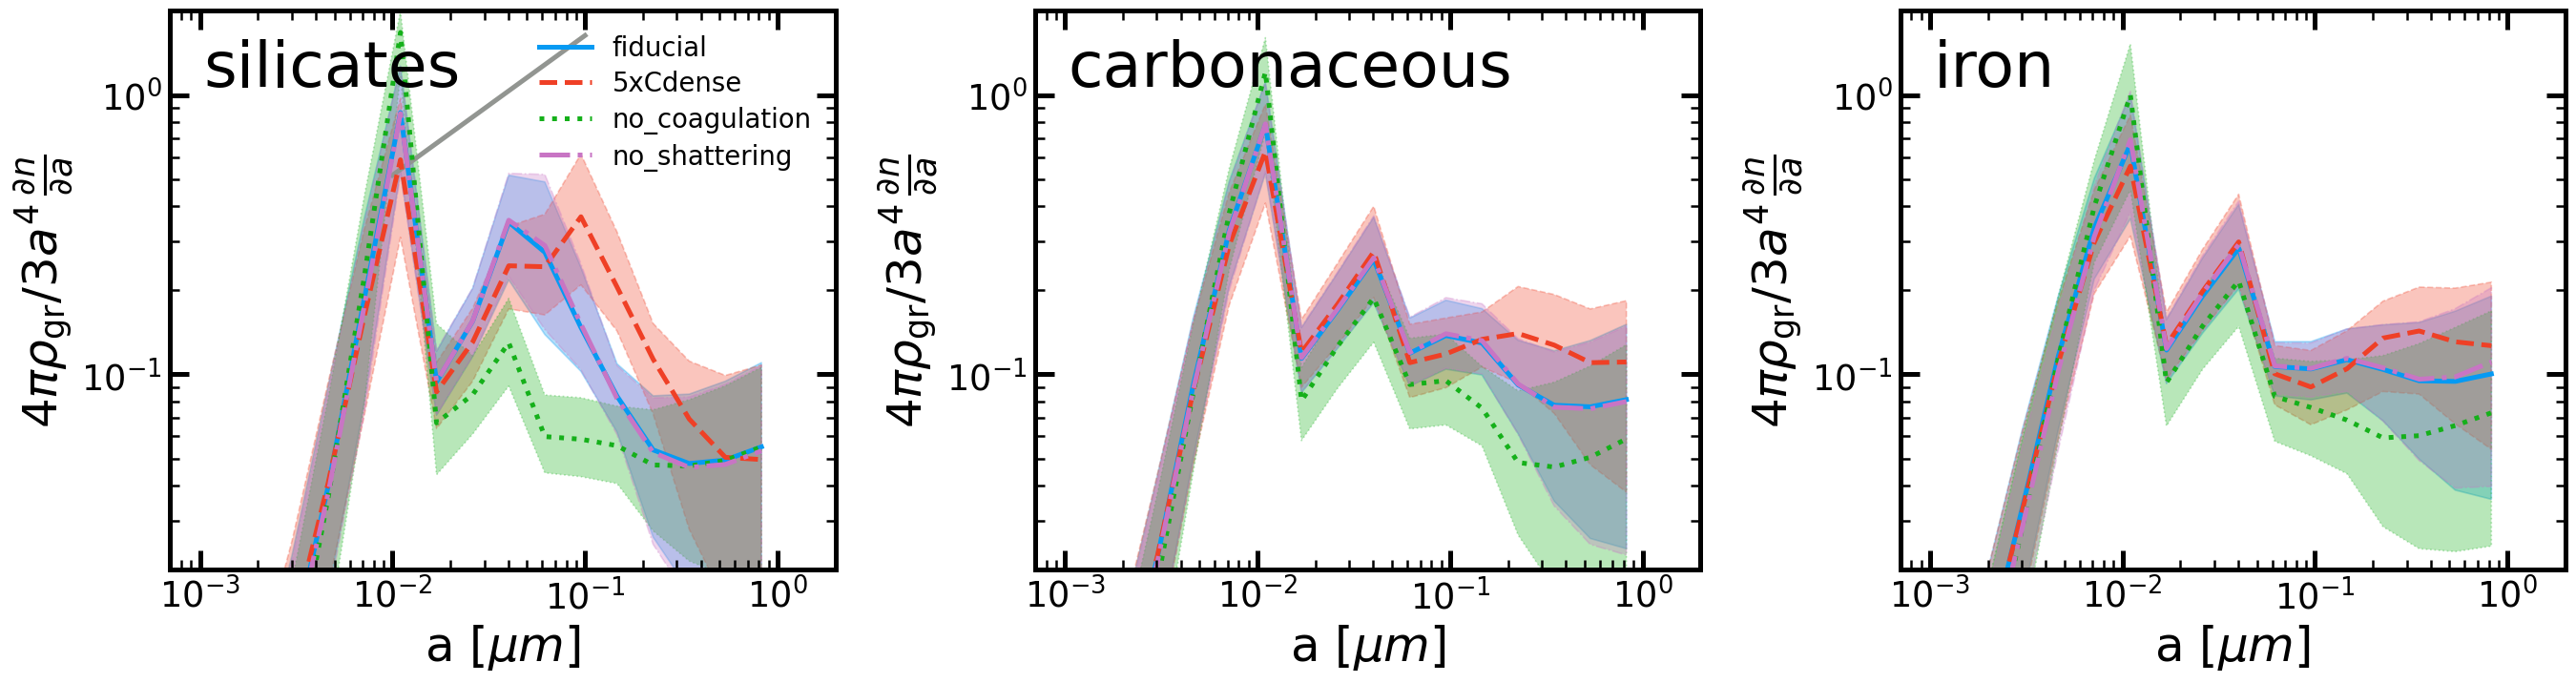

In [97]:

foutname = 'median_dmdloga.pdf'
species=['silicates','carbonaceous','iron']

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=1


fig = Figure(3,ncols=3)
num_specs = len(species)
num_snaps = len(halos)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:num_snaps]
linewidth = 2*config.BASE_LINEWIDTH

for i in range(len(species)):
    fig.set_axis(i, 'grain_size', 'dm/da',y_lim=[2E-2,2E-0])
    fig.add_text(i,0.05,0.95,species[i],ha='left',va='top',)

    if i==0:
        sp = halos[0].sp
        MRN_a_vals = np.logspace(-2,-1,10)
        y_offset = 1
        dmda_norm = quad(gse.MRN_dmda, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
        dmdloga_vals = gse.MRN_dmda(MRN_a_vals)*MRN_a_vals/dmda_norm * np.power(10,y_offset)
        fig.plot_line_data(0,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle='-')


for k,halo in enumerate(halos):
    name = sim_names[k]
    G=halo.loadpart(0)
    sp = halo.sp
    print(sp.sdir)


    for i, spec in enumerate(species):
        
        grain_size_vals, percentile_dnda, percentile_dmdloga = grain_size_utils.get_grain_size_distribution(
            G, species=spec, mask=None, points_per_bin=points_per_bin, weight='gas')

        fig.plot_line_data(i,grain_size_vals,percentile_dmdloga[0], color=colors[k],linestyle=linestyles[k], label=name)
        fig.plot_shaded_region(i,grain_size_vals,percentile_dmdloga[1],percentile_dmdloga[2], color=colors[k],linestyle=linestyles[k])


fig.set_all_legends(max_cols=2,rescale_font=0.75)

fig.save(plot_dir+group_name+'_'+str(snap_num)+'_'+foutname)

#### Grain Size Distribution for Each Gas Phase

/N/project/choban_group/cchoban/size_evo_suite/MW_Fiducial/output
cold
mass of gas: 0.0045662168
cool
mass of gas: 0.008929008
warm
mass of gas: 0.2497030912
hot
mass of gas: 0.0076825856
/N/project/choban_group/cchoban/size_evo_suite/MW_5xCDense/output
cold
mass of gas: 0.0048667332
cool
mass of gas: 0.0078016584
warm
mass of gas: 0.25026496
hot
mass of gas: 0.008271608
/N/project/choban_group/cchoban/size_evo_suite/MW_NoCoag/output
cold
mass of gas: 0.0049535016
cool
mass of gas: 0.0078924848
warm
mass of gas: 0.248938624
hot
mass of gas: 0.0082274064
/N/project/choban_group/cchoban/size_evo_suite/MW_NoShat/output
cold
mass of gas: 0.0048645296
cool
mass of gas: 0.0084900456
warm
mass of gas: 0.245712256
hot
mass of gas: 0.0078818504


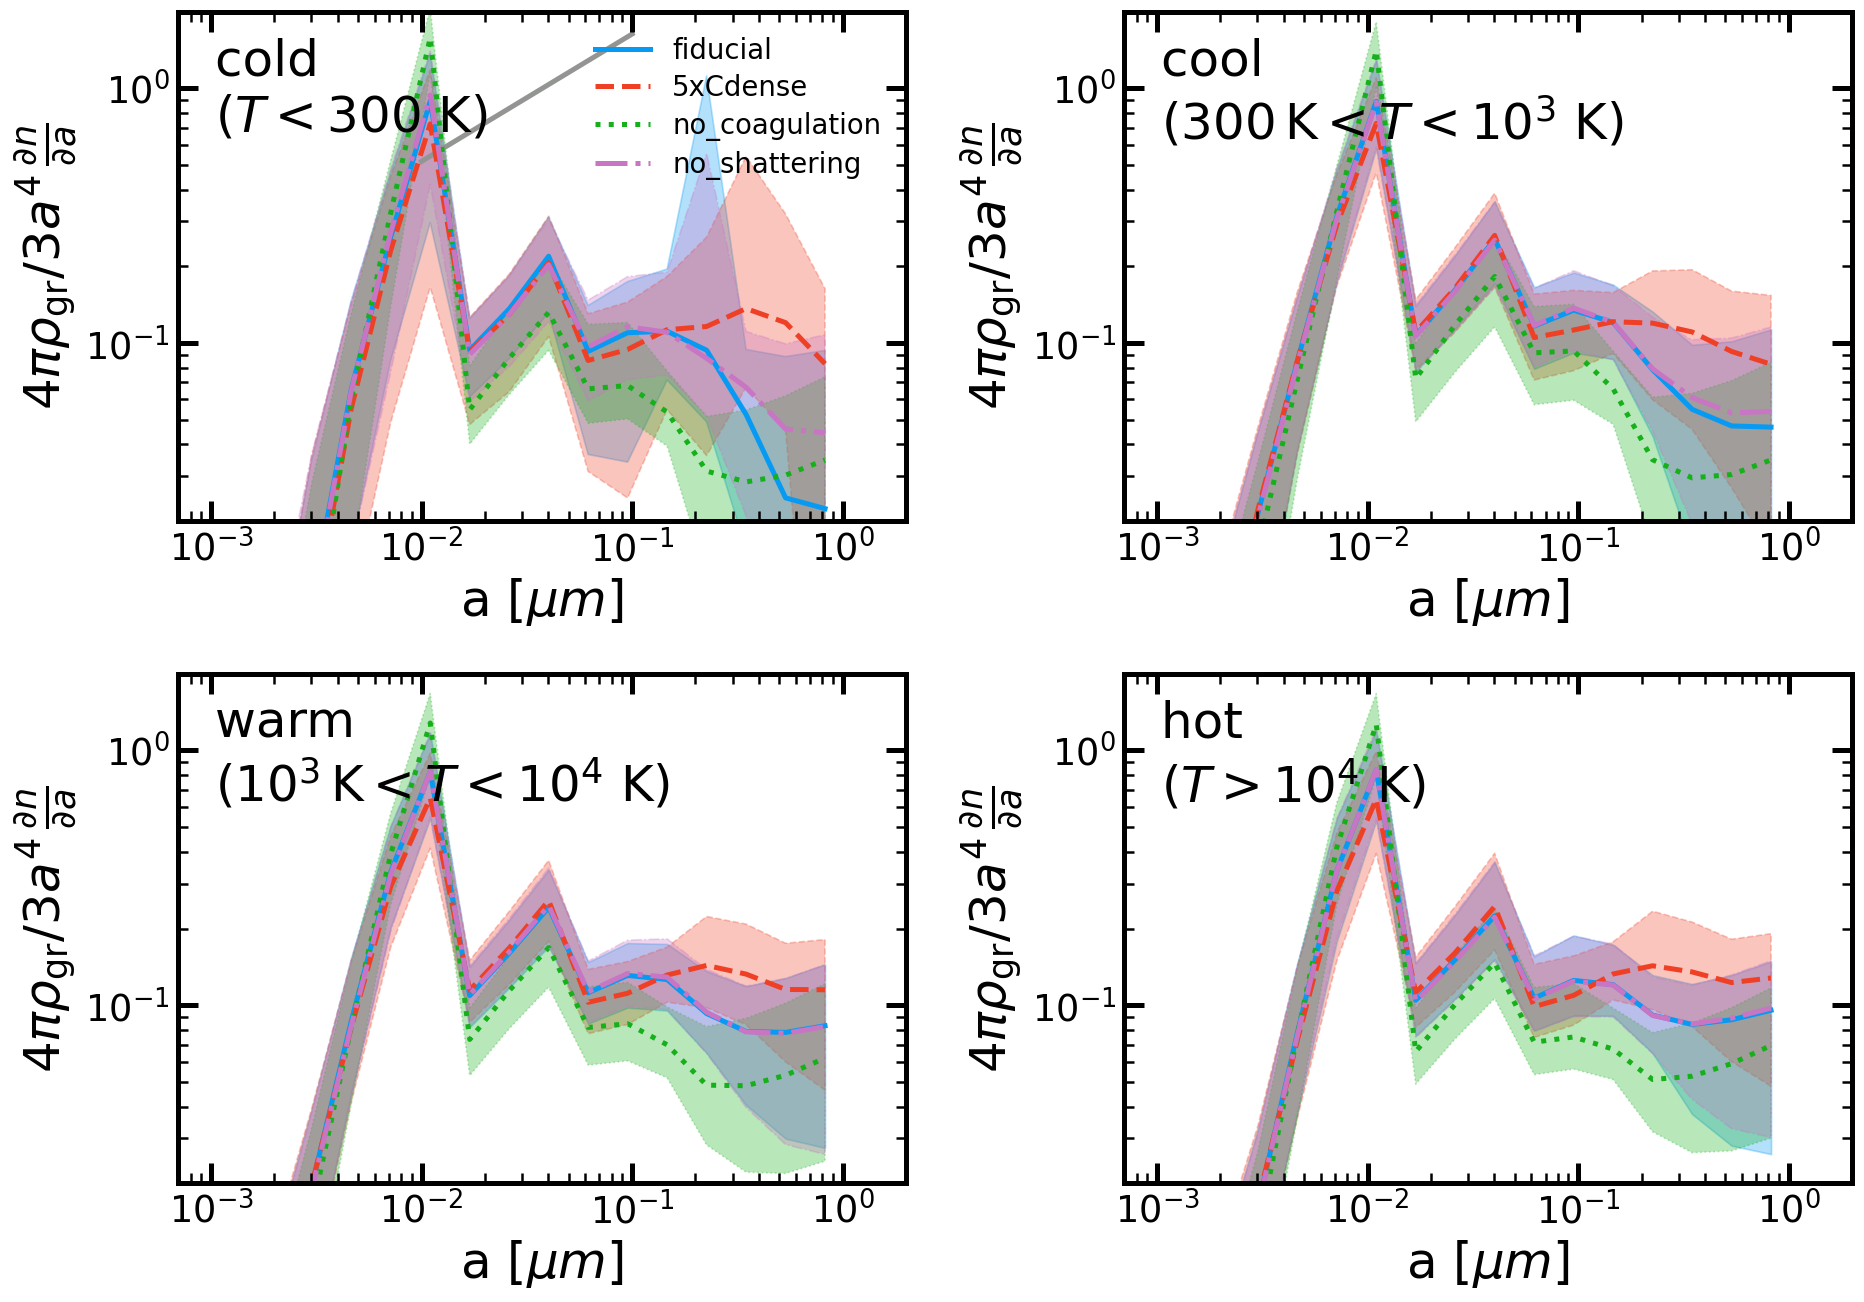

In [109]:

foutname = 'gas_phase_dmdloga.pdf'
spec = 'carbonaceous'
phases=['cold','cool','warm','hot']
phase_labels=[f'cold \n'+r'($T<300$ K)', f'cool \n'+r'($300\,{\rm K}<T<10^3$ K)',f'warm \n'+r'($10^3\,{\rm K}<T<10^4$ K)',f'hot \n'+r'($T>10^4$ K)']
#phase_labels=[f'cold '+r'($T<300$ K)', f'cool '+r'($300\,{\rm K}<T<10^3$ K)',f'warm '+r'($10^3\,{\rm K}<T<10^4$ K)',f'hot '+r'($T>10^4$ K)']
# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=1


fig = Figure(4,ncols=2)
num_specs = len(species)
num_snaps = len(halos)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:num_snaps]
linewidth = 2*config.BASE_LINEWIDTH

for i in range(len(phases)):
    phase_label = phase_labels[i]
    fig.set_axis(i, 'grain_size', 'dm/da',y_lim=[2E-2,2E-0])
    fig.add_text(i,0.05,0.95,phase_label,ha='left',va='top',rescale_font=0.75)

    if i==0:
        MRN_a_vals = np.logspace(-2,-1,10)
        y_offset = 1
        dmda_norm = quad(gse.MRN_dmda, halo.sp.Grain_Size_Min, halo.sp.Grain_Size_Max)[0]
        dmdloga_vals = gse.MRN_dmda(MRN_a_vals)*MRN_a_vals/dmda_norm * np.power(10,y_offset)
        fig.plot_line_data(0,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle='-')


for k,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[k]
    G=halo.loadpart(0)


    for i, phase in enumerate(phases):
        phase_label = phase_labels[i]
        print(phase)
        mask = calc.get_particle_mask(0, halo, mask_criteria=phase)
        print('mass of gas:', np.sum(G.get_property('mass')[mask])/1E10)
        
        grain_size_vals, percentile_dnda, percentile_dmdloga = grain_size_utils.get_grain_size_distribution(
            G, species=spec, mask=mask, points_per_bin=points_per_bin, weight='dust')


        fig.plot_line_data(i,grain_size_vals,percentile_dmdloga[0], color=colors[k],linestyle=linestyles[k], label=name)
        fig.plot_shaded_region(i,grain_size_vals,percentile_dmdloga[1],percentile_dmdloga[2], color=colors[k],linestyle=linestyles[k])


fig.set_all_legends(max_cols=2,rescale_font=0.75)

fig.save(plot_dir+group_name+'_'+str(sp.snum)+'_'+spec+'_'+foutname)

In [ ]:

foutname = 'gas_phase_dmdloga.pdf'
spec = 'silicates'
phases=['cold','cool','warm','hot']

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=1


fig = Figure(4,ncols=2)
num_specs = len(species)
num_snaps = len(halos)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:num_snaps]
linewidth = 2*config.BASE_LINEWIDTH

for i in range(len(phases)):
    fig.set_axis(i, 'grain_size', 'dm/da',y_lim=[2E-2,2E-0])
    fig.add_text(i,0.05,0.95,phases[i],ha='left',va='top')

    if i==0:
        MRN_a_vals = np.logspace(-2,-1,10)
        y_offset = 1
        dmda_norm = quad(gse.MRN_dmda, halo.sp.Grain_Size_Min, halo.sp.Grain_Size_Max)[0]
        dmdloga_vals = gse.MRN_dmda(MRN_a_vals)*MRN_a_vals/dmda_norm * np.power(10,y_offset)
        fig.plot_line_data(0,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle='-')


for k,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[k]
    G=halo.loadpart(0)


    for i, phase in enumerate(phases):
        print("ISM phase:",phase)
        mask = calc.get_particle_mask(0, halo, mask_criteria=phase)
        print(np.sum(G.get_property('mass')[mask])/np.sum(G.get_property('mass'))*100,'% of gas in phase')
        
        grain_size_vals, percentile_dnda, percentile_dmdloga = grain_size_utils.get_grain_size_distribution(
            G, species=spec, mask=mask, points_per_bin=points_per_bin, weight='gas')


        fig.plot_line_data(i,grain_size_vals,percentile_dmdloga[0], color=colors[k],linestyle=linestyles[k], label=name)
        fig.plot_shaded_region(i,grain_size_vals,percentile_dmdloga[1],percentile_dmdloga[2], color=colors[k],linestyle=linestyles[k])


    for i,phase in enumerate(ISM_phases):
            mask = calc.get_particle_mask(0, sp, mask_criteria=phase)
            print("ISM phase:",phase)
            print('gas mass', np.sum(G.get_property('mass')[mask])/1E10,'Msol')

            fig.set_axis(i, 'grain_size', 'dm/dloga_norm',y_lim=[2E-2,2E-0])
            
    
            for j, spec in enumerate(species):
                
                grain_size_vals, percentile_dnda, percentile_dmdloga = \
                    grain_size_utils.get_grain_size_distribution(G, 
                                                                species=spec, 
                                                                mask=mask, 
                                                                points_per_bin=points_per_bin, 
                                                                std_percentiles = [16, 84])


                fig.plot_line_data(i,grain_size_vals,percentile_dmdloga[0], color=colors[j],linestyle=linestyles[j], label=spec)
                fig.plot_shaded_region(i,grain_size_vals,percentile_dmdloga[1],percentile_dmdloga[2], color=colors[j],linestyle=linestyles[j])
                fig.add_text(i,0.05,0.95,phase,ha='left', va='top',)

                fig.add_text(i,0.05,0.95,phase,ha='left', va='top',)


fig.set_all_legends(max_cols=2,rescale_font=0.75)

fig.save(plot_dir+group_name+'_'+str(sp.snum)+'_'+foutname)


for k,sp in enumerate(snaps):
    print(sp.sdir)
    name = sim_names[k]
    G=sp.loadpart(0)
    num_specs = len(species)
    num_phases = len(ISM_phases)


    fig = Figure(num_phases,ncols=2, sharex='col',sharey='row')

    colors = config.LINE_COLORS[:num_specs]
    linestyles = config.LINE_STYLES[:num_specs]
    linewidth = 2*config.BASE_LINEWIDTH

    print("Snapshot time:",sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))


    for i,phase in enumerate(ISM_phases):
        mask = calc.get_particle_mask(0, sp, mask_criteria=phase)
        print("ISM phase:",phase)
        print('gas mass', np.sum(G.get_property('mass')[mask])/1E10,'Msol')

        fig.set_axis(i, 'grain_size', 'dm/dloga_norm',y_lim=[2E-2,2E-0])

        if i==0:
            y_offset = 0.4
            dmdloga_norm = quad(grain_size_utils.MRN_dmdloga, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
            dmdloga_vals = grain_size_utils.MRN_dmdloga(MRN_a_vals)/dmdloga_norm * np.power(10,y_offset)
            fig.plot_line_data(i,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle='-')
            for j, spec in enumerate(species):
                # Lines used for the legend handles. Should not show up in plot
                fig.plot_line_data(0,[-1,-1],[-1,-1], color='xkcd:black',linestyle=linestyles[j],label=spec)
        
 
        for j, spec in enumerate(species):
            
            grain_size_vals, percentile_dnda, percentile_dmdloga = \
                grain_size_utils.get_grain_size_distribution(G, 
                                                             species=spec, 
                                                             mask=mask, 
                                                             points_per_bin=points_per_bin, 
                                                             std_percentiles = [16, 84])


            fig.plot_line_data(i,grain_size_vals,percentile_dmdloga[0], color=colors[j],linestyle=linestyles[j], label=spec)
            fig.plot_shaded_region(i,grain_size_vals,percentile_dmdloga[1],percentile_dmdloga[2], color=colors[j],linestyle=linestyles[j])
            fig.add_text(i,0.05,0.95,phase,ha='left', va='top',)

    fig.set_all_legends(max_cols=2,rescale_font=0.75)

    fig.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)

#### Load Simulations

In [ ]:

# Disk parameters
disk_radius = 13. # kpc ~2x the IC disk scale length
disk_scale_height = 0.5 # kpc ~2x the IC disk scale height


main_dirc = '/N/project/choban_group/cchoban/size_evo_suite'

# Snapshot to check
snap_num = 150

snap_dirs = [main_dirc+'/MW_Fiducial/output',
             main_dirc+'/MW_8Bin/output',
             main_dirc+'/MW_4Bin/output',
             main_dirc+'/MW_2Bin/output',
             ]

# Shorthand names for each sim used in plot legends and file names
sim_names = ['fiducial',
             '8_bin',
             '4_bin',
             '2_bin',
             ]


halos = []


for i,snap_dir in enumerate(snap_dirs):
    print("Snap Dirc: ",snap_dir)

    print("Snap Num:",snap_num)
    sp = load_snap(snap_dir, snap_num, cosmological=0)
    halo = sp.loadhalo(mode=None)
    halo.set_disk(rmax = disk_radius, height=disk_scale_height)
    halo.set_orientation(ptype=4, mass_radius_max = 10, velocity_radius_max=10, radius_max=10, age_limits=[0,0.5])
    halos += [halo]


#### D/Z Relation

In [ ]:


foutname = 'bin_convergence_DZ_STC_STL_vs_gas.pdf'

fig = Figure(6,ncols=2, sharex='col')
num_snaps = len(halos)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:3]
linewidth = 2*config.BASE_LINEWIDTH
init_depl = 0

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=1

fig.set_axis(0, 'nH', 'D/Z')
fig.set_axis(1, 'T', 'D/Z')
fig.set_axis(2, 'nH', 'Si/C')
fig.set_axis(3, 'T', 'Si/C')
fig.set_axis(4, 'nH', 'f_STL')
fig.set_axis(5, 'T', 'f_STL')


bin_nums=15




for i,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[i]




    bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property('D/Z','nH',halo, bin_nums=bin_nums)
    fig.plot_line_data(0,bin_vals,mean_vals, color=colors[i],linestyle=linestyles[0], label=name)
    fig.plot_shaded_region(0,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[i])

    bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property('D/Z','T',halo, bin_nums=bin_nums)
    fig.plot_line_data(1,bin_vals,mean_vals, color=colors[i],linestyle=linestyles[0])
    fig.plot_shaded_region(1,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[i])

    bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property('Si/C','nH',halo, bin_nums=bin_nums)
    fig.plot_line_data(2,bin_vals,mean_vals, color=colors[i],linestyle=linestyles[0])
    fig.plot_shaded_region(2,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[i])

    bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property('Si/C','T',halo, bin_nums=bin_nums)
    fig.plot_line_data(3,bin_vals,mean_vals, color=colors[i],linestyle=linestyles[0])
    fig.plot_shaded_region(3,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[i])

    for j, spec in enumerate(['sil','carb','iron']):
        bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property('f_STL_'+spec,'nH',halo, bin_nums=bin_nums)
        fig.plot_line_data(4,bin_vals,mean_vals, color=colors[i],linestyle=linestyles[j], label=spec)
        fig.plot_shaded_region(4,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[i])

        bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property('f_STL_'+spec,'T',halo, bin_nums=bin_nums)
        fig.plot_line_data(5,bin_vals,mean_vals, color=colors[i],linestyle=linestyles[j], label=spec)
        fig.plot_shaded_region(5,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[i])
    
    fig.set_axis_legend(0)
    fig.set_axis_legend(4)

    fig.save(plot_dir+name+'_'+str(halo.sp.snum)+'_'+foutname)


#### Grain Size Distribution

In [ ]:

foutname = 'bin_convergence_median_dmdloga.pdf'
species=['silicates','carbonaceous','iron']

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=[10,20,40,80]


fig = Figure(3,ncols=3)
num_specs = len(species)
num_snaps = len(halos)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:num_snaps]
linewidth = 2*config.BASE_LINEWIDTH

for i in range(len(species)):
    fig.set_axis(i, 'grain_size', 'dm/da',y_lim=[2E-2,2E-0])
    fig.add_text(i,0.05,0.95,species[i],ha='left',va='top',)



for k,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[k]
    G=halo.loadpart(0)

    if k==0:
        MRN_a_vals = np.logspace(-2,-1,10)
        y_offset = 1
        dmda_norm = quad(gse.MRN_dmda, halo.sp.Grain_Size_Min, halo.sp.Grain_Size_Max)[0]
        dmdloga_vals = gse.MRN_dmda(MRN_a_vals)*MRN_a_vals/dmda_norm * np.power(10,y_offset)
        fig.plot_line_data(1,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle='-')

    for i, spec in enumerate(species):
        
        grain_size_vals, percentile_dnda, percentile_dmdloga = grain_size_utils.get_grain_size_distribution(
            G, species=spec, mask=None, points_per_bin=points_per_bin[k], weight='gas')


        fig.plot_line_data(i,grain_size_vals,percentile_dmdloga[0], color=colors[k],linestyle=linestyles[k], label=name)
        #fig.plot_shaded_region(1,dmdloga_bin_points,dmdloga_stds[:,0],dmdloga_stds[:,1], color=colors[i],linestyle=linestyles[j]


fig.set_all_legends(max_cols=2,rescale_font=0.75)

fig.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)

### General Analysis

General gas, star, and basic dust analysis plots for the specified simulations.

#### Load Galactic Disk of Simulations

In [ ]:

# Disk parameters
disk_radius = 13. # kpc ~2x the IC disk scale length
disk_scale_height = 0.5 # kpc ~2x the IC disk scale height


main_dirc = '/N/project/choban_group/cchoban/size_evo_suite'

# Snapshot to check
snap_num = 100

# snap_dirs = [main_dirc+'/MW_Fiducial/output',
#              main_dirc+'/MW_Coag_Only/output',
#              ]

# # Shorthand names for each sim used in plot legends and file names
# sim_names = ['fiducial',
#              'coag_only',
#              ]

snap_dirs = [main_dirc+'/MW_Fiducial/output',
             main_dirc+'/MW_CoagOnly_100xVcoag/output',
             main_dirc+'/MW_CoagOnly_Dense_Enhancement/output',
             ]

# Shorthand names for each sim used in plot legends and file names
sim_names = ['fiducial',
             '100xVCoag',
             'DenseEnhancement'
             ]


halos = []


for i,snap_dir in enumerate(snap_dirs):
    print("Snap Dirc: ",snap_dir)

    print("Snap Num:",snap_num)
    sp = load_snap(snap_dir, snap_num, cosmological=0)
    halo = sp.loadhalo(mode=None)
    halo.set_disk(rmax = disk_radius, height=disk_scale_height)
    halo.set_orientation(ptype=4, mass_radius_max = 10, velocity_radius_max=10, radius_max=10, age_limits=[0,0.5])
    halos += [halo]


#### Gas and Star Properties

##### Projections

In [ ]:

foutname = 'disk_projections.pdf'

# Size resolution (kpc) for each "pixel" in projection
pixel_res=0.1
# Properties to plot projections of. Can be surface densities (total mass in pixel divided by pixel size) or properties like T (median value of all particles in pixel)
properties = ['sigma_gas','sigma_star','sigma_dust']
# Limits for projection of each property. Defaults if not set
prop_limits = [[8E-1,2E3],[2E0,2E4],[8E-3,2E1]]
# Colormaps for each projection
prop_cmaps = ['inferno','viridis','cividis']
# Do you want log colormaps for each property (default = True)
log_cmaps = [True]*len(properties)
# Labels for each projection is so desired
labels = ['gas','stars','dust']
# Physical size of projection 
proj_L = 2*disk_radius # kpc
# Do you want a secondary projection from an orthogonal axis (i.e. edge-on)
sub_proj = True
# size of secondary projection
sub_L = 4*disk_scale_height # kpc


for i,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[i]
    # Initialize projection figure
    L = proj_L
    height_ratios = [L/sub_L,0.5]
    new_proj = Projection(len(properties), add_sub_proj=sub_proj, add_colorbars=True, height_ratios=height_ratios)
    # Create projections for each property and plot the projection
    for j,prop in enumerate(properties):
        new_proj.set_proj_axis(j, prop, L, axes_visible=False)
        # Create x-y projection using a 2D histogram
        main_pixel_stats, main_xedges, main_yedges, main_extent = calc.calc_projected_prop(prop, halo, [L,L,L], pixel_res=pixel_res, proj='xy')
        if sub_proj:
            # Create x-z subprojection using a 2D histogram
            sub_pixel_stats, sub_xedges, sub_yedges, sub_extent = calc.calc_projected_prop(prop, halo, [L,sub_L,L], pixel_res=pixel_res, proj='xz')
        else:
            sub_pixel_stats=None; sub_extent=None
        # x-z projection
        # Create the projection
        if labels is not None:
            label = labels[j]
        else:
            label=None
        new_proj.plot_projection(j, main_pixel_stats, main_extent, sub_proj_data=sub_pixel_stats, sub_extent=sub_extent,
                                    cmap= prop_cmaps[j], v_limits = prop_limits[j],v_log=log_cmaps[j], label=label)
        
    new_proj.save(plot_dir+name+'_'+str(halo.sp.snum)+'_'+foutname)

##### Gas-Phase Diagrams

In [ ]:
foutname = 'disk_phase_diagram.pdf'
props = ['M_gas','M_H2','mach_number','D/Z']
fig_labels = ['all gas','H2 gas','mach','D/Z']
z_logs=[True]*len(props)
# Number of bins across nH and T space
bin_nums = 150
cmap='plasma'
# nH and T limits
nH_lims = [5E-4,1E4]
T_lims = [5,3E6]

prop_lims=[[1E4,1E9],[1E4,1E9],[1,12],[0.01,0.5]]


for i,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[i]

    fig = Figure(len(props),ncols=2, sharex='col',sharey='row')

    for j,prop in enumerate(props):
        # Set up for each plot
        fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
        ret = calc.calc_phase_hist_data(prop, halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims)
        X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
        fig.plot_2Dhistogram(j, prop, X, Y, ret.statistic.T, cmap=cmap, z_lim=prop_lims[j], z_log=z_logs[j],label=fig_labels[j])

        # Add colorbar to last axis
        fig.add_colorbar(j,cbar_prop=prop)

    fig.save(plot_dir+name+'_'+str(halo.sp.snum)+'_'+foutname)

##### SFH

In [ ]:
foutname = 'disk_SFH.pdf'


for i,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[i]

    time, cum_SFH = snap_utils.get_SFH(halo, cum=1)

    stars = halo.loadpart(4)
    sft, m = stars.get_property('sft'), stars.get_property('M_form')
    time, sfr = math_utils.SFH(sft, m, halo, dt=0.005, cum=False)

    fig = Figure(2,ncols=2)

    time_lims = [0,1.5]

    fig.set_axis(0, 'time', 'sfr', x_lim=time_lims,x_log=False,twin_time_axis=False)
    fig.set_axis(1, 'time', 'M_star', x_lim=time_lims,x_log=False,twin_time_axis=False)


    fig.plot_line_data(0,time,sfr)

    fig.plot_line_data(1,time,cum_SFH)


    fig.save(plot_dir+name+'_'+str(halo.sp.snum)+'_'+foutname)


### Dust Properties

#### Analytical Checks

Checking gas-dust accretion and sputtering rates and gas which allows coagulation and shattering.

##### Accretion and Sputtering

In [ ]:
foutname = 'disk_dust_rate_phase_diagram.pdf'
props = ['dMdt_acc','dMdt_acc','dMdt_acc','dMdt_sput']
fig_labels = ['accretion \n T<300K','accretion \n T<600K','accretion \n T<1000K','sputtering']
z_logs=[True]*len(props)
# Number of bins across nH and T space
bin_nums = 150
cmap='plasma'
# nH and T limits
nH_lims = [5E-5,1E4]
T_lims = [5,8E6]


prop_lims=[[1E-7,1E-4],[1E-7,1E-4],[1E-7,1E-4],[1E-8,1E-6]]

# Number of subsampling for each bin when calculating dMdt rates.
# N=1 will assume all grains have the same size in each bin
# Set to a small number to get a good estimate
bin_subsamples = 4



for i,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[i]

    G = halo.loadpart(0)
    #dMdt_shat, dMdt_coag = grain_size_utils.get_dust_shattering_and_coagulation_rate(G)

    dMdt_acc1 = grain_size_utils.get_dust_accretion_rate(G, T_cutoff=300, factor_clumping=True,bin_subsamples=bin_subsamples)
    print('dMdt_acc:',np.sum(dMdt_acc1),'Msol/yr')
    dMdt_acc2 = grain_size_utils.get_dust_accretion_rate(G, T_cutoff=600, factor_clumping=True,bin_subsamples=bin_subsamples)
    print('dMdt_acc:',np.sum(dMdt_acc2),'Msol/yr')
    dMdt_acc3 = grain_size_utils.get_dust_accretion_rate(G, T_cutoff=1000, factor_clumping=True,bin_subsamples=bin_subsamples)
    print('dMdt_acc:',np.sum(dMdt_acc3),'Msol/yr')
    dMdt_sput = grain_size_utils.get_dust_sputtering_rate(G, T_cutoff = 1E4, factor_clumping=True,bin_subsamples=bin_subsamples)
    print('dMdt_sput:',np.sum(dMdt_sput),'Msol/yr')

    dMdt=[dMdt_acc1,dMdt_acc2,dMdt_acc3,-dMdt_sput]


    fig = Figure(len(props),ncols=2, sharex='col',sharey='row')

    for j,prop in enumerate(props):
        # Set up for each plot
        fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
        ret = calc.calc_phase_hist_data(dMdt[j], halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='sum')

        ret.statistic[ret.statistic == 0] = np.nan

        X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
        fig.plot_2Dhistogram(j, prop, X, Y, ret.statistic.T, cmap=cmap, z_lim=prop_lims[j], z_log=z_logs[j],label=fig_labels[j])

        # Add colorbar to last axis
        fig.add_colorbar(j,cbar_prop='dMdt')

    fig.save(plot_dir+name+'_'+str(halo.sp.snum)+'_'+foutname)

##### Coagulation and Shattering

Gas phase diagram with median grain velocities for each size bin which satisfy either coagulation or shattering threshold velocities.
Assuming either Kolmogorov or supersonic turbulence power spectrum.

###### Kolmogorov Turbulence

In [ ]:
foutname = 'disk_Kolmogorov_vgrain.pdf'
prop = 'v_grain'
z_log=True
# Number of bins across nH and T space
bin_nums = 150
cmap='plasma'
# nH and T limits
nH_lims = [5E-5,1E4]
T_lims = [5,8E6]


prop_lim=[1E-2,1E1]



for i,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[i]

    gas = halo.loadpart(0)
    nH = gas.get_property('nH')
    rho = gas.get_property('density')
    temp = gas.get_property('temperature')
    M = gas.get_property('mach_number')
    
    rho_c = 3.1
    b = 0.5
    nH_rms =np.sqrt(1+b*b*M*M)*nH

    spec_props = config.dust_species_properties('silicates')
    rho_c = spec_props['rho_c'] # Bulk density of silicates [g/cm^3]
    poisson = spec_props['poisson'] # Poisson ratio
    youngs = spec_props['youngs'] # Young's modulus [GPa]
    gamma = spec_props['gamma'] # Surface energy [J/m^2]
    v_shat = spec_props['v_shat']*1E-5 # Shattering velocity [km/s]

    bin_num = halo.sp.Flag_GrainSizeBins
    a_centers = halo.sp.Grain_Bin_Centers

    fig = Figure(bin_num,ncols=4, sharex='col',sharey='row')

    for j in range(bin_num):
        agrain = a_centers[j]
        a_collider=agrain
        vgr = 0.32 * (M/3) * np.power(agrain,0.5) * np.power(temp/100,0.25) * \
        np.power(nH_rms/1E3,-0.25)*np.power(rho_c/3.5,0.5) # km/s

        vcoag = gse_models.v_coagulation(agrain*config.um_to_cm,a_collider*config.um_to_cm,
                        rho_c,poisson,youngs,gamma,fudge_factor=True) * 1E-5 # cm/s to km/s

        fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
        ret = calc.calc_phase_hist_data(vgr, halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='median')

        M_gas = gas.get_property('mass')
        M_gas[vgr>vcoag] = 0
        mass_coag = calc.calc_phase_hist_data(M_gas, halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='sum').statistic
        
        vgr_coag = ret.statistic.T
        vgr_coag[vgr_coag>vcoag] = np.nan
        print('a_grain: %2.2g'%agrain,'v_coag: %2.2g'%vcoag,'fraction of gas < v_coag: %2.2g'%(np.nansum(mass_coag)/np.sum(gas.get_property('mass'))))


        X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
        fig.plot_2Dhistogram(j, prop, X, Y, vgr_coag, cmap=cmap, z_lim=prop_lim, z_log=z_log,label=r'$a=%1.1g\,\mu m$'%agrain+'\n'+r'$v_{\rm coag}=%2.1g$ km/s'%vcoag)

        # Add colorbar to last axis
        fig.add_colorbar(j,cbar_label=r'$v_{\rm gr}$ [km/s]')
    
    fig.save(plot_dir+name+'_'+str(halo.sp.snum)+'_vcoag_'+foutname)


    fig = Figure(bin_num,ncols=4, sharex='col',sharey='row')

    for j in range(bin_num):
        agrain = a_centers[j]
        a_collider=agrain
        vgr = 0.32 * (M/3) * np.power(agrain,0.5) * np.power(temp/100,0.25) * \
        np.power(nH_rms/1E3,-0.25)*np.power(rho_c/3.5,0.5) # km/s
        
        fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
        ret = calc.calc_phase_hist_data(vgr, halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='median')
        
        M_gas = gas.get_property('mass')
        M_gas[vgr<v_shat] = 0
        mass_shat = calc.calc_phase_hist_data(M_gas, halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='sum').statistic

        vgr_shat = ret.statistic.T
        vgr_shat[vgr_shat<v_shat] = np.nan
        print('a_grain: %2.2g'%agrain,'v_shat: %2.2g'%v_shat,'fraction of gas > v_shat: %2.2g'%(np.nansum(mass_shat)/np.sum(gas.get_property('mass'))))


        X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
        fig.plot_2Dhistogram(j, prop, X, Y, vgr_shat, cmap=cmap, z_lim=prop_lim, z_log=z_log,label=r'$a=%1.1g\,\mu m$'%agrain+'\n'+r'$v_{\rm shat}=%2.1g$ km/s'%v_shat)

        # Add colorbar to last axis
        fig.add_colorbar(j,cbar_label=r'$v_{\rm gr}$ [km/s]')
    
    fig.save(plot_dir+name+'_'+str(halo.sp.snum)+'_vshat_'+foutname)
        

###### Supersonic Turbulence

In [ ]:
foutname = 'disk_supersonic_vgrain.pdf'
props = ['v_grain']
z_log=True
# Number of bins across nH and T space
bin_nums = 150
cmap='plasma'
# nH and T limits
nH_lims = [5E-5,1E4]
T_lims = [5,8E6]


prop_lim=[1E-2,1E1]



for i,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[i]

    gas = halo.sp.loadpart(0)
    nH = gas.get_property('nH')
    rho = gas.get_property('density')
    temp = gas.get_property('temperature')
    M = gas.get_property('mach_number')
    
    b = 0.5
    nH_rms =np.sqrt(1+b*b*M*M)*nH

    spec_props = config.dust_species_properties('silicates')
    rho_c = spec_props['rho_c'] # Bulk density of silicates [g/cm^3]
    poisson = spec_props['poisson'] # Poisson ratio
    youngs = spec_props['youngs'] # Young's modulus [GPa]
    gamma = spec_props['gamma'] # Surface energy [J/m^2]
    v_shat = spec_props['v_shat']*1E-5 # Shattering velocity [km/s]

    bin_num = halo.sp.Flag_GrainSizeBins
    a_centers = halo.sp.Grain_Bin_Centers

    fig = Figure(bin_num,ncols=4, sharex='col',sharey='row')
 

    for j in range(bin_num):
        agrain = a_centers[j]
        a_collider=agrain
        # Grain velocity assuming supersonic turbulence
        vgr = 0.066 * (M/3) * (agrain) * \
        np.power(nH_rms/1E3,-0.5)*(rho_c/3.5) # km/s

        vcoag = gse_models.v_coagulation(agrain*config.um_to_cm,a_collider*config.um_to_cm,
                        rho_c,poisson,youngs,gamma,fudge_factor=True) * 1E-5 # cm/s to km/s
        
        fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
        ret = calc.calc_phase_hist_data(vgr, halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='median')

        M_gas = gas.get_property('mass')
        M_gas[vgr>vcoag] = 0
        mass_coag = calc.calc_phase_hist_data(M_gas, halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='sum').statistic
        
        vgr_coag = ret.statistic.T
        vgr_coag[vgr_coag>vcoag] = np.nan
        print('a_grain: %2.2g'%agrain,'v_coag: %2.2g'%vcoag,'fraction of gas < v_coag: %2.2g'%(np.nansum(mass_coag)/np.sum(gas.get_property('mass'))))


        X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
        fig.plot_2Dhistogram(j, prop, X, Y, vgr_coag, cmap=cmap, z_lim=prop_lim, z_log=z_log,label=r'$a=%1.1g\,\mu m$'%agrain+'\n'+r'$v_{\rm coag}=%2.1g$ km/s'%vcoag)

        # Add colorbar to last axis
        fig.add_colorbar(j,cbar_label=r'$v_{\rm gr}$ [km/s]')
    
    fig.save(plot_dir+name+'_'+str(halo.sp.snum)+'_vcoag_'+foutname)


    fig = Figure(bin_num,ncols=4, sharex='col',sharey='row')
 

    for j in range(bin_num):
        agrain = a_centers[j]
        a_collider=agrain
        vgr = 0.066 * (M/3) * (agrain) * \
        np.power(nH_rms/1E3,-0.5)*(rho_c/3.5) # km/s
        
        fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
        ret = calc.calc_phase_hist_data(vgr, halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='median')
        
        M_gas = gas.get_property('mass')
        M_gas[vgr<v_shat] = 0
        mass_shat = calc.calc_phase_hist_data(M_gas, halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='sum').statistic

        vgr_shat = ret.statistic.T
        vgr_shat[vgr_shat<v_shat] = np.nan
        print('a_grain: %2.2g'%agrain,'v_shat: %2.2g'%v_shat,'fraction of gas > v_shat: %2.2g'%(np.nansum(mass_shat)/np.sum(gas.get_property('mass'))))


        X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
        fig.plot_2Dhistogram(j, prop, X, Y, vgr_shat, cmap=cmap, z_lim=prop_lim, z_log=z_log,label=r'$a=%1.2g\,\mu m$'%agrain+'\n'+r'$v_{\rm shat}=%2.2g$ km/s'%v_shat)

        # Add colorbar to last axis
        fig.add_colorbar(j,cbar_label=r'$v_{\rm gr}$ [km/s]')
    
    fig.save(plot_dir+name+'_'+str(halo.sp.snum)+'_vshat_'+foutname)

###### Lebreuilly23 Grain Velocity Prescription

In [ ]:
foutname = 'disk_Lebreuilly23_vgrain.pdf'
props = ['v_grain']
z_log=True
# Number of bins across nH and T space
bin_nums = 150
cmap='plasma'
# nH and T limits
nH_lims = [5E-5,1E4]
T_lims = [5,8E6]


prop_lim=[1E-2,1E1]



for i,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[i]

    gas = halo.sp.loadpart(0)
    nH = gas.get_property('nH')
    rho = gas.get_property('density')
    temp = gas.get_property('temperature')
    M = gas.get_property('mach_number')
    
    b = 0.5
    nH_rms =np.sqrt(1+b*b*M*M)*nH

    spec_props = config.dust_species_properties('silicates')
    rho_c = spec_props['rho_c'] # Bulk density of silicates [g/cm^3]
    poisson = spec_props['poisson'] # Poisson ratio
    youngs = spec_props['youngs'] # Young's modulus [GPa]
    gamma = spec_props['gamma'] # Surface energy [J/m^2]
    v_shat = spec_props['v_shat']*1E-5 # Shattering velocity [km/s]

    bin_num = halo.sp.Flag_GrainSizeBins
    a_centers = halo.sp.Grain_Bin_Centers

    fig = Figure(bin_num,ncols=4, sharex='col',sharey='row')
 

    for j in range(bin_num):
        agrain = a_centers[j]
        a_collider=agrain
        # Grain velocity assuming supersonic turbulence
        vgr = gse_models.grain_relative_velocity(agrain*config.um_to_cm,
                                    a_collider*config.um_to_cm,
                                    rho_c, 
                                    ISM_phase=None, 
                                    scheme='Lebreuilly23',
                                    gas_particles=gas,)*1E-5 # km/s

        vcoag = gse_models.v_coagulation(agrain*config.um_to_cm,a_collider*config.um_to_cm,
                        rho_c,poisson,youngs,gamma,fudge_factor=True) * 1E-5 # cm/s to km/s
        
        fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
        ret = calc.calc_phase_hist_data(vgr, halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='median')

        M_gas = gas.get_property('mass')
        M_gas[vgr>vcoag] = 0
        mass_coag = calc.calc_phase_hist_data(M_gas, halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='sum').statistic
        
        vgr_coag = ret.statistic.T
        vgr_coag[vgr_coag>vcoag] = np.nan
        print('a_grain: %2.2g'%agrain,'v_coag: %2.2g'%vcoag,'fraction of gas < v_coag: %2.2g'%(np.nansum(mass_coag)/np.sum(gas.get_property('mass'))))


        X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
        fig.plot_2Dhistogram(j, prop, X, Y, vgr_coag, cmap=cmap, z_lim=prop_lim, z_log=z_log,label=r'$a=%1.1g\,\mu m$'%agrain+'\n'+r'$v_{\rm coag}=%2.1g$ km/s'%vcoag)

        # Add colorbar to last axis
        fig.add_colorbar(j,cbar_label=r'$v_{\rm gr}$ [km/s]')
    
    fig.save(plot_dir+name+'_'+str(halo.sp.snum)+'_vcoag_'+foutname)


    fig = Figure(bin_num,ncols=4, sharex='col',sharey='row')
 

    for j in range(bin_num):
        agrain = a_centers[j]
        a_collider=agrain
        vgr = gse_models.grain_relative_velocity(agrain*config.um_to_cm,
                                    a_collider*config.um_to_cm,
                                    rho_c, 
                                    ISM_phase=None, 
                                    scheme='Lebreuilly23',
                                    gas_particles=gas,)*1E-5 # km/s
        
        fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
        ret = calc.calc_phase_hist_data(vgr, halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='median')
        
        M_gas = gas.get_property('mass')
        M_gas[vgr<v_shat] = 0
        mass_shat = calc.calc_phase_hist_data(M_gas, halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='sum').statistic

        vgr_shat = ret.statistic.T
        vgr_shat[vgr_shat<v_shat] = np.nan
        print('a_grain: %2.2g'%agrain,'v_shat: %2.2g'%v_shat,'fraction of gas > v_shat: %2.2g'%(np.nansum(mass_shat)/np.sum(gas.get_property('mass'))))


        X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
        fig.plot_2Dhistogram(j, prop, X, Y, vgr_shat, cmap=cmap, z_lim=prop_lim, z_log=z_log,label=r'$a=%1.2g\,\mu m$'%agrain+'\n'+r'$v_{\rm shat}=%2.2g$ km/s'%v_shat)

        # Add colorbar to last axis
        fig.add_colorbar(j,cbar_label=r'$v_{\rm gr}$ [km/s]')
    
    fig.save(plot_dir+name+'_'+str(halo.sp.snum)+'_vshat_'+foutname)

In [ ]:
foutname = 'disk_Mshatcoag.pdf'
props = ['v_grain']
z_log=True
# Number of bins across nH and T space
bin_nums = 150
cmap='plasma'
# nH and T limits
nH_lims = [5E-5,1E4]
T_lims = [5,8E6]


prop_lim=[1E-2,1E1]



for i,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[i]

    gas = halo.sp.loadpart(0)
    nH = gas.get_property('nH')
    rho = gas.get_property('density')
    temp = gas.get_property('temperature')
    M = gas.get_property('mach_number')
    
    b = 0.5
    nH_rms =np.sqrt(1+b*b*M*M)*nH

    spec_props = config.dust_species_properties('carbonaceous')
    rho_c = spec_props['rho_c'] # Bulk density of silicates [g/cm^3]
    poisson = spec_props['poisson'] # Poisson ratio
    youngs = spec_props['youngs'] # Young's modulus [GPa]
    gamma = spec_props['gamma'] # Surface energy [J/m^2]
    v_shat = spec_props['v_shat']*1E-5 # Shattering velocity [km/s]

    bin_num = halo.sp.Flag_GrainSizeBins
    a_centers = halo.sp.Grain_Bin_Centers

    fig = Figure(3,ncols=3, sharey='row')
    fig.set_axis(0,'grain_size','M_gas',y_lim = [1E7,1E10])
    fig.set_axis(1,'grain_size','M_gas',y_lim = [1E7,1E10])
    fig.set_axis(2,'grain_size','M_gas',y_lim = [1E7,1E10])


    M_coag1 = np.zeros(bin_num)
    M_coag2 = np.zeros(bin_num)
    M_shat = np.zeros(bin_num)

    for j in range(bin_num):
        agrain = a_centers[j]
        a_collider=agrain
        # Grain velocity assuming supersonic turbulence
        vgr = 0.066 * (M/3) * (agrain) * \
        np.power(nH_rms/1E3,-0.5)*(rho_c/3.5) # km/s

        vcoag = gse_models.v_coagulation(agrain*config.um_to_cm,a_collider*config.um_to_cm,
                        rho_c,poisson,youngs,gamma,fudge_factor=True) * 1E-5 # cm/s to km/s

        M_gas = gas.get_property('mass')
        M_coag1[j] = np.sum(M_gas[vgr<vcoag])
        M_coag2[j] = np.sum(M_gas[vgr<10*vcoag])
        M_shat[j] = np.sum(M_gas[vgr>v_shat])


    fig.plot_line_data(0, a_centers, M_shat, color='red', label='shatter')
    fig.plot_line_data(0, a_centers, M_coag1, color='blue', label='coagulation')
    fig.plot_line_data(0, a_centers, M_coag2, color='green', label=r'$10\times v_{\rm coag}$')
    fig.add_text(0,0.05,0.95,'Supersonic', ha='left', va='top', rescale_font=0.75)


    M_coag1 = np.zeros(bin_num)
    M_coag2 = np.zeros(bin_num)
    M_shat = np.zeros(bin_num)

    for j in range(bin_num):
        agrain = a_centers[j]
        a_collider=agrain
        # Grain velocity assuming supersonic turbulence
        vgr = 0.32 * (M/3) * np.power(agrain,0.5) * np.power(temp/100,0.25) * \
        np.power(nH_rms/1E3,-0.25)*np.power(rho_c/3.5,0.5) # km/s


        vcoag = gse_models.v_coagulation(agrain*config.um_to_cm,a_collider*config.um_to_cm,
                        rho_c,poisson,youngs,gamma,fudge_factor=True) * 1E-5 # cm/s to km/s

        M_gas = gas.get_property('mass')
        M_coag1[j] = np.sum(M_gas[vgr<vcoag])
        M_coag2[j] = np.sum(M_gas[vgr<vcoag*10])
        M_shat[j] = np.sum(M_gas[vgr>v_shat])
    
    fig.plot_line_data(1, a_centers, M_shat, color='red', label='shatter')
    fig.plot_line_data(1, a_centers, M_coag1, color='blue', label='coagulation')
    fig.plot_line_data(1, a_centers, M_coag2, color='green', label=r'$10\times v_{\rm coag}$')
    fig.add_text(1,0.05,0.95,'Kolmogorov', ha='left', va='top', rescale_font=0.75)

    M_coag1 = np.zeros(bin_num)
    M_coag2 = np.zeros(bin_num)
    M_shat = np.zeros(bin_num)

    for j in range(bin_num):
        agrain = a_centers[j]
        a_collider=agrain
        # Grain velocity assuming supersonic turbulence
        vgr = gse_models.grain_relative_velocity(agrain*config.um_to_cm,
                                    a_collider*config.um_to_cm,
                                    rho_c, 
                                    ISM_phase=None, 
                                    scheme='Lebreuilly23',
                                    gas_particles=gas,)*1E-5 # cm/s to km/s


        vcoag = gse_models.v_coagulation(agrain*config.um_to_cm,a_collider*config.um_to_cm,
                        rho_c,poisson,youngs,gamma,fudge_factor=True) * 1E-5 # cm/s to km/s

        M_gas = gas.get_property('mass')
        M_coag1[j] = np.sum(M_gas[vgr<vcoag])
        M_coag2[j] = np.sum(M_gas[vgr<vcoag*10])
        M_shat[j] = np.sum(M_gas[vgr>v_shat])
    
    fig.plot_line_data(2, a_centers, M_shat, color='red', label='shatter')
    fig.plot_line_data(2, a_centers, M_coag1, color='blue', label='coagulation')
    fig.plot_line_data(2, a_centers, M_coag2, color='green', label=r'$10\times v_{\rm coag}$')
    fig.add_text(2,0.05,0.95,'Lebreuilly23', ha='left', va='top', rescale_font=0.75)  


    fig.set_all_legends()
      
    
    #fig.save(plot_dir+name+'_'+str(halo.sp.snum)+'_vcoag_'+foutname)


### Grain Size Distribution

#### Median Comparison for each dust species

In [ ]:

foutname = 'comparison_median_dmdloga.pdf'
species=['silicates','carbonaceous','iron']

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=1


fig = Figure(3,ncols=3)
num_specs = len(species)
num_snaps = len(halos)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:num_snaps]
linewidth = 2*config.BASE_LINEWIDTH

for i in range(len(species)):
    fig.set_axis(i, 'grain_size', 'dm/da',y_lim=[2E-2,2E-0])
    fig.add_text(i,0.05,0.95,species[i],ha='left',va='top',)



for k,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[k]
    G=halo.loadpart(0)

    if k==0:
        MRN_a_vals = np.logspace(-2,-1,10)
        y_offset = 1
        dmda_norm = quad(gse.MRN_dmda, halo.sp.Grain_Size_Min, halo.sp.Grain_Size_Max)[0]
        dmdloga_vals = gse.MRN_dmda(MRN_a_vals)*MRN_a_vals/dmda_norm * np.power(10,y_offset)
        fig.plot_line_data(1,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle='-')

    for i, spec in enumerate(species):
        
        grain_size_vals, percentile_dnda, percentile_dmdloga = grain_size_utils.get_grain_size_distribution(
            G, species=spec, mask=None, points_per_bin=points_per_bin, weight='gas')


        fig.plot_line_data(i,grain_size_vals,percentile_dmdloga[0], color=colors[k],linestyle=linestyles[k], label=name)
        fig.plot_shaded_region(i,grain_size_vals,percentile_dmdloga[1],percentile_dmdloga[2], color=colors[k],linestyle=linestyles[k])


fig.set_all_legends(max_cols=2,rescale_font=0.75)

fig.save(plot_dir+str(sp.snum)+'_'+foutname)

#### Median Comparison for each gas phase

In [ ]:

foutname = 'gas_phase_dmdloga.pdf'
spec = 'silicates'
phases=['cold','warm','hot']

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=10


fig = Figure(3,ncols=3)
num_specs = len(species)
num_snaps = len(halos)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:num_snaps]
linewidth = 2*config.BASE_LINEWIDTH

for i in range(len(phases)):
    fig.set_axis(i, 'grain_size', 'dm/da',y_lim=[2E-2,2E-0])
    fig.add_text(i,0.05,0.95,phases[i],ha='left',va='top',)

    if i==0:
        MRN_a_vals = np.logspace(-2,-1,10)
        y_offset = 1
        dmda_norm = quad(gse.MRN_dmda, halo.sp.Grain_Size_Min, halo.sp.Grain_Size_Max)[0]
        dmdloga_vals = gse.MRN_dmda(MRN_a_vals)*MRN_a_vals/dmda_norm * np.power(10,y_offset)
        fig.plot_line_data(0,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle='-')


for k,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[k]
    G=halo.loadpart(0)


    for i, phase in enumerate(phases):
        print(phase)
        mask = calc.get_particle_mask(0, halo, mask_criteria=phase)
        
        grain_size_vals, percentile_dnda, percentile_dmdloga = grain_size_utils.get_grain_size_distribution(
            G, species=spec, mask=mask, points_per_bin=points_per_bin, weight='gas')


        fig.plot_line_data(i,grain_size_vals,percentile_dmdloga[0], color=colors[k],linestyle=linestyles[k], label=name)
        fig.plot_shaded_region(i,grain_size_vals,percentile_dmdloga[1],percentile_dmdloga[2], color=colors[k],linestyle=linestyles[k])


fig.set_all_legends(max_cols=2,rescale_font=0.75)

fig.save(plot_dir+str(sp.snum)+'_'+foutname)

### Extinction Curves

#### $A_V$ Idealized


Assuming MRN size distribution with a MW dust-to-gas ratio, Av/NH ~ 0.5E-22

In [ ]:
grain_size_utils.calculate_idealized_Av(NH = 1E21,
                        DTG = 0.014*0.5,
                        amin = 1E-3,
                        amax = 3E-1,
                        sil_to_carbon_ratio = 2.0,
                        MRN_slope = -3.5)

#### $A_V$ Histogram

In [ ]:
foutname = 'disk_Av_histogram.pdf'
ISM_phases = ['all']
species=['all']



# Number of subsamples for each grain size bin when calculating the extinction curve
# If you set this to 1, it will use the center value of the bin
# Values > 1 are only needed for simulations with a small number of grain size bins
bin_subsamples = 1

AV_limits = [0.01,0.21]
AV_log = True



for k,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[k]
    G=halo.loadpart(0)


    fig = Figure(1)
    num_specs = len(species)
    num_phases = len(ISM_phases)
    colors = config.LINE_COLORS[:num_specs]
    linestyles = config.LINE_STYLES[:num_specs]
    linewidth = 2*config.BASE_LINEWIDTH
    fig.set_axis(0, 'A_V', 'PDF', x_lim=AV_limits, y_lim=[0,1], x_label=r'$A_V$', y_label = 'PDF', y_log = False, x_log=AV_log)

    print("Snapshot time:",halo.sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))

    for i,phase in enumerate(ISM_phases):

        mask = calc.get_particle_mask(0, halo, mask_criteria=phase)
        #mask = (G.get_property('nH') > 1E1) & (G.get_property('T') < 1E4) & (G.get_property('D/Z') > 0.001)
        print("ISM phase:",phase)

        print(len(G.get_property('nH')[mask]),'gas cells in mask')

        # Some print outs to check column densities of gas cells
        print('D/Z',G.get_property('D/Z')[mask])
        hsml = np.asarray(G.get_property('size')[mask],dtype=np.float64) * config.kpc_to_cm * config.cm_to_um # [microns]
        gas_mass =  np.asarray(G.get_property('M_gas')[mask],dtype=np.float64)*config.Msolar_to_g # [grams]
        Sigma_H = gas_mass*0.7/config.H_MASS / (np.pi * hsml*config.um_to_cm * hsml*config.um_to_cm)
        bin_nums = G.get_property('grain_bin_num')[mask]
        sigma_dust = np.sum(bin_nums,axis=(1,2))/(np.pi * hsml*config.um_to_cm * hsml*config.um_to_cm)
        print("Sigma H:",Sigma_H)
        print("Sigma dust:",sigma_dust)

        for j, spec in enumerate(species):

            A_V = grain_size_utils.calculate_Av(G, 
                                                species=spec, 
                                                mask = mask, 
                                                bin_subsamples = bin_subsamples)
            print('AV',A_V)
            print(np.min(A_V), np.max(A_V), np.median(A_V))
            print("Fraction of gas with AV>0.1:", np.sum(gas_mass[A_V>0.1])/np.sum(gas_mass))
            

            NH_mask = (Sigma_H > 1E20)
            print("Fraction of gas mass w/ NH>", np.sum(gas_mass[NH_mask])/np.sum(gas_mass))
            print(A_V[NH_mask])
            print(np.min(A_V[NH_mask]), np.max(A_V[NH_mask]), np.median(A_V[NH_mask]))

            fig.plot_1Dhistogram(0, A_V[NH_mask], bin_lims=AV_limits, bin_nums=20, bin_log=AV_log, label=spec, color=colors[j],linestyle=linestyles[j],density=False,cumulative=False)

    fig.set_all_legends(max_cols=2,rescale_font=0.75)

    fig.save(plot_dir+name+'_'+str(halo.sp.snum)+'_'+foutname)



#### Normalized Extinction Curve ($A_{\lambda}/A_V$)

##### Idealized Extinction for MRN

In [ ]:

foutname = 'idealized_extinction_curve.pdf'




fig = Figure(1)
colors = config.LINE_COLORS[:10]
linestyles = config.LINE_STYLES[:10]
linewidth = 2*config.BASE_LINEWIDTH
fig.set_axis(0, 'lambda', 'A_lambda', x_lim=[0.09,1.5],y_lim=[0,8])



# Plot observed extinction curves
galaxies = ['LMC','LMC_30Dor','SMC','MW',]
obs_colors = ['xkcd:gold','xkcd:gold','xkcd:blue','xkcd:black']
obs_linestyles = ['-','--','-','-']
subsamples = [2,2,2,0]
for i, galaxy in enumerate(galaxies):
    wavelengths, A_lambda_percentiles = obs.Salim20_compiled_extinction_curve(galaxy, subsample=subsamples[i])
    fig.plot_line_data(0,wavelengths,A_lambda_percentiles[0], y_std=A_lambda_percentiles[[1,2]].T, 
                        color=obs_colors[i],linestyle=obs_linestyles[i], label = galaxy, std_kwargs={'alpha':0.1})

# Plot idealized extinction curve
i=0
amin = 1E-3 # micron
amax = 3E2*amin
wavelength_points, A_lambda_norm = grain_size_utils.calculate_idealized_extinction_curve(amin = amin, amax = amax)
fig.plot_line_data(0,wavelength_points,A_lambda_norm, color=colors[i],linestyle=linestyles[0], label=r'$a_{\rm min} = %1.1g$ $\mu$m'%amin + '\n' + r'$a_{\rm max} = %1.1g$ $\mu$m'%amax)

i=1
amin = 5E-3 # micron
amax = 0.3
wavelength_points, A_lambda_norm = grain_size_utils.calculate_idealized_extinction_curve(amin = amin, amax = amax)
fig.plot_line_data(0,wavelength_points,A_lambda_norm, color=colors[i],linestyle=linestyles[0], label=r'$a_{\rm min} = %1.1g$ $\mu$m'%amin + '\n' + r'$a_{\rm max} = %1.1g$ $\mu$m'%amax)


i=2
amin = 1E-3 # micron
amax = 0.6
wavelength_points, A_lambda_norm = grain_size_utils.calculate_idealized_extinction_curve(amin = amin, amax = amax)
fig.plot_line_data(0,wavelength_points,A_lambda_norm, color=colors[i],linestyle=linestyles[0], label=r'$a_{\rm min} = %1.1g$ $\mu$m'%amin + '\n' + r'$a_{\rm max} = %1.1g$ $\mu$m'%amax)

i=3
amin = 5E-3 # micron
amax = 0.6
wavelength_points, A_lambda_norm = grain_size_utils.calculate_idealized_extinction_curve(amin = amin, amax = amax)
fig.plot_line_data(0,wavelength_points,A_lambda_norm, color=colors[i],linestyle=linestyles[0], label=r'$a_{\rm min} = %1.1g$ $\mu$m'%amin + '\n' + r'$a_{\rm max} = %1.1g$ $\mu$m'%amax)


i=4
amin = 1E-3 # micron
amax = 1
wavelength_points, A_lambda_norm = grain_size_utils.calculate_idealized_extinction_curve(amin = amin, amax = amax)
fig.plot_line_data(0,wavelength_points,A_lambda_norm, color=colors[i],linestyle=linestyles[0], label=r'$a_{\rm min} = %1.1g$ $\mu$m'%amin + '\n' + r'$a_{\rm max} = %1.1g$ $\mu$m'%amax)


fig.set_all_legends(max_cols=2,rescale_font=0.75)

fig.save(plot_dir+foutname)

In [ ]:

foutname = 'idealized_extinction_curve.pdf'




fig = Figure(1)
colors = config.LINE_COLORS[:10]
linestyles = config.LINE_STYLES[:10]
linewidth = 2*config.BASE_LINEWIDTH
fig.set_axis(0, 'lambda', 'A_lambda', x_lim=[0.09,1.5],y_lim=[0,8])



# Plot observed extinction curves
galaxies = ['MW',]
obs_colors = ['xkcd:black']
obs_linestyles = ['-']
subsamples = [0]
for i, galaxy in enumerate(galaxies):
    wavelengths, A_lambda_percentiles = obs.Salim20_compiled_extinction_curve(galaxy, subsample=subsamples[i])
    fig.plot_line_data(0,wavelengths,A_lambda_percentiles[0], y_std=A_lambda_percentiles[[1,2]].T, 
                        color=obs_colors[i],linestyle=obs_linestyles[i], label = galaxy, std_kwargs={'alpha':0.1})

# Plot idealized extinction curve
i=0
amin = 5E-3 # micron
amax = 0.3
wavelength_points, A_lambda_norm = grain_size_utils.calculate_idealized_extinction_curve(amin = amin, amax = amax)
fig.plot_line_data(0,wavelength_points,A_lambda_norm, color=colors[i],linestyle=linestyles[0], label=r'$a_{\rm min} = %1.1g$ $\mu$m'%amin + '\n' + r'$a_{\rm max} = %1.1g$ $\mu$m'%amax)

i=1
amin = 5E-2 # micron
amax = 0.3
wavelength_points, A_lambda_norm = grain_size_utils.calculate_idealized_extinction_curve(amin = amin, amax = amax)
fig.plot_line_data(0,wavelength_points,A_lambda_norm, color=colors[i],linestyle=linestyles[0], label=r'$a_{\rm min} = %1.1g$ $\mu$m'%amin + '\n' + r'$a_{\rm max} = %1.1g$ $\mu$m'%amax)


i=2
amin = 1E-3 # micron
amax = 0.15
wavelength_points, A_lambda_norm = grain_size_utils.calculate_idealized_extinction_curve(amin = amin, amax = amax)
fig.plot_line_data(0,wavelength_points,A_lambda_norm, color=colors[i],linestyle=linestyles[0], label=r'$a_{\rm min} = %1.1g$ $\mu$m'%amin + '\n' + r'$a_{\rm max} = %1.1g$ $\mu$m'%amax)

# i=3
# amin = 5E-3 # micron
# amax = 0.6
# wavelength_points, A_lambda_norm = grain_size_utils.calculate_idealized_extinction_curve(amin = amin, amax = amax)
# fig.plot_line_data(0,wavelength_points,A_lambda_norm, color=colors[i],linestyle=linestyles[0], label=r'$a_{\rm min} = %1.1g$ $\mu$m'%amin + '\n' + r'$a_{\rm max} = %1.1g$ $\mu$m'%amax)


# i=4
# amin = 1E-3 # micron
# amax = 1
# wavelength_points, A_lambda_norm = grain_size_utils.calculate_idealized_extinction_curve(amin = amin, amax = amax)
# fig.plot_line_data(0,wavelength_points,A_lambda_norm, color=colors[i],linestyle=linestyles[0], label=r'$a_{\rm min} = %1.1g$ $\mu$m'%amin + '\n' + r'$a_{\rm max} = %1.1g$ $\mu$m'%amax)


fig.set_all_legends(max_cols=2,rescale_font=0.75)

fig.save(plot_dir+foutname)

##### Simulation Extinction

In [ ]:

foutname = 'median_extinction_curve.pdf'
ISM_phases = ['all']
species=['silicates','carbonaceous', 'iron','all']



# Number of subsamples for each grain size bin when calculating the extinction curve
# If you set this to 1, it will use the center value of the bin
# Values > 1 are only needed for simulations with a small number of grain size bins
bin_subsamples = 1 

for k,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[k]
    G=halo.loadpart(0)

    fig = Figure(1)
    num_specs = len(species)
    num_phases = len(ISM_phases)
    colors = config.LINE_COLORS[:num_specs]
    linestyles = config.LINE_STYLES[:num_specs]
    linewidth = 2*config.BASE_LINEWIDTH
    fig.set_axis(0, 'lambda', 'A_lambda', x_lim=[0.09,1.5],y_lim=[0,8])

    print("Snapshot time:",halo.sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))


    # Plot observed extinction curves
    galaxies = ['LMC','LMC_30Dor','SMC','MW',]
    obs_colors = ['xkcd:gold','xkcd:gold','xkcd:blue','xkcd:black']
    obs_linestyles = ['-','--','-','-']
    subsamples = [2,2,2,0]
    for i, galaxy in enumerate(galaxies):
        wavelengths, A_lambda_percentiles = obs.Salim20_compiled_extinction_curve(galaxy, subsample=subsamples[i])
        fig.plot_line_data(0,wavelengths,A_lambda_percentiles[0], y_std=A_lambda_percentiles[[1,2]].T, 
                            color=obs_colors[i],linestyle=obs_linestyles[i], label = galaxy, std_kwargs={'alpha':0.1})

    for i,phase in enumerate(ISM_phases):

        G = halo.loadpart(0)
        mask = calc.get_particle_mask(0, halo, mask_criteria=phase)
        print("ISM phase:",phase)

        for j, spec in enumerate(species):

            wavelength_points, A_lambda_percentiles = grain_size_utils.calculate_extinction_curve(G,species=spec, mask=mask, std_percentiles = [16, 84], bin_subsamples=bin_subsamples)

            if spec == 'all':
                fig.plot_line_data(0,wavelength_points,A_lambda_percentiles[0], y_std=A_lambda_percentiles[[1,2]].T, color=colors[j],linestyle=linestyles[j], label = spec)
            else:
                fig.plot_line_data(0,wavelength_points,A_lambda_percentiles[0], color=colors[j],linestyle=linestyles[j], label = spec)


    fig.set_all_legends(max_cols=2,rescale_font=0.75)

    fig.save(plot_dir+name+'_'+str(halo.sp.snum)+'_'+foutname)

In [ ]:

foutname = 'median_extinction_curve_gas_phases.pdf'
ISM_phases = ['cold','warm','hot','coronal']
species=['silicates','carbonaceous', 'iron','all']



# Number of subsamples for each grain size bin when calculating the extinction curve
# If you set this to 1, it will use the center value of the bin
# Values > 1 are only needed for simulations with a small number of grain size bins
bin_subsamples = 1 

for k,sp in enumerate(snaps):
    if k!=0: continue
    print(sp.sdir)
    name = sim_names[k]
    G=sp.loadpart(0)

    num_specs = len(species)
    num_phases = len(ISM_phases)

    colors = config.LINE_COLORS[:num_specs]
    linestyles = config.LINE_STYLES[:num_specs]
    linewidth = 2*config.BASE_LINEWIDTH

    fig = Figure(num_phases, ncols=2, sharex='col',sharey='row')
    

    print("Snapshot time:",sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))


    for i,phase in enumerate(ISM_phases):
        mask = calc.get_particle_mask(0, sp, mask_criteria=phase)
        print("ISM phase:",phase)
        fig.set_axis(i, 'lambda', 'A_lambda', x_lim=[0.09,1.5])

        for j, spec in enumerate(species):

            wavelength_points, A_lambda_percentiles = grain_size_utils.calculate_extinction_curve(sp,species=spec, mask=mask, std_percentiles = [16, 84], bin_subsamples=1)

            fig.plot_line_data(i,wavelength_points,A_lambda_percentiles[0], y_std=A_lambda_percentiles[[1,2]].T, color=colors[j],linestyle=linestyles[j], label = spec)
            
        fig.add_text(i,0.05,0.95,phase,ha='left', va='top',)

fig.set_all_legends(max_cols=2,rescale_font=0.75)

    fig.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)

In [ ]:
foutname = plot_dir + 'median_extinction_gas_phases.pdf'

ISM_phases = ['cold','warm','hot','coronal']
spec='all'


# Number of subsamples for each grain size bin when calculating the extinction curve
# If you set this to 1, it will use the center value of the bin
# Values > 1 are only needed for simulations with a small number of grain size bins
bin_subsamples = 1 

for k,sp in enumerate(snaps):
    if k!=0: continue
    print(sp.sdir)
    name = sim_names[k]
    G=sp.loadpart(0)

    fig = Figure(1)
    num_specs = len(species)
    num_phases = len(ISM_phases)
    colors = config.LINE_COLORS[:num_specs]
    linestyles = config.LINE_STYLES[:num_specs]
    linewidth = 2*config.BASE_LINEWIDTH
    fig.set_axis(0, 'lambda', 'A_lambda', x_lim=[0.09,1.5])

    print("Snapshot time:",sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))


    for i,phase in enumerate(ISM_phases):
        mask = calc.get_particle_mask(0, sp, mask_criteria=phase)
        print("ISM phase:",phase)

        wavelength_points, A_lambda_percentiles = grain_size_utils.calculate_extinction_curve(sp,species=spec, mask=mask, std_percentiles = [16, 84], bin_subsamples=1)

        fig.plot_line_data(0,wavelength_points,A_lambda_percentiles[0], y_std=A_lambda_percentiles[[1,2]].T, color=colors[i],linestyle=linestyles[i], label = phase)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)

# Time Evolution

## Reduce the data (This takes a long time)
Specify simulations and reduce snapshot data for time evolution of various properties.

In [ ]:
disk_radius = 13. # kpc ~2x the IC disk scale length
disk_scale_height = 0.5 # kpc ~2x the IC disk scale height

main_dirc = '/N/scratch/cchoban/size_evo_suite/'

# Snapshot to load
snap_nums = np.arange(50,150,1)


snap_dirs = [main_dirc+'/MW_LowRes/output',
             main_dirc+'/MW_Fiducial/output',
             ]

# Shorthand names for each sim used in plot legends and file names
sim_names = ['lowres',
             'fiducial'
             ]

for snap_dir in snap_dirs:
    print(snap_dir)
    time_evo_buffer = MultiSnapDataIO(snap_dir, snap_nums)
    time_evo_buffer.set_halo(mode='dense_gas', disk_rmax=disk_radius, disk_height=disk_scale_height)
    time_evo_buffer.load(increment=2,overwrite=False, verbose=True)

## Plotting Reduced Data

In [ ]:

foutname = 'time_evolution.pdf'

linestyles = config.LINE_STYLES
secondary_colors = config.LINE_COLORS
primary_colors = config.MARKER_COLORS

# Which snapshots you want to plot. Sometimes you dont want to plot all snapshots since its noisy and so want to subsample.
snap_nums = np.arange(0,200,5)

for snap_dir in snap_dirs:
    time_evo_buffer = MultiSnapDataIO(snap_dir, snap_nums)
    time_evo_buffer.set_halo(mode='dense_gas', rout=20, kpc=True,)
    time_evo_buffer.load(increment=2,overwrite=False, verbose=True)

    time = time_evo_buffer.get_data('time', snap_nums = snap_nums)
    time_limits = [np.min(time),np.max(time)]

    fig = Figure(6, sharex='col',ncols=2)



    i=0
    subsamples = ['cold','warm','hot']
    sample_labels = [r'$T < 10^3 \, K$',r'$10^3 \, K < T < 10^4 \, K$',r'$T > 10^4 \, K$']


    sfr_10Myr = time_evo_buffer.get_data('sfr_10Myr', subsample='all', snap_nums = snap_nums)
    y_lim = [0.5,10]
    fig.set_axis(i, 'time', 'sfr', x_lim=time_limits,x_log=False, y_lim=y_lim, twin_time_axis=False)
    fig.plot_line_data(i,time,sfr_10Myr, color='xkcd:black',linestyle='-')
    i+=1

    y_lim=None
    fig.set_axis(i, 'time', 'M_gas', x_lim=time_limits,x_log=False, y_lim=y_lim, twin_time_axis=False)
    for j, subsample in enumerate(subsamples):
        M_gas = time_evo_buffer.get_data('M_gas', subsample=subsample, snap_nums = snap_nums)
        fig.plot_line_data(i,time,M_gas, color=primary_colors[j],linestyle=linestyles[j+1], label=subsample, zorder=1)

    i+=1


    fig.set_axis(i, 'time', 'D/Z', x_lim=time_limits,x_log=False,twin_time_axis=False)
    subsample='all'
    DZ = time_evo_buffer.get_data('D/Z', subsample=subsample, snap_nums = snap_nums)
    fig.plot_line_data(i,time,DZ, color='xkcd:black',linestyle=linestyles[0],label=subsample)
    for j, subsample in enumerate(subsamples): 
        DZ = time_evo_buffer.get_data('D/Z', subsample=subsample, snap_nums = snap_nums)
        fig.plot_line_data(i,time,DZ, color=primary_colors[j],linestyle=linestyles[j+1], label=sample_labels[j], zorder=1)

    fig.set_axis_legend(i,loc='upper right',rescale_font=0.75,ncol=1)

    i+=1

    M_dust_total = time_evo_buffer.get_data('M_dust', subsample='all', snap_nums = snap_nums)
    M_dust_sil = time_evo_buffer.get_data('M_sil', subsample='all', snap_nums = snap_nums)
    M_dust_carb = time_evo_buffer.get_data('M_carb', subsample='all', snap_nums = snap_nums)
    M_dust_iron = time_evo_buffer.get_data('M_iron', subsample='all', snap_nums = snap_nums)

    fig.set_axis(i, 'time', 'spec_frac', x_lim=time_limits,x_log=False,twin_time_axis=False)
    fig.plot_line_data(i,time,M_dust_sil/M_dust_total, color=secondary_colors[0],linestyle='-', label='silicates')
    fig.plot_line_data(i,time,M_dust_carb/M_dust_total, color=secondary_colors[1],linestyle='-', label='carbonaceous')
    fig.plot_line_data(i,time,M_dust_iron/M_dust_total, color=secondary_colors[2],linestyle='-', label='iron')
    fig.set_axis_legend(i,loc='upper right',rescale_font=0.75,ncol=1)

    for j, subsample in enumerate(subsamples):
        M_dust_total = time_evo_buffer.get_data('M_dust', subsample=subsample, snap_nums = snap_nums)
        M_dust_sil = time_evo_buffer.get_data('M_sil', subsample=subsample, snap_nums = snap_nums)
        M_dust_carb = time_evo_buffer.get_data('M_carb', subsample=subsample, snap_nums = snap_nums)
        M_dust_iron = time_evo_buffer.get_data('M_iron', subsample=subsample, snap_nums = snap_nums)

        fig.plot_line_data(i,time,M_dust_sil/M_dust_total, color=secondary_colors[0],linestyle=linestyles[j+1], zorder=1)
        fig.plot_line_data(i,time,M_dust_carb/M_dust_total, color=secondary_colors[1],linestyle=linestyles[j+1], zorder=1)
        fig.plot_line_data(i,time,M_dust_iron/M_dust_total, color=secondary_colors[2],linestyle=linestyles[j+1], zorder=1)


    i+=1

    M_dust_total = time_evo_buffer.get_data('M_dust', subsample='all', snap_nums = snap_nums)
    M_dust_acc = time_evo_buffer.get_data('M_acc_dust', subsample='all', snap_nums = snap_nums)
    M_dust_SNeII = time_evo_buffer.get_data('M_SNeII_dust', subsample='all', snap_nums = snap_nums)
    M_dust_SNeIa = time_evo_buffer.get_data('M_SNeIa_dust', subsample='all', snap_nums = snap_nums)
    M_dust_AGB = time_evo_buffer.get_data('M_AGB_dust', subsample='all', snap_nums = snap_nums)
    fig.set_axis(i, 'time', 'source_frac', x_lim=time_limits,x_log=False,twin_time_axis=False)
    fig.plot_line_data(i,time,M_dust_acc/M_dust_total, color=secondary_colors[0],linestyle='-', label='accretion')
    fig.plot_line_data(i,time,M_dust_SNeII/M_dust_total, color=secondary_colors[1],linestyle='-', label='SNe II')
    fig.plot_line_data(i,time,M_dust_SNeIa/M_dust_total, color=secondary_colors[2],linestyle='-', label='SNe Ia')
    fig.plot_line_data(i,time,M_dust_AGB/M_dust_total, color=secondary_colors[3],linestyle='-', label='AGB')

    fig.set_axis_legend(i,loc='upper right',rescale_font=0.75,ncol=1)

    for j, subsample in enumerate(subsamples):
        M_dust_total = time_evo_buffer.get_data('M_dust', subsample=subsample, snap_nums = snap_nums)
        M_dust_acc = time_evo_buffer.get_data('M_acc_dust', subsample=subsample, snap_nums = snap_nums)
        M_dust_SNeII = time_evo_buffer.get_data('M_SNeII_dust', subsample=subsample, snap_nums = snap_nums)
        M_dust_SNeIa = time_evo_buffer.get_data('M_SNeIa_dust', subsample=subsample, snap_nums = snap_nums)
        M_dust_AGB = time_evo_buffer.get_data('M_AGB_dust', subsample=subsample, snap_nums = snap_nums)

        fig.plot_line_data(i,time,M_dust_acc/M_dust_total, color=secondary_colors[0],linestyle=linestyles[j+1], zorder=1)
        fig.plot_line_data(i,time,M_dust_SNeII/M_dust_total, color=secondary_colors[1],linestyle=linestyles[j+1], zorder=1)
        fig.plot_line_data(i,time,M_dust_SNeIa/M_dust_total, color=secondary_colors[2],linestyle=linestyles[j+1], zorder=1)
        fig.plot_line_data(i,time,M_dust_AGB/M_dust_total, color=secondary_colors[3],linestyle=linestyles[j+1], zorder=1)
    
    fig.set_axis_legend(i,loc='lower left',rescale_font=0.75,ncol=1)

    i+=1


    M_grain_small = time_evo_buffer.get_data('M_grain_small', subsample='all', snap_nums = snap_nums)
    M_grain_large = time_evo_buffer.get_data('M_grain_large', subsample='all', snap_nums = snap_nums)
    fig.set_axis(i, 'time', 'f_STL', x_lim=time_limits,x_log=False,y_lim=[0,5], twin_time_axis=False)
    fig.plot_line_data(i,time,M_grain_small/M_grain_large, color='xkcd:black',linestyle='-')

    for j, subsample in enumerate(subsamples):
        M_grain_small = time_evo_buffer.get_data('M_grain_small', subsample=subsample, snap_nums = snap_nums)
        M_grain_large = time_evo_buffer.get_data('M_grain_large', subsample=subsample, snap_nums = snap_nums)
        fig.plot_line_data(i,time,M_grain_small/M_grain_large, color=primary_colors[j],linestyle=linestyles[j+1], label=subsample, zorder=1)


fig.save(plot_dir+foutname)



# Shat/Coag Output Checks

In [151]:

# Disk parameters
disk_radius = 13. # kpc ~2x the IC disk scale length
disk_scale_height = 0.5 # kpc ~2x the IC disk scale height

main_dirc = '/N/project/choban_group/cchoban/size_evo_suite'

# Snapshot to check
snap_num = 51

snap_dirs = [main_dirc+'/ShatCoag_Output/output',
             ]
# Shorthand names for each sim used in plot legends and file names
sim_names = ['shat_coag_output',
             ]


halos = []


for i,snap_dir in enumerate(snap_dirs):
    print("Snap Dirc: ",snap_dir)

    print("Snap Num:",snap_num)
    sp = load_snap(snap_dir, snap_num, cosmological=0)
    
    print(sp.time,sp.npart)
    print('total new star+gas particles',sp.npart[0]+sp.npart[4]) 
    G=sp.loadpart(0)
    print('gas')
    gas_mass = G.get_property('mass')
    print('gas mass', np.sum(gas_mass)/1E10)
    print('max min and median gas mass',np.max(gas_mass), np.min(gas_mass), np.median(gas_mass))
    dust_mass = G.get_property('M_dust')
    H2_mass = G.get_property('M_H2')
    print('dust_mass', np.sum(dust_mass)/1E10)
    print('H2 mass', np.sum(H2_mass)/1E10)
    HII_delaytime = G.get_property('HII_delaytime')
    print('HII mass', np.sum(gas_mass[HII_delaytime!=0])/1E10)
    HII_mass = G.get_property('M_gas_ionized')
    print('Ionized gas mass', np.sum(HII_mass)/1E10)
    Z = G.get_property('Z')
    print('median Z',np.median(Z), math_utils.weighted_percentile(Z, weights=gas_mass, ignore_invalid=True))
    print('stars')
    if(sp.npart[4] > 0):
        S=sp.loadpart(4)
        new_star_mass = S.get_property('mass')
        print('new star mass', np.sum(new_star_mass)/1E10)
        print("Max/Min/Median star mass:", np.max(new_star_mass), np.min(new_star_mass), np.median(new_star_mass))
    else: new_star_mass=0
    S_IC1 = sp.loadpart(2)
    S_IC2 = sp.loadpart(3)
    star_IC1_mass = S_IC1.get_property('mass')
    star_IC2_mass = S_IC2.get_property('mass')
    star_IC1_age = S_IC1.get_property('age')
    star_IC2_age = S_IC2.get_property('age')
    print('star IC1 mass', np.sum(star_IC1_mass)/1E10)
    print('star IC2 mass', np.sum(star_IC2_mass)/1E10)
    print('star IC1 age', np.median(star_IC1_age))
    print('star IC2 age', np.median(star_IC2_age))


        
    print("star+gas mass",(np.sum(new_star_mass) + np.sum(gas_mass) + np.sum(star_IC1_mass) + np.sum(star_IC2_mass))/1E10)


    coag_rate = G.get_property('grain_coag_rate')
    shat_rate = G.get_property('grain_shat_rate')
    print("net coag and shat rate")
    print(np.sum(coag_rate), np.sum(shat_rate))

    
    halo = sp.loadhalo(mode=None)
    halo.set_disk(rmax = disk_radius, height=disk_scale_height)
    halo.set_orientation(ptype=4, mass_radius_max = 10, velocity_radius_max=10, radius_max=10, age_limits=[0,0.5])
    halos += [halo]



Snap Dirc:  /N/project/choban_group/cchoban/size_evo_suite/ShatCoag_Output/output
Snap Num: 51
0.5100000000000002 [ 961334 2110000 1320000  422000  310545       1]
total new star+gas particles 1271879
gas
gas mass 0.7248776192
max min and median gas mass 21335.719 7086.614 7205.5977
dust_mass 0.0015672681
H2 mass 0.0071134328
HII mass 0.1327606016
Ionized gas mass 0.291673472
median Z 0.9728745 [0.99075491 0.90566209 1.37146918]
stars
new star mass 0.1998170368
Max/Min/Median star mass: 21119.877 5047.3267 6142.36
star IC1 mass 4.6811516928
star IC2 mass 1.4941518848
star IC1 age 7.5738325
star IC2 age 7.5678782
star+gas mass 7.099998208
net coag and shat rate
-1.6293979 -0.009106011
Centering galaxy on median position of gas particles with nH>10 cm^-3.
assigning center of galaxy:
  center position [kpc] = -0.113, 0.201, 0.089
  center velocity [km/s] = -4.2, 1.4, -1.9
assigning principal axes:
  using ptype 4 particles at radius < 10 kpc
  using ptype 4 particles with age = [0, 0.5] G

/N/project/choban_group/cchoban/size_evo_suite/ShatCoag_Output/output


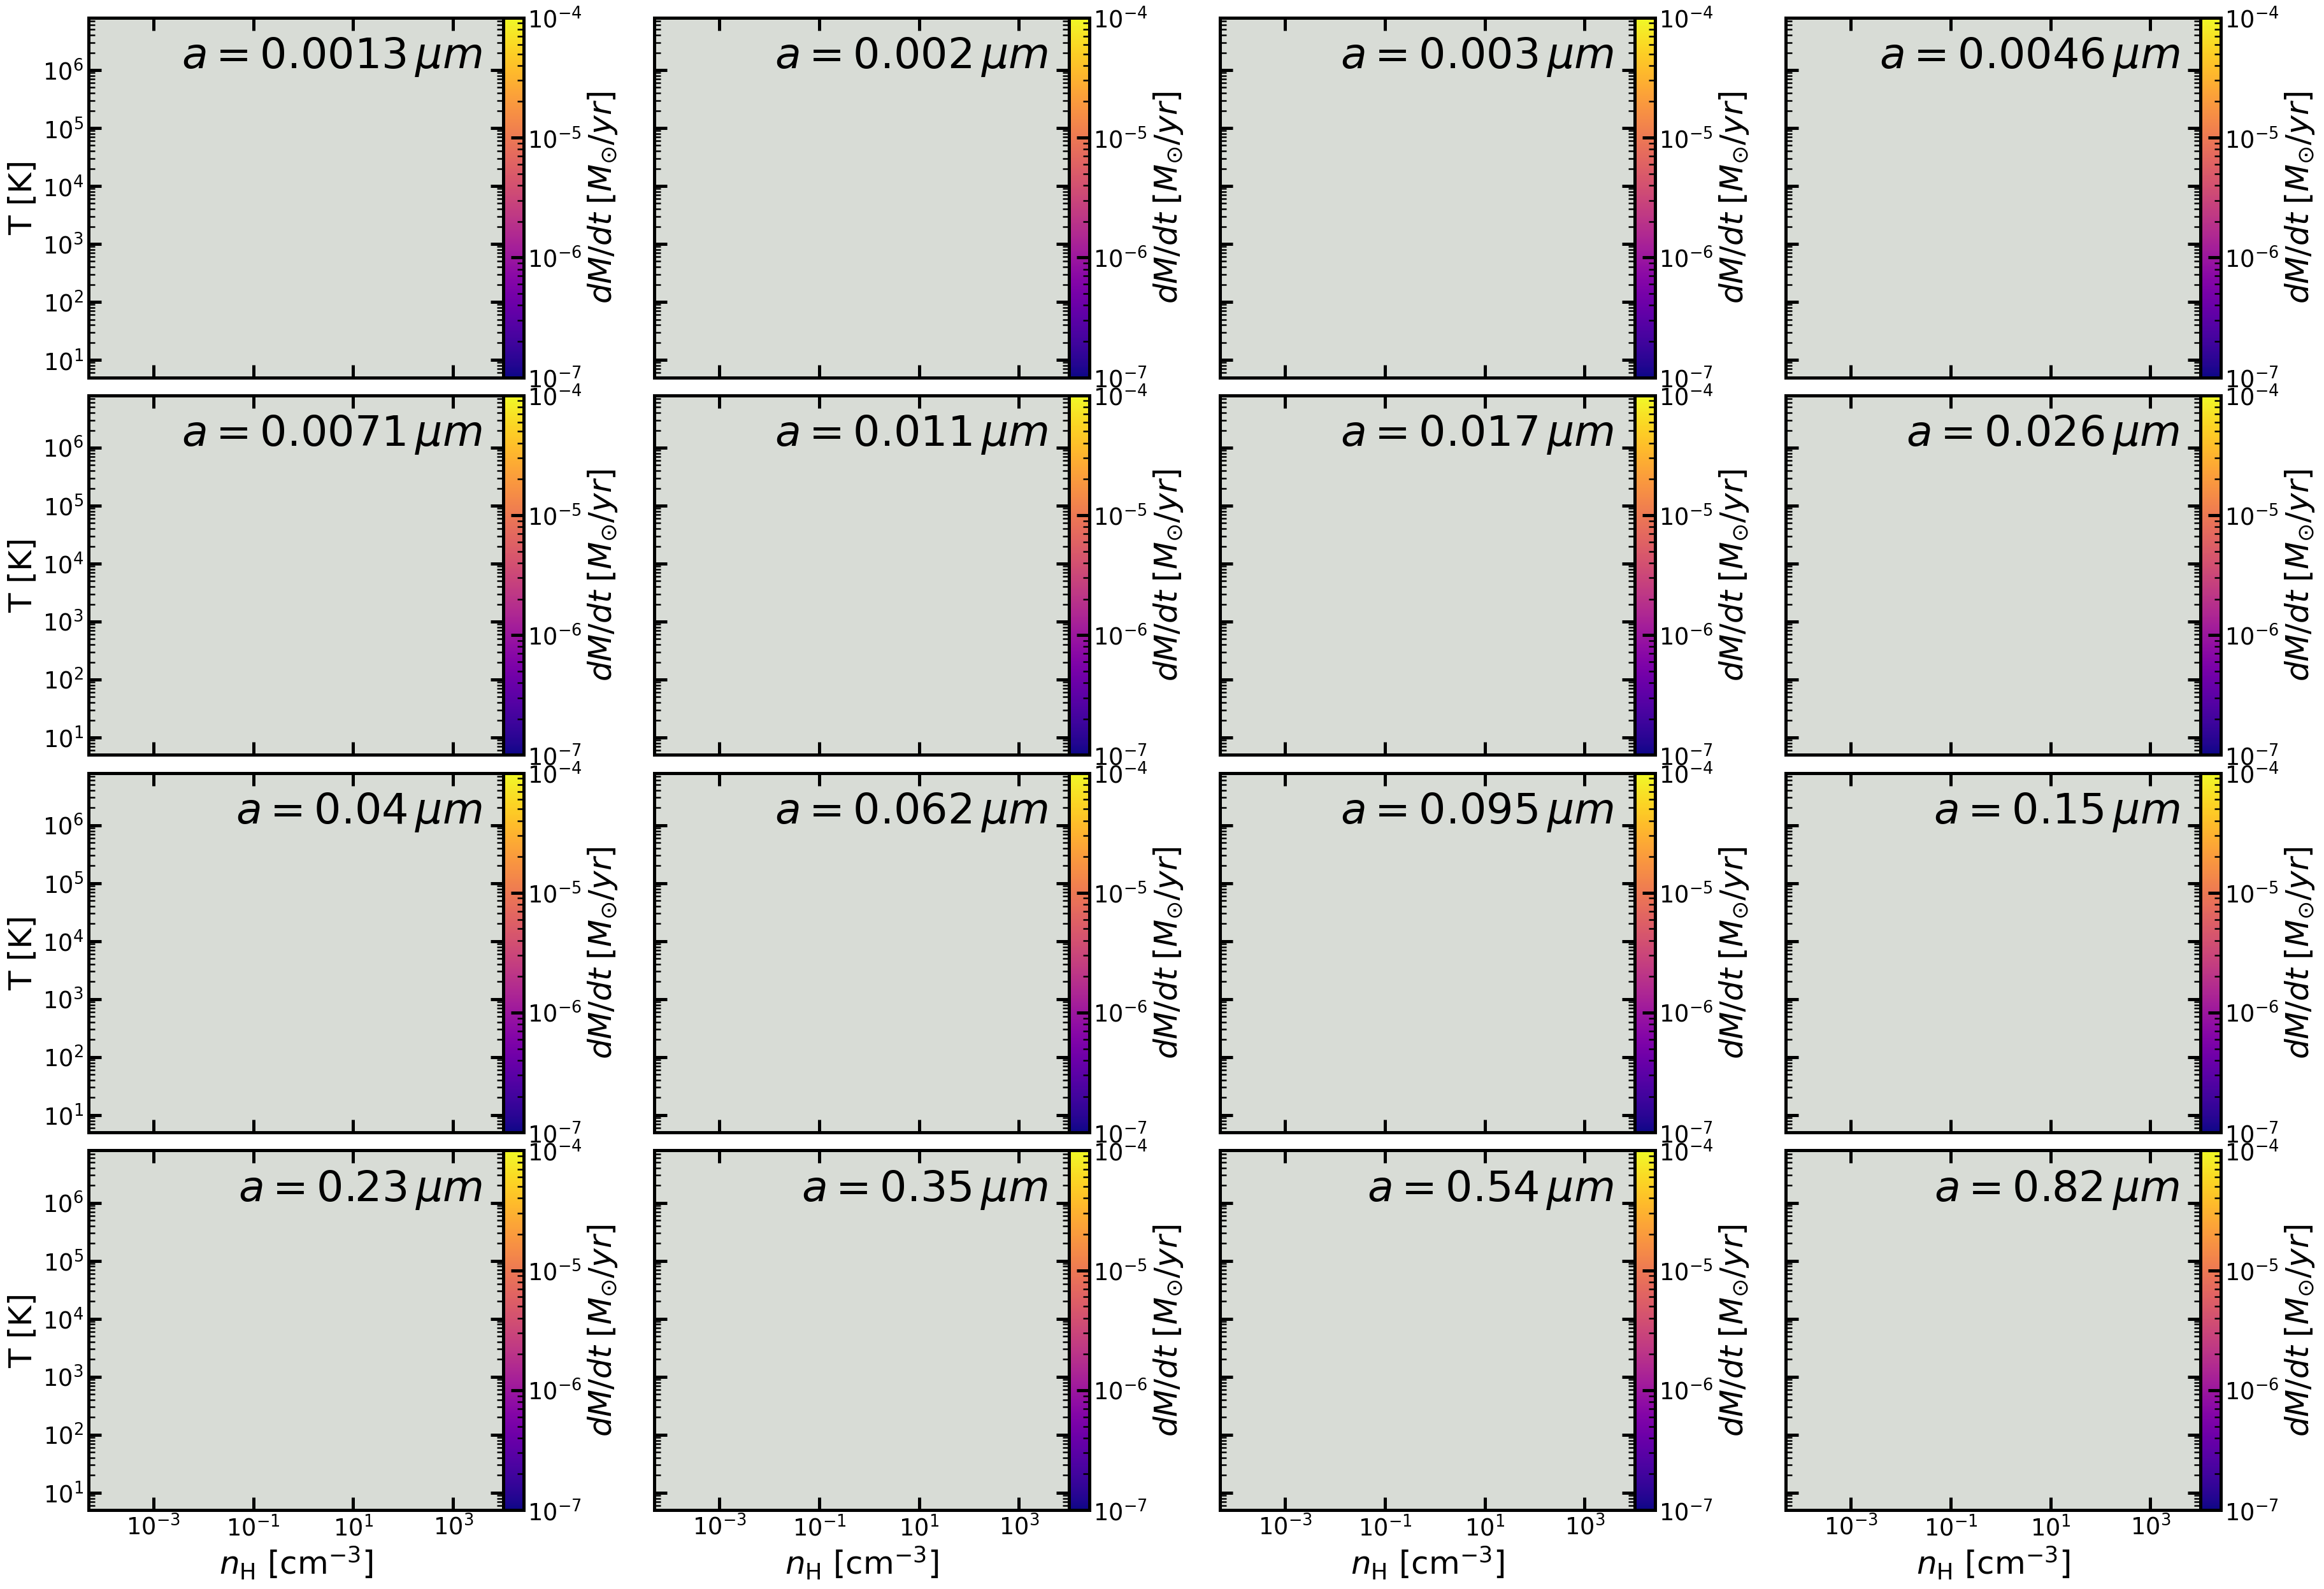

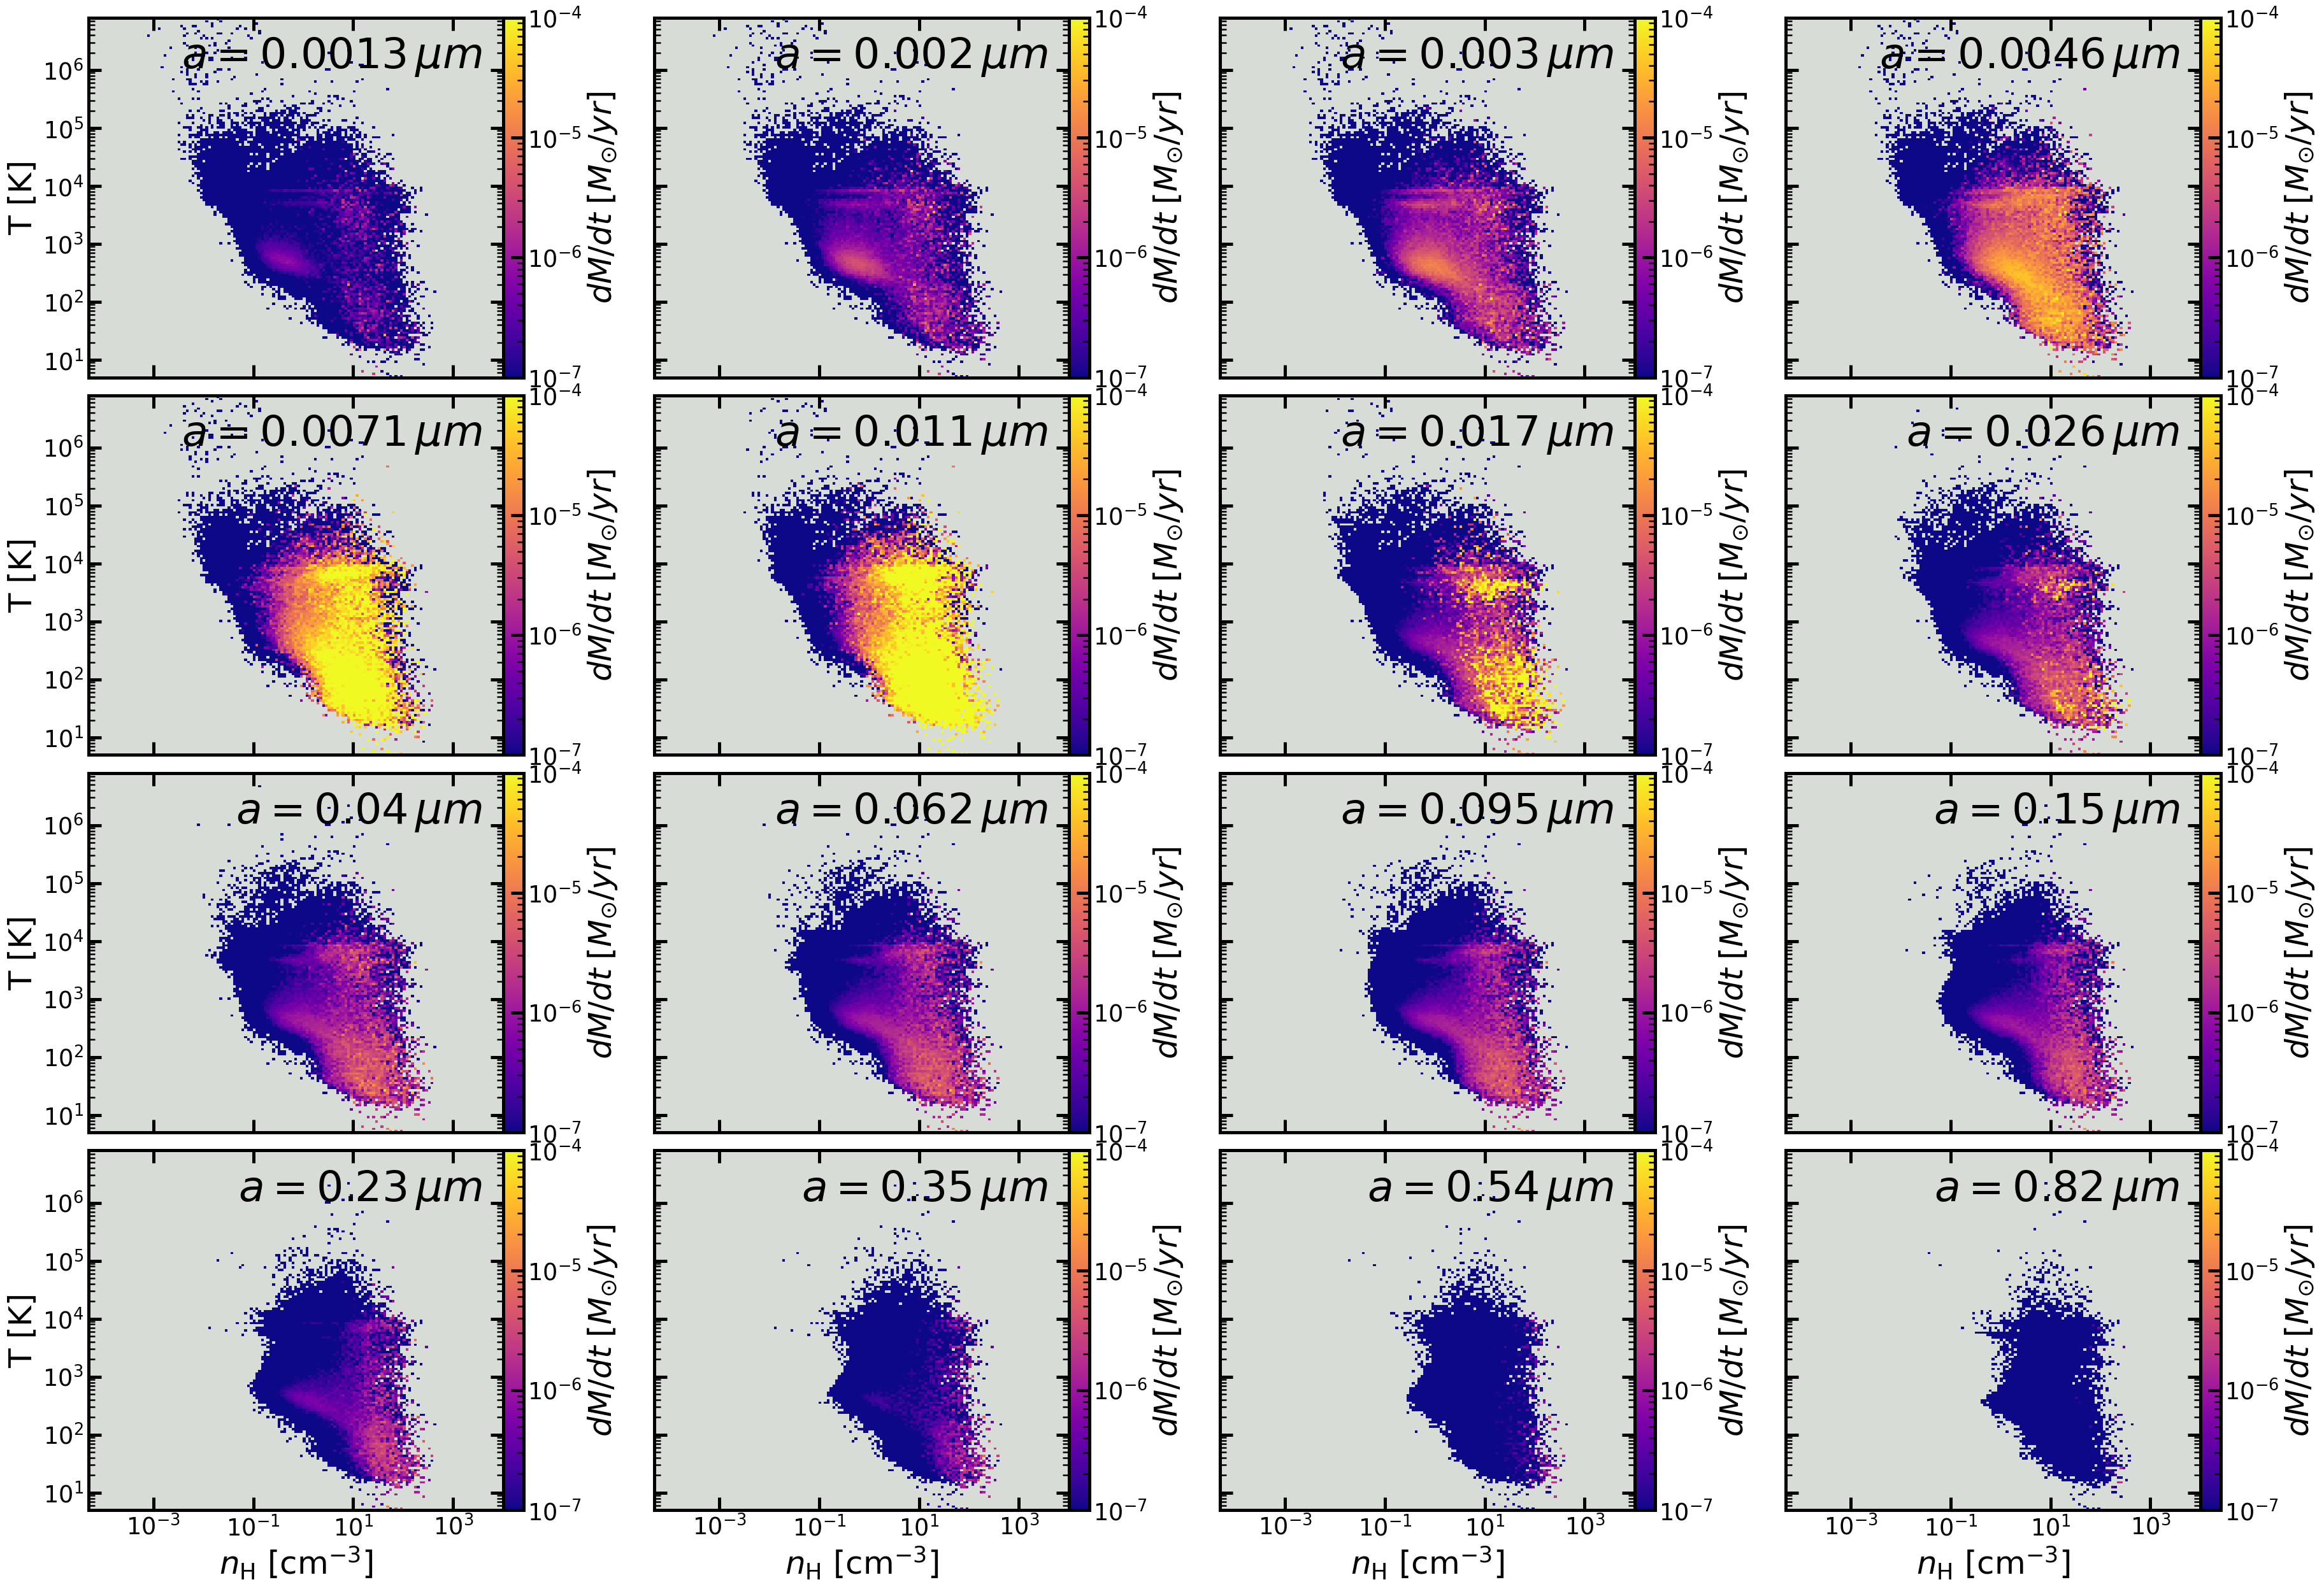

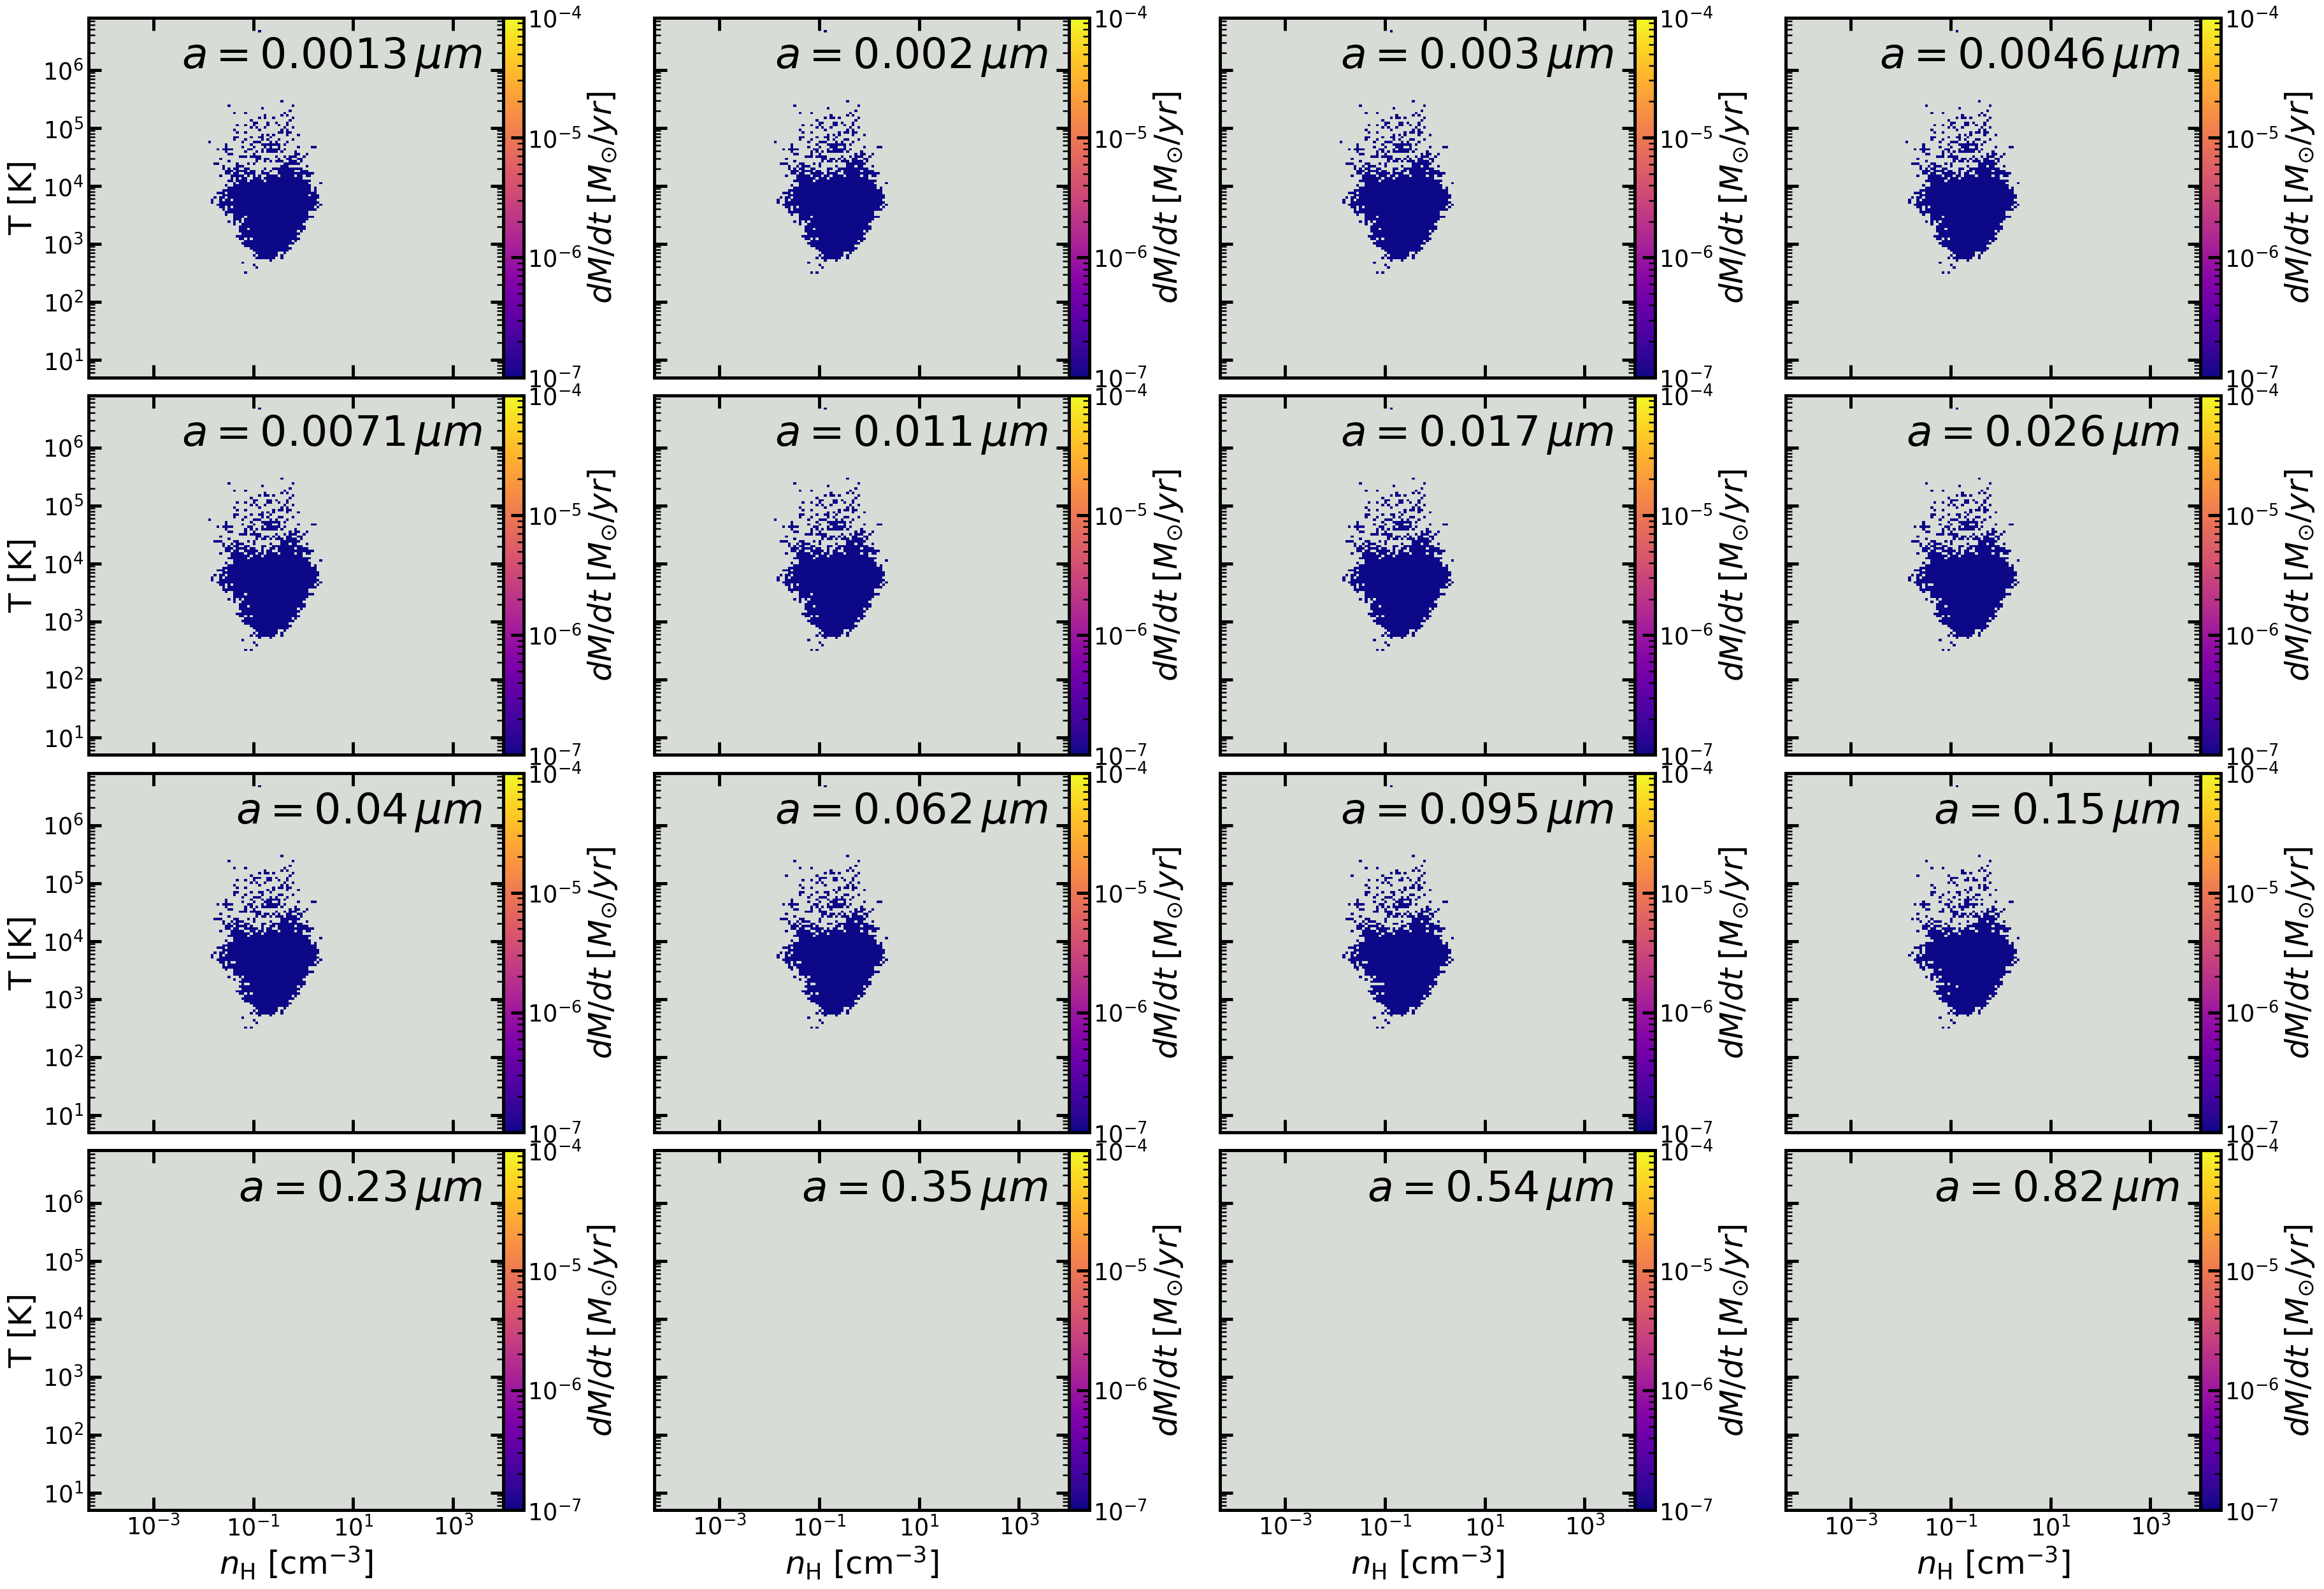

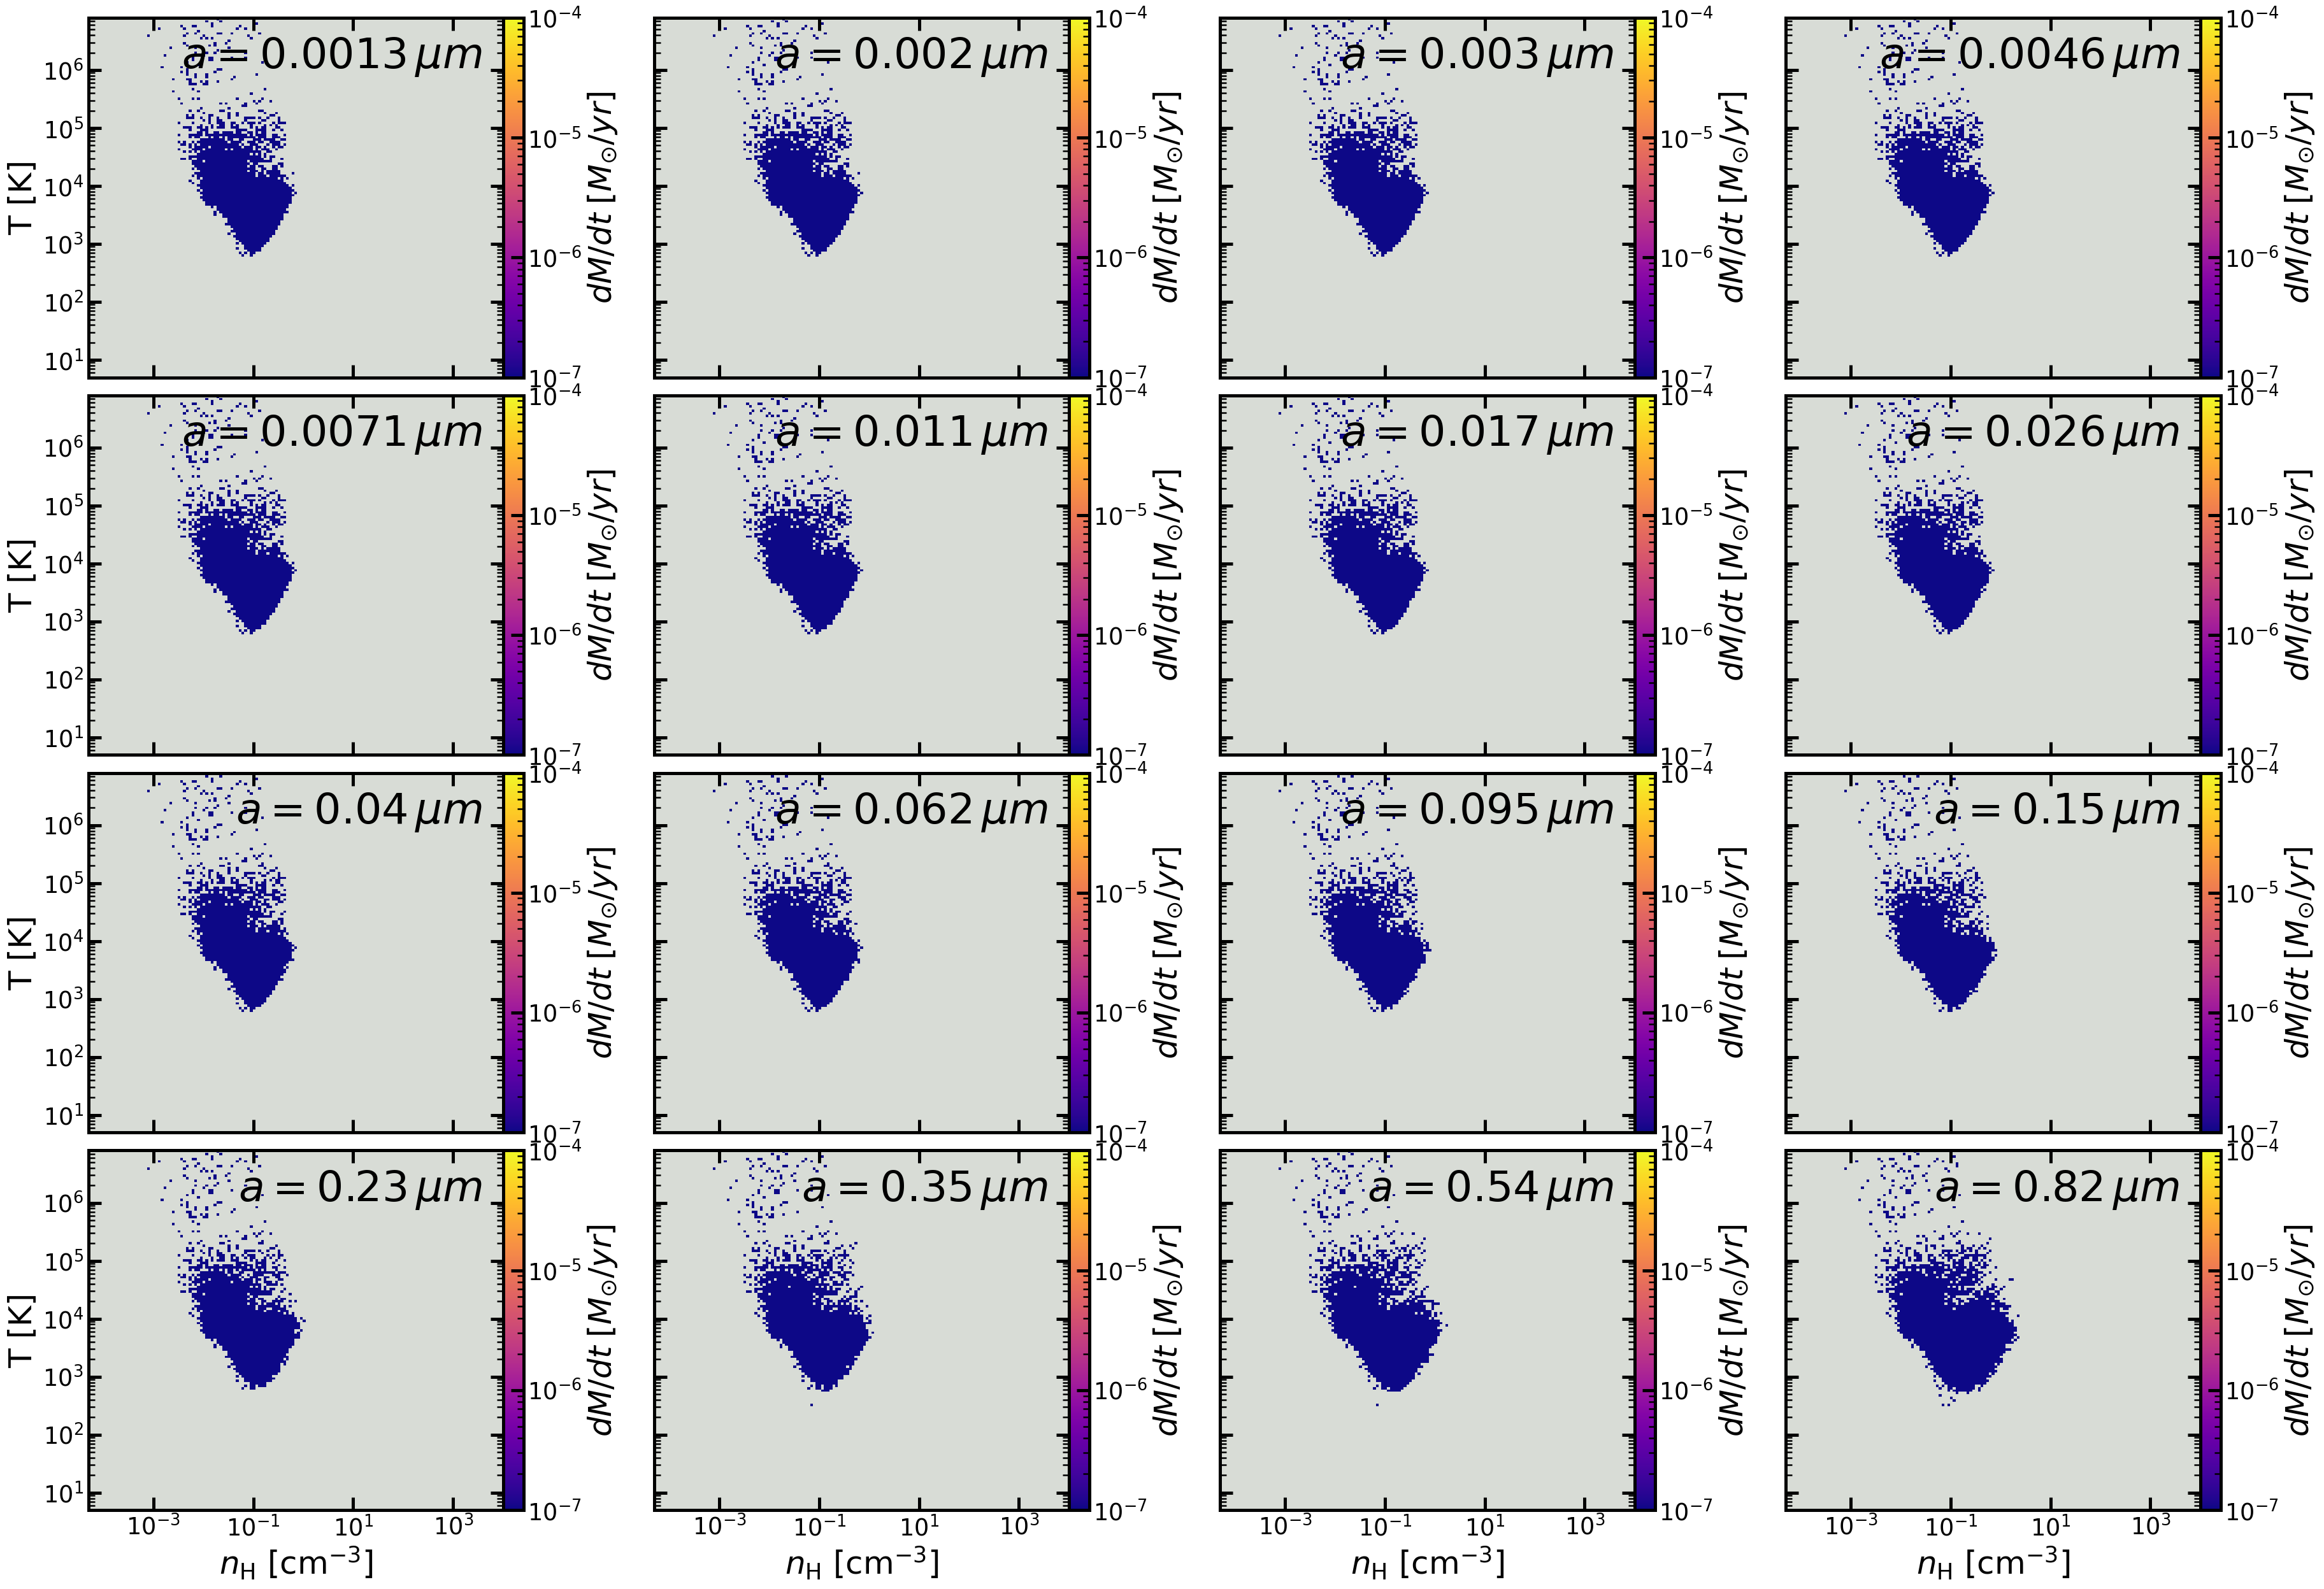

In [157]:

props = ['dMdt_coag','dMdt_shat']
fig_labels = ['coagulation','shattering']
spec_ind = 0
z_log=True
# Number of bins across nH and T space
bin_nums = 150
cmap='plasma'
# nH and T limits
nH_lims = [5E-5,1E4]
T_lims = [5,8E6]


prop_lim=[1E-7,1E-4]


for i,halo in enumerate(halos):
    sp = halo.sp
    print(sp.sdir)
    name = sim_names[i]

    grain_bins = halo.sp.Flag_GrainSizeBins
    a_centers = halo.sp.Grain_Bin_Centers

    G = halo.loadpart(0)





    foutname = 'coag_pos_dMdt_phase_diagram.pdf'
    fig = Figure(grain_bins,ncols=4, sharex='col',sharey='row')
    coag_rate = G.get_property('grain_coag_rate')
    for j in range(grain_bins):
        a_center = a_centers[j]
        # Set up for each plot
        fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')

        coag_rate[coag_rate<0] = 0
        ret = calc.calc_phase_hist_data(coag_rate[:,spec_ind,j], halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='sum')

        ret.statistic[ret.statistic == 0] = np.nan

        X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
        fig.plot_2Dhistogram(j, 'dMdt', X, Y, ret.statistic.T, cmap=cmap, z_lim=prop_lim, z_log=z_log,label=r'$a=%1.2g\,\mu m$'%a_center)

        # Add colorbar to last axis
        fig.add_colorbar(j,cbar_prop='dMdt')

    
    fig.save(plot_dir+name+'_'+str(snap_num)+'_'+foutname)



    foutname = 'coag_neg_dMdt_phase_diagram.pdf'
    fig = Figure(grain_bins,ncols=4, sharex='col',sharey='row')
    coag_rate = G.get_property('grain_coag_rate')
    for j in range(grain_bins):
        a_center = a_centers[j]
        # Set up for each plot
        fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')

        coag_rate[coag_rate>0] = 0
        ret = calc.calc_phase_hist_data(-coag_rate[:,spec_ind,j], halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='sum')

        ret.statistic[ret.statistic == 0] = np.nan

        X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
        fig.plot_2Dhistogram(j, 'dMdt', X, Y, ret.statistic.T, cmap=cmap, z_lim=prop_lim, z_log=z_log,label=r'$a=%1.2g\,\mu m$'%a_center)

        # Add colorbar to last axis
        fig.add_colorbar(j,cbar_prop='dMdt')

    
    fig.save(plot_dir+name+'_'+str(snap_num)+'_'+foutname)


    foutname = 'shat_pos_dMdt_phase_diagram.pdf'
    fig = Figure(grain_bins,ncols=4, sharex='col',sharey='row')
    shat_rate = G.get_property('grain_shat_rate')
    for j in range(grain_bins):
        a_center = a_centers[j]
        # Set up for each plot
        fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')

        shat_rate[shat_rate<0] = 0
        ret = calc.calc_phase_hist_data(shat_rate[:,spec_ind,j], halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='sum')

        ret.statistic[ret.statistic == 0] = np.nan

        X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
        fig.plot_2Dhistogram(j, 'dMdt', X, Y, ret.statistic.T, cmap=cmap, z_lim=prop_lim, z_log=z_log,label=r'$a=%1.2g\,\mu m$'%a_center)

        # Add colorbar to last axis
        fig.add_colorbar(j,cbar_prop='dMdt')

    fig.save(plot_dir+name+'_'+str(snap_num)+'_'+foutname)

    foutname = 'shat_neg_dMdt_phase_diagram.pdf'
    fig = Figure(grain_bins,ncols=4, sharex='col',sharey='row')
    shat_rate = G.get_property('grain_shat_rate')
    for j in range(grain_bins):
        a_center = a_centers[j]
        # Set up for each plot
        fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')

        shat_rate[shat_rate>0] = 0
        ret = calc.calc_phase_hist_data(-shat_rate[:,spec_ind,j], halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='sum')

        ret.statistic[ret.statistic == 0] = np.nan

        X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
        fig.plot_2Dhistogram(j, 'dMdt', X, Y, ret.statistic.T, cmap=cmap, z_lim=prop_lim, z_log=z_log,label=r'$a=%1.2g\,\mu m$'%a_center)

        # Add colorbar to last axis
        fig.add_colorbar(j,cbar_prop='dMdt')

    fig.save(plot_dir+name+'_'+str(snap_num)+'_'+foutname)


In [ ]:

foutname = 'grain_size_dist_check.pdf'
species=['silicates','carbonaceous','iron']
spec_inds = [0,1,2]
ISM_phases = ['cold','warm','hot','coronal']





# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=10




for k,halo in enumerate(halos):
    sp = halo.sp
    print(sp.sdir)
    name = sim_names[k]
    G=halo.loadpart(0)

    fig = Figure(2,ncols=2)
    num_specs = len(species)
    num_phases = len(ISM_phases)
    colors = config.LINE_COLORS[:num_phases]
    linestyles = config.LINE_STYLES[:num_specs]
    linewidth = 2*config.BASE_LINEWIDTH
    fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[2E-9,2E4])
    fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[2E-2,2E-0])

    print("Snapshot time:",sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))


    # Debugging check for dust species masses
    for j, spec in enumerate(species):
        spec_ind = spec_inds[j]
        species_mass = G.get_property('M_spec')[:,spec_ind]*config.Msolar_to_g
        bin_masses =  G.get_property('grain_bin_mass')[:,spec_ind]
        non_zero = species_mass>0
        # Maximum precentage difference between the sum of the bin masses and the total mass
        print(spec)

        print("\t Maximum percentage error:",np.max(np.abs(np.sum(bin_masses,axis=1)[non_zero]-species_mass[non_zero])/species_mass[non_zero]))
        print("\t Total species mass:",np.sum(species_mass/config.Msolar_to_g))
        print("\t Total bin mass:",np.sum(bin_masses/config.Msolar_to_g))  

    for i,phase in enumerate(ISM_phases):
        if i==0:
            y_offset = 3
            MRN_a_vals = np.logspace(-2,-1,10)
            dnda_norm = quad(gse.MRN_dnda, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
            dnda_vals = gse.MRN_dnda(MRN_a_vals)/dnda_norm * np.power(10,y_offset)
            fig.plot_line_data(0,MRN_a_vals,dnda_vals, color='xkcd:grey',linestyle='-')

            y_offset = 1
            dmda_norm = quad(gse.MRN_dmda, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
            dmdloga_vals = gse.MRN_dmda(MRN_a_vals)*MRN_a_vals/dmda_norm * np.power(10,y_offset)
            fig.plot_line_data(1,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle='-')
        
        mask = calc.get_particle_mask(0, sp, mask_criteria=phase)
        print("ISM phase:",phase)
        print('gas mass', np.sum(G.get_property('mass')[mask])/1E10,'Msol')

        for j, spec in enumerate(species):
            
            grain_size_vals, percentile_dnda, percentile_dmdloga  =  grain_size_utils.get_grain_size_distribution(
                G, species=spec, mask=mask,points_per_bin=points_per_bin)


            fig.plot_line_data(0,grain_size_vals,percentile_dnda[0], color=colors[i],linestyle=linestyles[j])
            #fig.plot_shaded_region(0,dnda_bin_points,dnda_stds[:,0],dnda_stds[:,1], color=colors[i])

            # Lines used for the legend handles. Should not show up in plot
            fig.plot_line_data(0,[-1,-1],[-1,-1], color='xkcd:black',linestyle=linestyles[j],label=spec)

            fig.plot_line_data(1,grain_size_vals,percentile_dmdloga[0], color=colors[i],linestyle=linestyles[j], label=phase)
            #fig.plot_shaded_region(1,dmdloga_bin_points,dmdloga_stds[:,0],dmdloga_stds[:,1], color=colors[i],linestyle=linestyles[j])

    fig.set_all_legends(max_cols=2,rescale_font=0.75)

    fig.save(plot_dir+name+'_'+str(snap_num)+'_'+foutname)

# Appendix Plots

## Dust size distribution change for various processes
Create some useful plots showing how an MRN size distribtuion will change due to each dust process along with general timescales for each

#### Coagulation

In [ ]:
foutname = plot_dir+'analytical_coagulation_pred.pdf'

amin=1E-3; amax=1E0
init_dnda = gse.MRN_dnda
def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
bin_nums=64


fig = Figure(2,ncols=2)
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linewidth = 2*config.BASE_LINEWIDTH
fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm),np.power(10,0.5)*np.max(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm)])
fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm),np.power(10,0.5)*np.max(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm)])


fig.plot_line_data(0,a_bins,init_dnda(a_bins)*init_dn_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)
fig.plot_line_data(1,a_bins,init_dmdloga(a_bins)*init_dm_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)

species = ['silicates','carbonaceous','iron']
ISM_phase = 'MC'
dt = 0.01
subcycle_constraint = 'both'

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_shat_coag(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, subcycle_constraints=subcycle_constraint, ISM_phase=ISM_phase, species=spec)
    dmdloga = lambda a: a*dmda(a)

    fig.plot_line_data(0,a_bins,dnda(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

    fig.plot_line_data(1,a_bins,dmdloga(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


#### Shattering
Note the increase at the smallest grain size bin is due to rebinning shattered fragments beyond the minimum grain size back to the smallest bin.

In [ ]:
foutname = plot_dir+'analytical_shattering_pred.pdf'

amin=1E-3; amax=1E0
init_dnda = gse.MRN_dnda
def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
bin_nums=32

fig = Figure(2,ncols=2)
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linewidth = 2*config.BASE_LINEWIDTH
fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm),np.power(10,0.5)*np.max(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm)])
fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm),np.power(10,0.5)*np.max(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm)])


fig.plot_line_data(0,a_bins,init_dnda(a_bins)*init_dn_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)
fig.plot_line_data(1,a_bins,init_dmdloga(a_bins)*init_dm_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)

species = ['silicates','carbonaceous','iron']
ISM_phase = 'WIM'
init_depl = 0.2
dt = 0.02
subcycle_constraints='both'

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_shat_coag(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, depl_frac=init_depl, subcycle_constraints=subcycle_constraints, ISM_phase=ISM_phase, species=spec)
    dmdloga = lambda a: a*dmda(a)

    fig.plot_line_data(0,a_bins,dnda(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

    fig.plot_line_data(1,a_bins,dmdloga(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


In [ ]:
foutname = plot_dir+'analytical_shattering_pred_lognorm.pdf'

amin=1E-3; amax=1E0
init_dnda = gse.lognorm_dnda
def init_dmda(a, a_norm=0.1*config.um_to_cm, sigma_a=0.6):
    return init_dnda(a, a_norm=a_norm, sigma_a=sigma_a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a, a_norm=0.1*config.um_to_cm, sigma_a=0.6):
    return init_dnda(a, a_norm=a_norm, sigma_a=sigma_a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax, args=(0.1,0.6))[0]
init_dm_norm = 1/quad(init_dmda,amin,amax, args=(0.1,0.6))[0]
bin_nums=8


fig = Figure(2,ncols=2)
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linewidth = 2*config.BASE_LINEWIDTH


fig.plot_line_data(0,a_bins,init_dnda(a_bins,a_norm=0.1)*init_dn_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)
fig.plot_line_data(1,a_bins,init_dmdloga(a_bins,a_norm=0.1)*init_dm_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)

fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(new_dnda(a_bins)[new_dnda(a_bins)>0]),np.power(10,0.5)*np.max(new_dnda(a_bins)[new_dnda(a_bins)>0])])
fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(new_dmdloga(a_bins)[new_dmdloga(a_bins)>0]),np.power(10,0.5)*np.max(new_dmdloga(a_bins)[new_dmda(a_bins)>0])])


species = ['silicates','carbonaceous','iron']
ISM_phase = 'WIM'
init_depl = 0.5
dt = 0.005
subcycle_constraints='both'

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_shat_coag(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, depl_frac=init_depl, subcycle_constraints=subcycle_constraints, ISM_phase=ISM_phase, species=spec)
    dmdloga = lambda a: a*dmda(a)

    fig.plot_line_data(0,a_bins,dnda(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

    fig.plot_line_data(1,a_bins,dmdloga(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


#### Accretion

In [ ]:
foutname = plot_dir+'analytical_accretion_pred_enh.pdf'

amin=1E-3; amax=1E0
init_dnda = gse.MRN_dnda
def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
bin_nums=64


fig = Figure(2,ncols=2)
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linewidth = 2*config.BASE_LINEWIDTH
fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm),np.power(10,0.5)*np.max(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm)])
fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm),np.power(10,0.5)*np.max(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm)])


fig.plot_line_data(0,a_bins,init_dnda(a_bins)*init_dn_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)
fig.plot_line_data(1,a_bins,init_dmdloga(a_bins)*init_dm_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)

species = ['silicates','carbonaceous','iron']
ISM_phase = 'CNM'
dt = 0.005
init_depl = 0.1 # initial depletion of key element for dust species
subcycle_constraints='min_bin'

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_acc_sput(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, depl_frac=init_depl)

    fig.plot_line_data(0,a_bins,dnda(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

    fig.plot_line_data(1,a_bins,dmda(a_bins)*a_bins, color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


Testing different subcycling prescriptions.
Decided on using the minimum bin.

In [ ]:
foutname = 'analytical_acretion_pred_subcycling_comparisons.pdf'

amin=1E-3; amax=1E0
init_dnda = gse.MRN_dnda
def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
bin_nums=32


fig = Figure(2,ncols=2)
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linewidth = 2*config.BASE_LINEWIDTH
fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm),np.power(10,0.5)*np.max(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm)])
fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm),np.power(10,0.5)*np.max(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm)])


fig.plot_line_data(0,a_bins,init_dnda(a_bins)*init_dn_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)
fig.plot_line_data(1,a_bins,init_dmdloga(a_bins)*init_dm_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)

spec = 'silicates'
ISM_phase = 'CNM'
dt = 0.001
init_depl = 0.1 # initial depletion of key element for dust species
subcycle_constraints=['none','size','min_bin']

for i,subcycle in enumerate(subcycle_constraints):
    print(subcycle)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_acc_sput(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle, species=spec, depl_frac=init_depl)

    fig.plot_line_data(0,a_bins,dnda(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=subcycle)

    fig.plot_line_data(1,a_bins,dmdloga(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=subcycle)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


#### Thermal Sputtering

In [ ]:
foutname = plot_dir+'analytical_sputtering_pred.pdf'

amin=1E-3; amax=1E0
init_dnda = gse.MRN_dnda
def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
bin_nums=64


fig = Figure(2,ncols=2)
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linewidth = 2*config.BASE_LINEWIDTH
fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm),np.power(10,0.5)*np.max(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm)])
fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm),np.power(10,0.5)*np.max(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm)])


fig.plot_line_data(0,a_bins,init_dnda(a_bins)*init_dn_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)
fig.plot_line_data(1,a_bins,init_dmdloga(a_bins)*init_dm_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)

species = ['silicates','carbonaceous','iron']
ISM_phase = 'HIM'
dt = 0.1
init_depl = 0.1 # initial depletion of key element for dust species
subcycle_constraints='min_bin'

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_acc_sput(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, depl_frac=init_depl)

    fig.plot_line_data(0,a_bins,dnda(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

    fig.plot_line_data(1,a_bins,dmdloga(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


#### Simple visualizations for dust processes diagram

This are parameters every diagram uses.

In [ ]:
amin=1E-3; amax=1E0
init_dnda = gse.MRN_dnda
def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
# Normalize by the total mass
def init_dmdloga_normed(a):
    return init_dmdloga(a)*init_dm_norm

a_vals = np.logspace(np.log10(amin),np.log10(amax),num=100)
dmdloga_limits = [np.power(10,-0.5)*np.min(init_dmdloga_normed(a_vals)),np.power(10,0.5)*np.max(init_dmdloga_normed(a_vals))]


colors = ["xkcd:dark royal blue","xkcd:forest green","xkcd:indian red",]
colors = ["xkcd:red","xkcd:green","xkcd:blue",]
linestyles = config.LINE_STYLES[:5]
linestyles = ['-','--','-.',':']
linewidth = 3.75*config.BASE_LINEWIDTH

species = ['silicates','carbonaceous','iron']
init_depl = 0.3 # initial depletion of key element for dust species


##### Accretion

In [ ]:
foutname = plot_dir+'grain_size_accretion_diagram.pdf'
ISM_phase = 'CNM'
dt = 0.01
subcycle_constraints='min_bin'
bin_nums=64

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da',y_lim=dmdloga_limits, rescale_font=1.5, no_minor_ticks=True)

fig.plot_line_data(0,a_vals,init_dmdloga_normed(a_vals), color='xkcd:grey',linestyle=linestyles[0], linewidth=linewidth,label="initial", zorder=-2)

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_acc_sput(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, depl_frac=init_depl)

    fig.plot_line_data(0,a_bins,dmda(a_bins)*a_bins, color=colors[i],linestyle=linestyles[i+1], linewidth=linewidth,label=spec)

text = r'$\Delta t = %2.0f $ Myr'%(dt*1E3)
fig.add_text(0,0.05,0.95,text,rescale_font=1, ha='left', va='top')

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)

##### Sputtering

In [ ]:
foutname = plot_dir+'grain_size_sputtering_diagram.pdf'

ISM_phase = 'HIM'
dt = 1
subcycle_constraints='min_bin'
bin_nums=64

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da',y_lim=dmdloga_limits, rescale_font=1.5, no_minor_ticks=True)

fig.plot_line_data(0,a_vals,init_dmdloga_normed(a_vals), color='xkcd:grey',linestyle=linestyles[0], linewidth=linewidth,label="initial", zorder=-2)

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda = gse.change_in_grain_distribution_from_acc_sput(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, depl_frac=init_depl)
    

    fig.plot_line_data(0,a_bins,dmda(a_bins)*a_bins, color=colors[i],linestyle=linestyles[i+1], linewidth=linewidth,label=spec)

text = r'$\Delta t = %1.0f $ Gyr'%(dt)
fig.add_text(0,0.05,0.95,text,rescale_font=1, ha='left', va='top')

#fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


##### Shattering

In [ ]:
foutname = plot_dir+'grain_size_shattering_diagram.pdf'

ISM_phase = 'WIM'
dt = 0.05
subcycle_constraints='both'
bin_nums=32

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da',y_lim=dmdloga_limits, rescale_font=1.5, no_minor_ticks=True)

fig.plot_line_data(0,a_vals,init_dmdloga_normed(a_vals), color='xkcd:grey',linestyle=linestyles[0], linewidth=linewidth,label="initial", zorder=-2)

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_shat_coag(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, depl_frac=init_depl)

    fig.plot_line_data(0,a_bins,dmda(a_bins)*a_bins, color=colors[i],linestyle=linestyles[i+1], linewidth=linewidth,label=spec)

text = r'$\Delta t = %3.0f $ Myr'%(dt*1E3)
fig.add_text(0,0.05,0.95,text,rescale_font=1, ha='left', va='top')

#fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


##### Coagulation

In [ ]:
foutname = plot_dir+'grain_size_coagulation_diagram.pdf'

ISM_phase = 'MC'
dt = 0.01
subcycle_constraints='both'
bin_nums=32

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da',y_lim=dmdloga_limits, rescale_font=1.5, no_minor_ticks=True)

fig.plot_line_data(0,a_vals,init_dmdloga_normed(a_vals), color='xkcd:grey',linestyle=linestyles[0], linewidth=linewidth,label="initial", zorder=-2)

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_shat_coag(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, depl_frac=init_depl)

    fig.plot_line_data(0,a_bins,dmda(a_bins)*a_bins, color=colors[i],linestyle=linestyles[i+1], linewidth=linewidth,label=spec)

text = r'$\Delta t = %3.0f $ Myr'%(dt*1E3)
fig.add_text(0,0.05,0.95,text,rescale_font=1, ha='left', va='top')

#fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)

##### SNe Shocks

In [ ]:

foutname = plot_dir+'grain_size_SNe_shock_diagram.pdf'

# Set limits for size distribution

bins=500
a_bins = np.logspace(np.log10(amin),np.log10(amax), bins)

dt = 0.0001
approx='shat_sput_shat'

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da',y_lim=dmdloga_limits, rescale_font=1.5, no_minor_ticks=True)

fig.plot_line_data(0,a_vals,init_dmdloga_normed(a_vals), color='xkcd:grey',linestyle=linestyles[0], linewidth=linewidth,label="initial", zorder=-2)

SNe_proc = gse.SNe_Dust_Processing(init_dnda,[amin,amax], bins=bins)

for i, spec in enumerate(species):
    f_SNe,dnda_SNe,dmda_SNe = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', species=spec)
    # Renorm dmda to 1/total_mass/fSNe
    total_mass = quad(dmda_SNe,amin,amax)[0]
    fig.plot_line_data(0,a_bins,dmda_SNe(a_bins)*a_bins/(total_mass), color=colors[i],linestyle=linestyles[i+1], linewidth=linewidth,label=spec)

text = r'$\Delta t \sim %1.1f $ Myr'%(dt*1E3)
fig.add_text(0,0.05,0.95,text,rescale_font=1, ha='left', va='top')

#fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)

## Thermal Erosion Rate Comparison

In [ ]:

Tsput = 2E6; 
T_limits = [3E4,5E7]
T = np.logspace(np.log10(T_limits[0]), np.log10(T_limits[1]), 100)
Y_Tsai = 3.2E-18 / (np.power((Tsput/T),2.5) + 1) * config.cm_to_um / config.sec_to_Gyr;

x = np.log10(T)
Y_carb = np.power(10,-226.85176513236104 + 133.44188274964907*x - 32.57239140566398*np.power(x,2) + 4.005662246063896*np.power(x,3) - 0.247470977981441*np.power(x,4) + 0.0061211887939359045*np.power(x,5)) / 1E-9
Y_sil = np.power(10,-226.94973608304852 + 127.94268281713853*x - 29.91964844780188*np.power(x,2) + 3.5354022742488267*np.power(x,3) - 0.21055294512995676*np.power(x,4) + 0.0050362487746130735*np.power(x,5)) / 1E-9
Y_Fe = np.power(10,-156.87812803401695 + 82.10982096578688*x - 18.237504267725893*np.power(x,2) + 2.0691984369187524*np.power(x,3) - 0.11933080830511887*np.power(x,4) + 0.00277875641831501*np.power(x,5)) / 1E-9
N=5
colors = config.LINE_COLORS[:N]
linestyles = config.LINE_STYLES[:N]
linewidth = 2*config.BASE_LINEWIDTH

y_label = r'$Y_{\rm dust}\;(\mu m \; {\rm Gyr}^{-1} \;{\rm cm^{3}})$'
fig = Figure(1)
fig.set_axis(0, 'T', 'erosion_rate', x_lim=T_limits, x_log=True, y_label=y_label, y_lim=[np.max(Y_sil)*1E-3, 2*np.max(Y_sil)], y_log=True)

fig.plot_line_data(0, T, Y_Tsai, color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH, label='Tsai+95')
i=0
fig.plot_line_data(0, T, Y_sil, color=colors[i], linestyle=linestyles[i+1], linewidth=2*config.BASE_LINEWIDTH, label='silicates')
i=1
fig.plot_line_data(0, T, Y_carb, color=colors[i], linestyle=linestyles[i+1], linewidth=2*config.BASE_LINEWIDTH, label='carbon')
i=2
fig.plot_line_data(0, T, Y_Fe, color=colors[i], linestyle=linestyles[i+1], linewidth=2*config.BASE_LINEWIDTH, label='iron')

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(plot_dir+'dust_erosion_rate.pdf')

## Sub-Resolved Gas Clumping

In [ ]:
from scipy.special import erfc,erf

foutname = 'clumping_factor.pdf'

M_limits = [0.2,100]
C_limits = [0.1,100]
nmaxs = [1E3,1E4,1E3,1E4]
ns=[1E0,1E0,1E2,1E2]


M = np.logspace(np.log10(M_limits[0]),np.log10(M_limits[1]),100)
b = 0.5 # ratio of solenoidal to compressive turbulence
sigma = np.sqrt(np.log(1+b*b*M*M))

N = len(nmaxs)

colors = config.LINE_COLORS[:N]
linestyles = config.LINE_STYLES[:N]
linewidth = 2*config.BASE_LINEWIDTH

x_label = r'$\mathcal{M}$'
y_label = r'$C_{2,k}$'
fig = Figure(1)
fig.set_axis(0, 'M', 'clumping_factor', x_lim=M_limits, x_log=True, x_label=x_label, y_label=y_label, y_lim=C_limits, y_log=True)



for i in range(N):
    nmax=nmaxs[i]
    n=ns[i]
    clumping_factor = np.exp(sigma*sigma)/2 * erfc((3/2*sigma*sigma-np.log(nmax/n)) / (np.sqrt(2)*sigma))
    label = r'$\bar{n}=10^{%i}\,{\rm cm^{-3}}$; $ n_{\rm max}=10^{%i}\,{\rm cm^{-3}}$'%(np.log10(n),np.log10(nmax))
    fig.plot_line_data(0,M,clumping_factor,label=label,linestyle=linestyles[i],color=colors[i], linewidth=linewidth)
    
    if i == N-1:
        T_clumping_factor = 1/(np.exp(sigma*sigma)/2 * (1 + erf((3/2*sigma*sigma + np.log(nmax/n)) / (np.sqrt(2)*sigma))))
        label = r'$C_T$'
        fig.plot_line_data(0,M,T_clumping_factor,label=label,linestyle='-',color='xkcd:grey', linewidth=1.7*linewidth,zorder=-3)

fig.set_all_legends(rescale_font=0.7,max_cols=1)

fig.save(plot_dir+foutname)

## Turbulence Driven Grain Velocity

In [ ]:

foutname = plot_dir+'Lebreuilly23_relative_grain_velocity_WIM_MC.pdf'

N=5
amin=1E-3*config.um_to_cm; amax=0.5*config.um_to_cm
a1s = np.logspace(np.log10(amin),np.log10(amax))
a2s = np.logspace(np.log10(amin),np.log10(amax),num=N)

fig = Figure(1,ncols=2)
colors = config.LINE_COLORS[:N]
linestyles = config.LINE_STYLES[:N]
linewidth = 2*config.BASE_LINEWIDTH

fig.set_axis(0, 'grain_size', 'velocity', y_lim=[0.001,100], y_label='vrel (km/s)',y_log=True)


spec= 'silicates'

spec_props = gse.dust_species_properties(spec)
dust_atomic_weight = spec_props['dust_atomic_weight']
key_mass = spec_props['key_mass']
key_abundance = spec_props['key_abundance']
key_num_atoms = spec_props['key_num_atoms'] 
P1 = spec_props['P1']
v_shat = spec_props['v_shat']/1E5 # km/s
poisson = spec_props['poisson']
youngs = spec_props['youngs']
gamma = spec_props['gamma']
rho_c = spec_props['rho_c']


# Plot coagulation velocities
for i,a2 in enumerate(a2s):
    v_coag = gse.v_coagulation(a2,a2,rho_c, poisson, youngs, gamma)/1E5 # km/s
    x_values = a1s * config.cm_to_um  # Use the x values from a1s
    y_values = np.full(len(a1s), v_coag)  # Create constant y values
    fig.plot_line_data(0,x_values,y_values, color=colors[i], linewidth=0.25*linewidth, linestyle='dashed')


for i,a2 in enumerate(a2s):
    vrel = np.zeros(len(a1s))
    for j,a1 in enumerate(a1s):
        vrel[j] = gse.grain_relative_velocity(a1, a2, rho_c, ISM_phase='CNM', scheme='Lebreuilly23')*1E-5
    


    fig.plot_line_data(0,a1s*config.cm_to_um,vrel, color=colors[i], label='%1.3f '%(a2*config.cm_to_um) + r'$\mu m$', linewidth=linewidth)

for i,a2 in enumerate(a2s):
    vrel = np.zeros(len(a1s))
    for j,a1 in enumerate(a1s):
        vrel[j] = gse.grain_relative_velocity(a1, a2, rho_c,ISM_phase='MC', scheme='Lebreuilly23')*1E-5
    


    fig.plot_line_data(0,a1s*config.cm_to_um,vrel, color=colors[i], linewidth=0.5*linewidth)

fig.set_all_legends(rescale_font=0.75)
fig.save(foutname)

In [ ]:

foutname = plot_dir+'Li21_relative_grain_velocity_WIM_MC.pdf'

N=5
amin=1E-3*config.um_to_cm; amax=1E0*config.um_to_cm
a1s = np.logspace(np.log10(amin),np.log10(amax))
a2s = np.logspace(np.log10(amin),np.log10(amax),num=N)

fig = Figure(1,ncols=2)
colors = config.LINE_COLORS[:N]
linestyles = config.LINE_STYLES[:N]
linewidth = 2*config.BASE_LINEWIDTH

fig.set_axis(0, 'grain_size', 'velocity', y_lim=[0.001,100], y_label='vrel (km/s)',y_log=True)

spec_props = gse.dust_species_properties(spec)
dust_atomic_weight = spec_props['dust_atomic_weight']
key_mass = spec_props['key_mass']
key_abundance = spec_props['key_abundance']
key_num_atoms = spec_props['key_num_atoms'] 
P1 = spec_props['P1']
v_shat = spec_props['v_shat']/1E5 # km/s
poisson = spec_props['poisson']
youngs = spec_props['youngs']
gamma = spec_props['gamma']
rho_c = spec_props['rho_c']


# Plot coagulation velocities
for i,a2 in enumerate(a2s):
    v_coag = gse.v_coagulation(a2,a2,rho_c, poisson, youngs, gamma)/1E5 # km/s
    x_values = a1s * config.cm_to_um  # Use the x values from a1s
    y_values = np.full(len(a1s), v_coag)  # Create constant y values
    fig.plot_line_data(0,x_values,y_values, color=colors[i], linewidth=0.25*linewidth, linestyle='dashed')


for i,a2 in enumerate(a2s):
    vrel = np.zeros(len(a1s))
    for j,a1 in enumerate(a1s):
        vrel[j] = gse.grain_relative_velocity(a1, a2, rho_c, 'CNM', scheme='Li21')*1E-5
    


    fig.plot_line_data(0,a1s*config.cm_to_um,vrel, color=colors[i], label='%1.3f '%(a2*config.cm_to_um) + r'$\mu m$', linewidth=linewidth)
    
for i,a2 in enumerate(a2s):
    vrel = np.zeros(len(a1s))
    for j,a1 in enumerate(a1s):
        vrel[j] = gse.grain_relative_velocity(a1, a2, rho_c,'MC', scheme='Li21')*1E-5
    


    fig.plot_line_data(0,a1s*config.cm_to_um,vrel, color=colors[i], linewidth=0.5*linewidth)

fig.set_all_legends(rescale_font=0.75)
fig.save(foutname)

In [ ]:

foutname = plot_dir+'HC23_relative_grain_velocity_WIM_MC.pdf'

N=5
amin=1E-3*config.um_to_cm; amax=0.5*config.um_to_cm
a1s = np.logspace(np.log10(amin),np.log10(amax))
a2s = np.logspace(np.log10(amin),np.log10(amax),num=N)

fig = Figure(1,ncols=2)
colors = config.LINE_COLORS[:N]
linestyles = config.LINE_STYLES[:N]
linewidth = 2*config.BASE_LINEWIDTH

fig.set_axis(0, 'grain_size', 'velocity', y_lim=[0.001,100], y_label='vrel (km/s)',y_log=True)


spec= 'silicates'

spec_props = gse.dust_species_properties(spec)
dust_atomic_weight = spec_props['dust_atomic_weight']
key_mass = spec_props['key_mass']
key_abundance = spec_props['key_abundance']
key_num_atoms = spec_props['key_num_atoms'] 
P1 = spec_props['P1']
v_shat = spec_props['v_shat']/1E5 # km/s
poisson = spec_props['poisson']
youngs = spec_props['youngs']
gamma = spec_props['gamma']
rho_c = spec_props['rho_c']


# Plot coagulation velocities
for i,a2 in enumerate(a2s):
    v_coag = gse.v_coagulation(a2,a2,rho_c, poisson, youngs, gamma)/1E5 # km/s
    x_values = a1s * config.cm_to_um  # Use the x values from a1s
    y_values = np.full(len(a1s), v_coag)  # Create constant y values
    fig.plot_line_data(0,x_values,y_values, color=colors[i], linewidth=0.25*linewidth, linestyle='dashed')


for i,a2 in enumerate(a2s):
    vrel = np.zeros(len(a1s))
    for j,a1 in enumerate(a1s):
        vrel[j] = gse.grain_relative_velocity(a1, a2, rho_c, 'CNM', scheme='HC23')*1E-5
    


    fig.plot_line_data(0,a1s*config.cm_to_um,vrel, color=colors[i], label='%1.3f '%(a2*config.cm_to_um) + r'$\mu m$', linewidth=linewidth)

for i,a2 in enumerate(a2s):
    vrel = np.zeros(len(a1s))
    for j,a1 in enumerate(a1s):
        vrel[j] = gse.grain_relative_velocity(a1, a2, rho_c,'MC', scheme='HC23')*1E-5
    


    fig.plot_line_data(0,a1s*config.cm_to_um,vrel, color=colors[i], linewidth=0.5*linewidth)

fig.set_all_legends(rescale_font=0.75)
fig.save(foutname)

In [ ]:
v1 = 1
v2 = 1

N=10000


xlim= [0.1,100]
ylim = [0,1]

colors = config.LINE_COLORS[:2]
linestyles = config.LINE_STYLES[:2]
linewidth = 2*config.BASE_LINEWIDTH

labels = ['Li+21','Hirashita+09']

y_label = 'CDF'
x_label = r'$v_{\rm rel}$'
fig = Figure(1)
fig.set_axis(0, 'vrel', 'prob', x_lim=xlim, x_log=True, x_label=x_label, y_label=y_label, y_lim=ylim, y_log=False)

# Determine relative velocities by taking the difference of x, y, and z components
vrel = np.zeros(N)
for i in range(3):
    v1i=np.random.normal(0,v1*v1/3,1000)
    v2i=np.random.normal(0,v2*v2/3,1000)
    vrel = np.power(v1i-v2i,2)
vrel=np.sqrt(vrel)

#fig.plot_1Dhistogram(0,vrel,bin_log=True)
fig.plot_1Dhistogram(0,vrel,bin_log=True,cumulative=True,label=labels[0])


impact_angle = np.random.uniform(-1,1,N)
vrel = np.sqrt(v1*v1 + v2*v2 - 2*v1*v2*impact_angle)
fig.plot_1Dhistogram(0,vrel,bin_log=True,cumulative=True,label=labels[1])

fig.set_all_legends()



## Coagulation Velocity

In [ ]:
foutname=plot_dir+'coagulation_velocity.pdf'

alim= [0.001,1]
a_vals = np.logspace(np.log10(alim[0]),np.log10(alim[1]),100)*1E-4
ylim = [5E-4,1E1]

colors = config.LINE_COLORS[:3]
linestyles = config.LINE_STYLES[:3]
linewidth = config.LINE_WIDTHS[[0,3]]


y_label = r'$v_{\rm coag}$ (km/s)'
x_label = r'$a_j$ ($\mu m$)'

fig = Figure(1)
fig.set_axis(0, 'vcoag', 'aj', x_lim=alim, x_log=True, x_label=x_label, y_label=y_label, y_lim=ylim, y_log=True)

species = ['silicates','carbonaceous','iron']
# The grain sizes for the target grain
aks = np.array([0.1,0.001])*1E-4 # cm

for i in range(len(species)):
    
    # Get species properties
    spec_props = gse.dust_species_properties(species[i])
    dust_atomic_weight = spec_props['dust_atomic_weight']
    key_mass = spec_props['key_mass']
    key_abundance = spec_props['key_abundance']
    key_num_atoms = spec_props['key_num_atoms'] 
    P1 = spec_props['P1']
    v_shat = spec_props['v_shat']/1E5 # km/s
    poisson = spec_props['poisson']
    youngs = spec_props['youngs']
    gamma = spec_props['gamma']
    rho_c = spec_props['rho_c']

    for j, ak in enumerate(aks):
        v_coag = gse.v_coagulation(ak,a_vals,rho_c, poisson, youngs, gamma)/1E5 # km/s

        fig.plot_line_data(0,a_vals/1E-4,v_coag,label=species[i],linestyle=linestyles[i],color=colors[i], linewidth=linewidth[j])

        if j==0:
            if i == len(species)-1: vshat_label=r'$v_{\rm shat}$'
            else: vshat_label=None
            vshat_line = mlines.Line2D(alim,[v_shat,v_shat], c='xkcd:grey',label=vshat_label,linewidth=config.BASE_LINEWIDTH,linestyle=linestyles[i],zorder=-3)
            fig.add_artist(0,vshat_line)
        
        if i == len(species)-1:
            new_label=r'$a_k=%g \, \mu m$'%(ak*1E4)
            fig.plot_line_data(0,[config.EPSILON],[config.EPSILON],label=new_label,linestyle='-',color='xkcd:black', linewidth=linewidth[j])



fig.set_all_legends(rescale_font=1/1.25,ncols=2,loc='lower left')

fig.save(foutname)

# Analytical Testing

## SNe Dust Destruction

### Sputtering and shattering efficiency functions

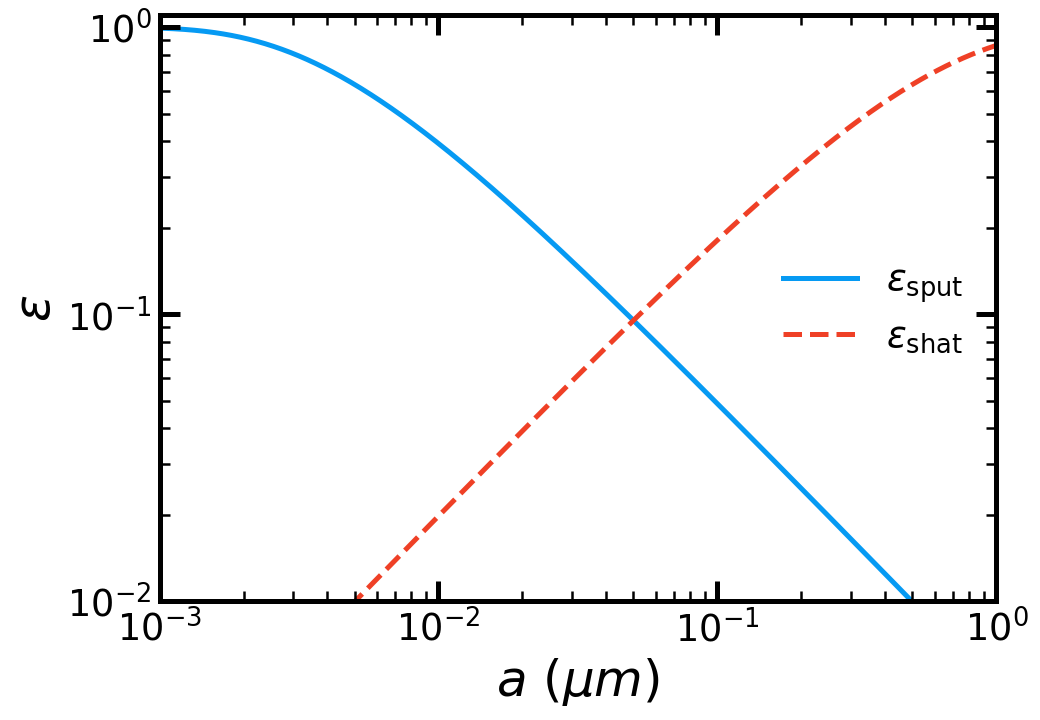

In [110]:
N = 5

colors = config.LINE_COLORS[:N]
linestyles = config.LINE_STYLES[:N]
linewidth = 2*config.BASE_LINEWIDTH


a_sput = 0.05; # microns
a_shat = 0.05;
delta_sput = 0.1;
delta_shat = 0.1;
a_limit = [1E-3,1E0]
a = np.logspace(np.log10(a_limit[0]),np.log10(a_limit[1]),500)


y_label = r'$ \epsilon $'
x_label = r'$a$ ($\mu m$)'
eff_limits = [1E-2,1.1]
fig = Figure(1)
fig.set_axis(0, 'a', 'eff', x_lim=a_limit, x_log=True, x_label=x_label, y_label=y_label, y_lim=eff_limits, y_log=True)


def eff_sput(a):
        return (1 - np.exp(-(delta_sput / (a/a_sput))))
def eff_shat(a):
        return (1 - np.exp(-(delta_shat * (a/a_shat))))

i=0
fig.plot_line_data(0,a,eff_sput(a),label=r'$\epsilon_{\rm sput}$',color=colors[i], linestyle=linestyles[i])
i=1
fig.plot_line_data(0,a,eff_shat(a),label=r'$\epsilon_{\rm shat}$',color=colors[i], linestyle=linestyles[i])
fig.set_all_legends()

### Total dust destruction fraction
This tests the shattering+sputtering and shattering+sputting+shattering routines for varying sputtering and shattering efficiencies

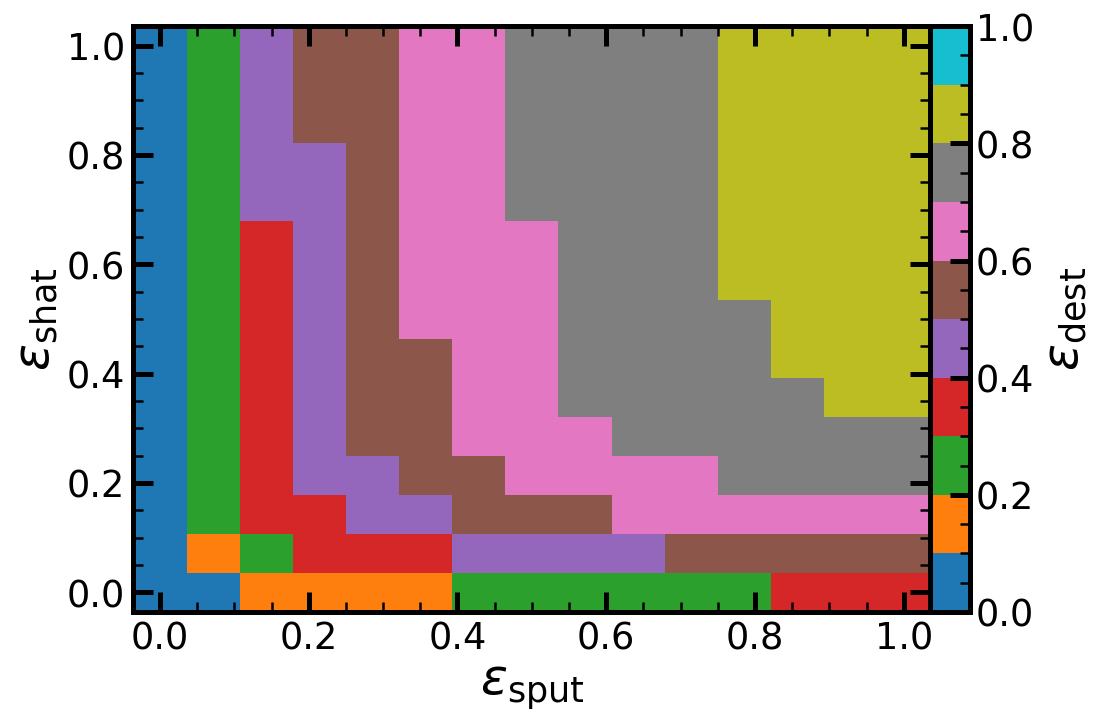

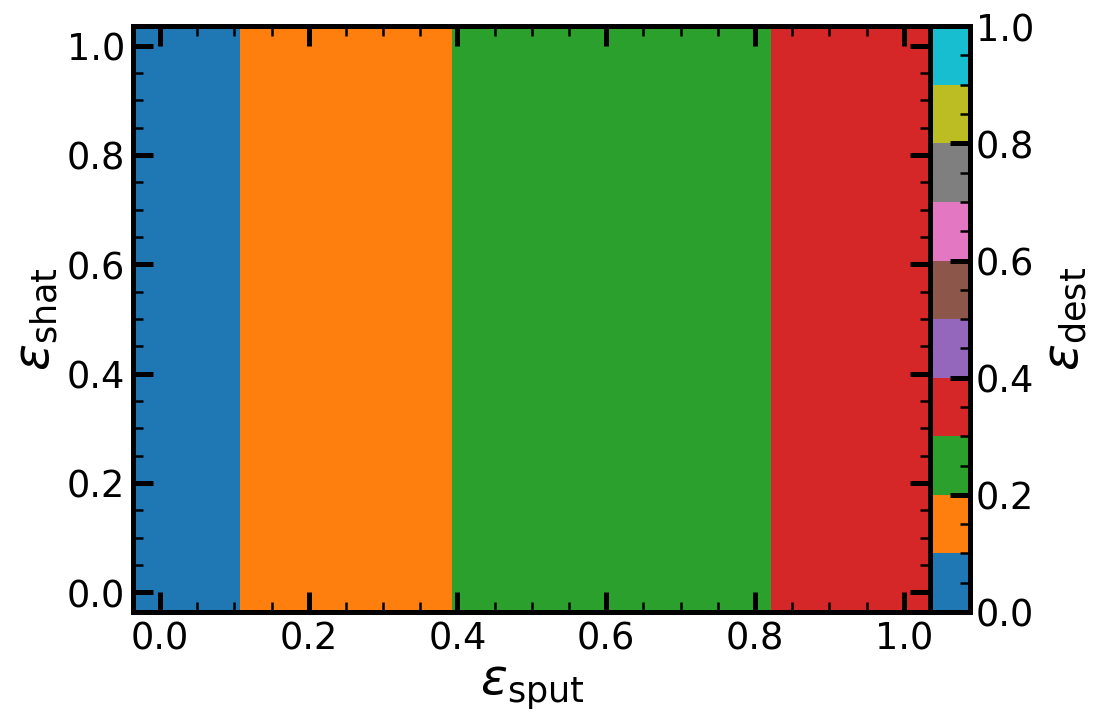

In [111]:
# Set limits for size distribution
amin = 1E-3
amax=1E0
bins=500
a_bins = np.logspace(np.log10(amin),np.log10(amax), bins)

a_sput = 0.05; # microns
a_shat = 0.05;
a_frag_max = a_shat

init_dnda=gse.MRN_dnda

N=15
eff_shats = np.linspace(0,1,N)
eff_sputs = eff_shats
f_dest = np.zeros((N,N))

color_N = 5
colors = config.LINE_COLORS[:color_N]
linestyles = config.LINE_STYLES[:color_N]
linewidths = config.LINE_WIDTHS[[0,color_N]]

fig = Figure(1)
x_label = r'$\epsilon_{\rm sput}$'
y_label = r'$\epsilon_{\rm shat}$'
fig.set_axis(0, 'sput', 'shat', x_lim=[0,1], x_log=False, x_label=x_label, y_label=y_label, y_lim=[0,1], y_log=False)



color_N = 5
colors = config.LINE_COLORS[:color_N]
linestyles = config.LINE_STYLES[:color_N]
linewidths = config.LINE_WIDTHS[[0,color_N]]

approx='shat_sput_shat'

SNe_proc = gse.SNe_Dust_Processing(init_dnda,[amin,amax], bins=bins)

for i,eff_sh in enumerate(eff_shats):
    for j,eff_sp in enumerate(eff_sputs):
        f_dest[i,j],_,_= SNe_proc.get_SNe_processed_dnda(approx=approx, delta_sput = eff_sp, delta_shat = eff_sh, a_sput=a_sput, a_shat=a_shat, a_frag_max=a_frag_max)

fig.plot_2Dhistogram(0, 'M_survival', eff_sputs, eff_shats, f_dest, cmap='tab10', z_lim=[0,1], z_log=False,rescale_font=1)
fig.add_colorbar(0, cbar_label=r'$\epsilon_{\rm dest}$', invert_axis=False, no_minor_ticks=False, side='right', rescale_font=1,)

fig = Figure(1)
x_label = r'$\epsilon_{\rm sput}$'
y_label = r'$\epsilon_{\rm shat}$'
fig.set_axis(0, 'sput', 'shat', x_lim=[0,1], x_log=False, x_label=x_label, y_label=y_label, y_lim=[0,1], y_log=False)

approx='sput'

for i,eff_sh in enumerate(eff_shats):
    for j,eff_sp in enumerate(eff_sputs):
        f_dest[i,j],_,_= SNe_proc.get_SNe_processed_dnda(approx=approx, delta_sput = eff_sp,a_sput=a_sput)

fig.plot_2Dhistogram(0, 'M_survival', eff_sputs, eff_shats, f_dest, cmap='tab10', z_lim=[0,1], z_log=False,rescale_font=1)
fig.add_colorbar(0, cbar_label=r'$\epsilon_{\rm dest}$', invert_axis=False, no_minor_ticks=False, side='right', rescale_font=1,)


### Comparing SNe grain size destruction models

Initial MRN
Sh+Sp+Sh Dest Frac 1: 0.5250927769306091
Sh+Sp+Sh Dest Frac 2: 0.42997707848797695
Sp Only Dest Frac: 0.5633972827586999
Nozawa+06 Dest Frac: 0.5757067902072475


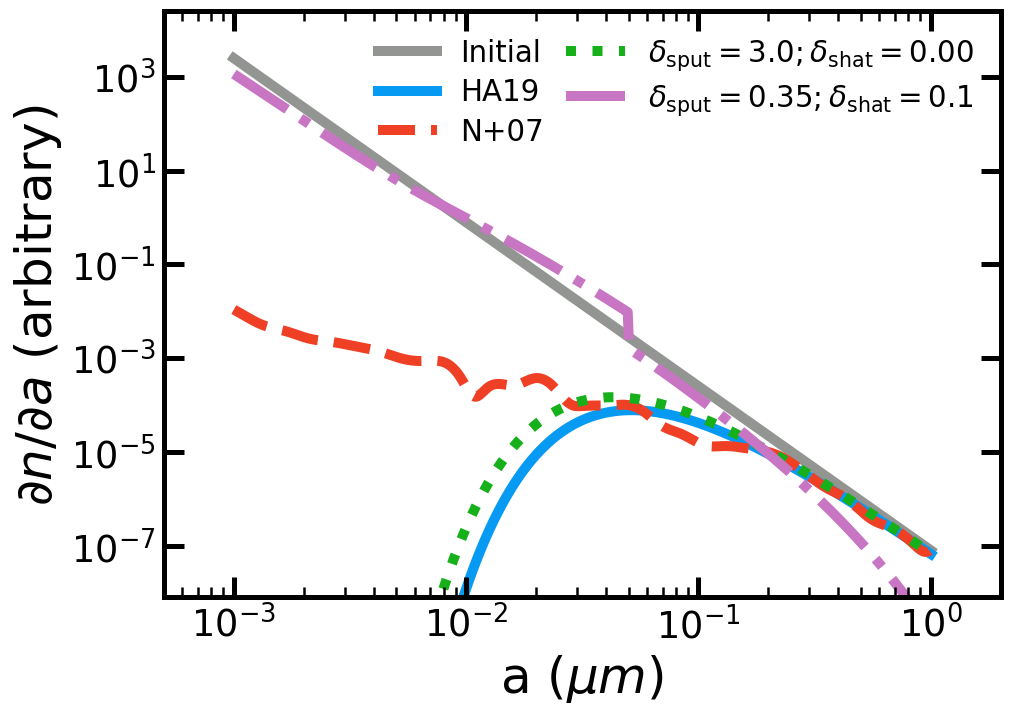

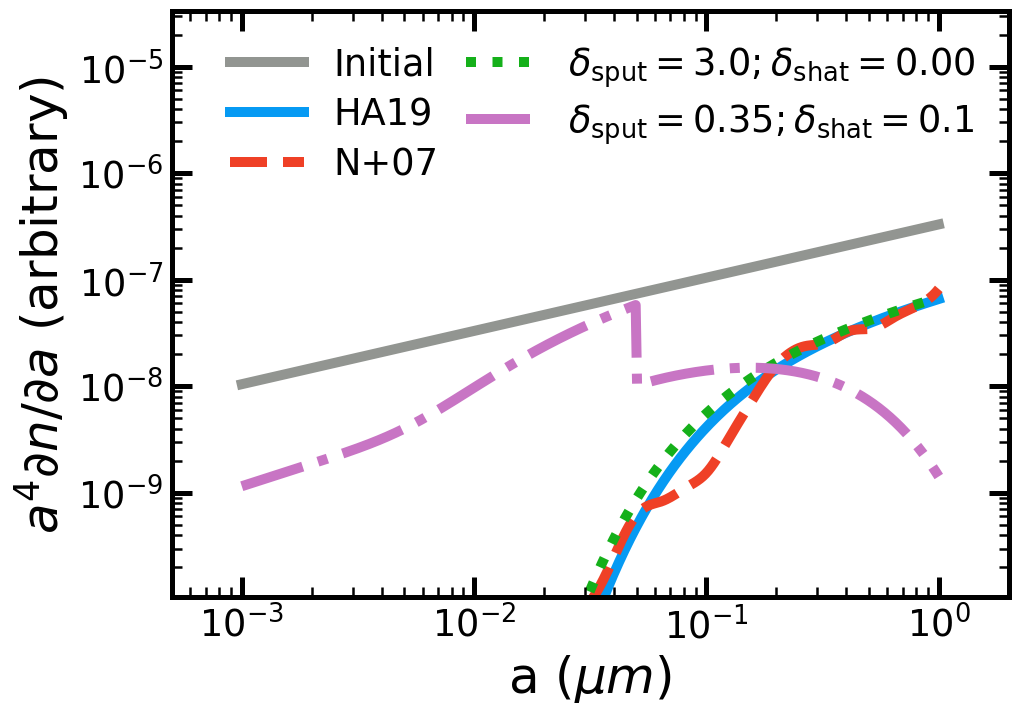

In [116]:

color_N = 5
colors = config.LINE_COLORS[:color_N]
linestyles = config.LINE_STYLES[:color_N]
linewidth = 2*config.BASE_LINEWIDTH

# Set limits for size distribution
amin=1E-3
amax=1E0
a_limit = [amin,amax]
bins=500
a_bins = np.logspace(np.log10(a_limit[0]),np.log10(a_limit[1]),bins)



init_dnda=gse.MRN_dnda
init_dmda=gse.MRN_dmda
norm = 1/quad(init_dnda,amin,amax)[0]
normed_init_dnda = lambda a: init_dnda(a)*norm
normed_init_dmda = lambda a: init_dmda(a)*norm

SNe_proc = gse.SNe_Dust_Processing(init_dnda,[amin,amax], bins=bins)

a_sput = 0.05; # microns
a_shat = 0.05;
delta_sput = 0.9;
delta_shat = 0.07;


delta_sput = 3;
delta_shat = 0.0;

a_frag_max = a_shat

f_shspsh1,dnda_shspsh1,dmda_shspsh1 = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', delta_sput = delta_sput, delta_shat = delta_shat, a_sput=a_sput, a_shat=a_shat, a_frag_max=a_frag_max)
label1 = r'$\delta_{\rm sput}=%0.1f ; \delta_{\rm shat}=%0.2f$'%(delta_sput,delta_shat)

delta_sput = 0.35;
delta_shat = 0.1;


f_shspsh2,dnda_shspsh2,dmda_shspsh2 = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', delta_sput = delta_sput, delta_shat = delta_shat, a_sput=a_sput, a_shat=a_shat, a_frag_max=a_frag_max)
label2 = r'$\delta_{\rm sput}=%0.2f ; \delta_{\rm shat}=%0.1f$'%(delta_sput,delta_shat)

f_sp,dnda_sp,dmda_sp=SNe_proc.get_SNe_processed_dnda(approx='sput', delta_sput = 0.9, a_sput=0.2)

f_noz,dnda_noz, dmda_noz = SNe_proc.get_SNe_processed_dnda(approx='nozawa')


print("Initial MRN")
print("Sh+Sp+Sh Dest Frac 1:",f_shspsh1)
print("Sh+Sp+Sh Dest Frac 2:",f_shspsh2)
print("Sp Only Dest Frac:",f_sp)
print("Nozawa+06 Dest Frac:",f_noz)

y_limit = [np.min(normed_init_dnda(a_bins))*1E-1,np.max(normed_init_dnda(a_bins))*1E1]
x_limit=[a_limit[0]*0.5,a_limit[1]*2]
x_label = r'a ($\mu m$)'
y_label = r'$\partial n/\partial a$ (arbitrary)'
fig = Figure(1)
fig.set_axis(0, 'a', 'number_survival_frac', x_lim=x_limit, x_log=True, x_label=x_label, y_label=y_label, y_lim=y_limit, y_log=True)

fig.plot_line_data(0,a_bins,normed_init_dnda(a_bins),label='Initial',color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH)
i=0
fig.plot_line_data(0,a_bins,dnda_sp(a_bins),label='HA19',color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
i+=1
fig.plot_line_data(0,a_bins,dnda_noz(a_bins),label='N+07',color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
i+=1
fig.plot_line_data(0,a_bins,dnda_shspsh1(a_bins),label=label1,color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
i+=1
fig.plot_line_data(0,a_bins,dnda_shspsh2(a_bins),label=label2,color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
fig.set_all_legends(rescale_font=0.8)
fig.save(plot_dir+'MRN_dnda_SNe_comparison.pdf')

y_limit = [np.min(normed_init_dmda(a_bins)*a_bins)*1E-2,np.max(normed_init_dmda(a_bins)*a_bins)*1E2]
x_limit=[a_limit[0]*0.5,a_limit[1]*2]
y_label = r'$a^4 \partial n/\partial a$ (arbitrary)'
fig = Figure(1)
fig.set_axis(0, 'a', 'number_survival_frac', x_lim=x_limit, x_log=True, x_label=x_label, y_label=y_label, y_lim=y_limit, y_log=True)


fig.plot_line_data(0,a_bins,normed_init_dmda(a_bins)*a_bins,label='Initial',color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH)
i=0
fig.plot_line_data(0,a_bins,dmda_sp(a_bins)*a_bins,label='HA19',color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
i+=1
fig.plot_line_data(0,a_bins,dmda_noz(a_bins)*a_bins,label='N+07',color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
i+=1
fig.plot_line_data(0,a_bins,dmda_shspsh1(a_bins)*a_bins,label=label1,color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
i+=1
fig.plot_line_data(0,a_bins,dmda_shspsh2(a_bins)*a_bins,label=label2,color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
fig.set_all_legends()
fig.save(plot_dir+'MRN_dmda_SNe_comparison.pdf')

In [ ]:

color_N = 5
colors = config.LINE_COLORS[:color_N]
linestyles = config.LINE_STYLES[:color_N]
linewidth = 2*config.BASE_LINEWIDTH

# Set limits for size distribution
amin=1E-3
amax=1E0
a_limit = [amin,amax]
bins=500
a_bins = np.logspace(np.log10(a_limit[0]),np.log10(a_limit[1]),bins)



init_dnda=gse.MRN_dnda
init_dmda=gse.MRN_dmda
norm = 1/quad(init_dnda,amin,amax)[0]
normed_init_dnda = lambda a: init_dnda(a)*norm
normed_init_dmda = lambda a: init_dmda(a)*norm



y_limit = [np.min(normed_init_dnda(a_bins))*1E-1,np.max(normed_init_dnda(a_bins))*1E1]
x_limit=[a_limit[0]*0.5,a_limit[1]*2]
x_label = r'a ($\mu m$)'
y_label = r'$\partial n/\partial a$ (arbitrary)'
fig = Figure(2)
fig.set_axis(0, 'a', 'number_survival_frac', x_lim=x_limit, x_log=True, x_label=x_label, y_label=y_label, y_lim=y_limit, y_log=True)

y_limit = [np.min(normed_init_dmda(a_bins)*a_bins)*1E-2,np.max(normed_init_dmda(a_bins)*a_bins)*1E2]
y_label = r'$a^4 \partial n/\partial a$ (arbitrary)'
fig.set_axis(1, 'a', 'number_survival_frac', x_lim=x_limit, x_log=True, x_label=x_label, y_label=y_label, y_lim=y_limit, y_log=True)

fig.plot_line_data(0,a_bins,normed_init_dnda(a_bins),label='Initial',color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH)
fig.plot_line_data(1,a_bins,normed_init_dmda(a_bins)*a_bins,label='Initial',color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH)

SNe_proc = gse.SNe_Dust_Processing(init_dnda,[amin,amax], bins=bins)

species=['silicates','carbonaceous','iron']
for i,spec in enumerate(species):
    f_shspsh,dnda_shspsh,dmda_shspsh = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat',species=spec)

    print("%s dest frac: %f"%(spec,f_shspsh))

    fig.plot_line_data(0,a_bins,dnda_shspsh(a_bins),label=spec,color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
    fig.plot_line_data(1,a_bins,dmda_shspsh(a_bins)*a_bins,label=spec,color=colors[i], linestyle=linestyles[i],linewidth=linewidth)

fig.set_all_legends(rescale_font=0.8)
fig.save(plot_dir+'SNe_dest_species_comparison.pdf')
